In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from google.colab import files
import io

# File upload widget
print("Please upload your NSI_0625.csv file:")
uploaded = files.upload()

# Load the dataset from the uploaded file
for filename in uploaded.keys():
    if filename.endswith('.csv'):
        content = uploaded[filename]
        df = pd.read_csv(io.BytesIO(content))
        print(f'Loaded dataset: {filename} with {df.shape[0]} rows and {df.shape[1]} columns')
        print("First 5 rows of the dataset:")
        display(df.head())

# Exclude tract 51153980100 for the later analysis
df = df[df.ID!=51153980100]
print(f"Dataset shape after excluding tract 51153980100: {df.shape}")

Please upload your NSI_0625.csv file:


Saving NSI_0625.csv to NSI_0625 (3).csv
Loaded dataset: NSI_0625 (3).csv with 92 rows and 190 columns
First 5 rows of the dataset:


,ID,PEOPCOLORPCT,LOWINCPCT,UNEMPPCT,DISABILITYPCT,LINGISOPCT,LESSHSPCT,UNDER5PCT,OVER64PCT,LIFEEXPPCT,...,District,City,Neighborhood,Overdose_Calls,Stroke_Patients,Cardiac_Patients,Diabetic_Patients,Respiratory_Patients,Blood_Pressure_Patients,High_Cholesterol_Patients
0,51153900100,0.501237,0.076685,0.006587,0.095916,0.033355,0.044565,0.057205,0.299320,0.182564,...,Occoquan,Dale City,Lake Ridge,7,27,41,52,31,82,17
1,51153900201,0.771815,0.327176,0.067423,0.154357,0.096774,0.133784,0.032364,0.072102,0.217436,...,Occoquan,Dale City,Lake Ridge,22,11,28,42,23,69,8
2,51153900202,0.731086,0.276916,0.048494,0.039679,0.135111,0.171480,0.040980,0.066440,0.169231,...,Occoquan,Dale City,Lake Ridge,16,23,38,61,41,89,12
3,51153900203,0.889301,0.301155,0.042468,0.100787,0.143670,0.191298,0.095228,0.057529,0.206154,...,Occoquan,Dale City,Lake Ridge,34,25,48,66,50,87,18
4,51153900301,0.556382,0.232398,0.092181,0.134315,0.093147,0.109264,0.048369,0.089010,0.180513,...,Occoquan,Dale City,Lake Ridge,31,14,41,58,26,87,21


Dataset shape after excluding tract 51153980100: (92, 190)


In [ ]:
df.shape


(92, 190)

In [ ]:
### Average Number of Person/Pedestrian killed/injured
df['Percent_Severe/Fatal'] = df['Percent_Fatal_Injury'] + df['Percent_Severe_Injury']
df['Avg_Person_Injured/Kill'] = df['Avg_Kill_Person'] + df['Avg_Injured_Person']
df['Avg_Pedestrian_Injured/Kill'] = df['Avg_Kill_Pedestrian'] + df['Avg_Injured_Pedestrian']

### Calls - Updated categories
# Underlying Conditions
df['Chronic_History'] = df['Stroke_Patients'] + df['Cardiac_Patients'] + df['Diabetic_Patients'] + df['High_Cholesterol_Patients'] + df['Respiratory_Patients'] + df['Blood_Pressure_Patients']

# Violence Calls (including domestic violence)
df['Violence_Calls'] = df['Shootings'] + df['Stabbings'] + df['Assaults'] + df['Domestic']

#df['Overdose_Calls']
#df['Domestic']

In [ ]:
# Define domain groupings based on refined categories
socioeconomic_vars = [
    "LOWINCPCT", "UNEMPPCT", "LINGISOPCT", "LESSHSPCT", "E_POV150_P",
    "With_PublicAssIncome_P", "With_SSI_P", "E_UNINSUR_P", "With_Medicaid_P", "percent_food_insecure","LIFEEXPPCT"
]
housing_vars = [
    "PRE1960PCT", "E_HBURD_P", "House_Vacant_P", "E_MUNIT_P",
    "E_MOBILE_P", "E_CROWD_P", "Owner_occupied_P", "Mean_Proportion_HHIncome", "percent_homeowners"
]
transportation_vars = [
    "PTRAF", "E_NOVEH_P", "Mean_Transportation_time(min)",
    "Work_Drivealone_P", "Work_Carpooled_P", "Work_PublicTransportation_P",
    "Work_Walk_P", "Work_Fromhome_P"
]
transportation_safety_vars = [
    "Percent_Severe/Fatal", "Avg_Person_Injured/Kill", "Avg_Pedestrian_Injured/Kill",
    "Percent_Alcohol_Related", "Percent_Distracted_Related", "Percent_Drowsy_Related",
    "Percent_Drug_Related", "Percent_Speed_Related", "Percent_Hitrun_Related",
    "Percent_Schoolzone_Related", "Percent_Lgtruck_Related",
    "Percent_Young_Related", "Percent_Senior_Related", "Percent_Bike_Related", 'Percent_Night_Related','Percent_Workzone_Related'
]
environmental_vars = [
    "PM25", "OZONE", "DSLPM", "NO2", "RSEI_AIR",
    "PTSDF", "UST", "PWDIS", "PNPL", "PRMP"
]
public_health_vars = [
    "EMS_Calls",
    "Structure_Fires",
    "Chronic_History",
    "Violence_Calls",
    "Homeless",
    "Opioid_Calls",
    "Calls_Per_HVU_Caller",
    "CPR_Calls"
  ]

In [ ]:
# Print the number of variables in each domain
print("\nNumber of variables in each domain:")
print(f"Socioeconomic: {len(socioeconomic_vars)}")
print(f"Housing: {len(housing_vars)}")
print(f"Transportation: {len(transportation_vars)}")
print(f"Transportation Safety: {len(transportation_safety_vars)}")
print(f"Environmental: {len(environmental_vars)}")
print(f"Public Health: {len(public_health_vars)}")


Number of variables in each domain:
Socioeconomic: 11
Housing: 9
Transportation: 8
Transportation Safety: 16
Environmental: 10
Public Health: 8


In [ ]:
# Find unused columns (fixed syntax error)
unused_columns = list(
    set(df.columns.to_list()) -
    set(
        socioeconomic_vars +
        housing_vars +
        transportation_vars +
        transportation_safety_vars +
        environmental_vars +
        public_health_vars
    )
)

print("\nUnused columns:")
print(unused_columns)
print(f"Number of unused columns: {len(unused_columns)}")


Unused columns:
['District', 'percent_homeowners_y', 'Fire_Calls', 'E_HH', 'Shootings_y', 'High_Volume_Utilizer_Calls', 'Respiratory_Patients', 'Num_Hospital', 'Attempted_Suicide', 'Assaults_y', 'Cardiac_Calls', '1st Due', 'Avg_Injured_Person', 'Avg_Kill_Person', 'Auto_Accidents', 'High_Cholesterol_Patients', 'Percent_Pedestrian_Related', 'Shootings', 'Age_Dependency_Ratio', 'CPR_Calls_y', 'Num_School', 'Opioid_Calls_x', 'Stroke_Calls_x', 'Domestic', 'Stroke_Calls_y', 'E_GROUPQ_P', 'Percent_Fatal_Injury', 'EMS_Calls_y', 'Old-age_Dependency_Ratio', 'Auto_Accidents_x', 'ID', 'percent_homeowners_x', 'Percent_Guardrail_Related', 'Homeless_x', 'Prop_Asian', 'Blood_Pressure_Patients', 'Homeless_y', 'High_Volume_Utilizer_Percent_y', 'Total_Calls_x', 'Percent_Mainline_Related', 'Medical_Calls', 'Total_Crash', 'DISABILITYPCT', 'Total_Calls', 'Assaults', 'Fire_Calls_x', 'Stabbings_y', 'Respiratory_Calls_x', 'Vulnerable_Calls', 'Child_Dependency_Ratio', 'Work_Taximotorbike_P', 'Prop_White', 'E_T

In [ ]:
df_missing = df.isna().sum().reset_index().rename(columns={0: 'Missing Values'}).sort_values(by='Missing Values', ascending=False)
df_missing[df_missing['Missing Values'] > 0]

,index,Missing Values
9,LIFEEXPPCT,15
176,percent_food_insecure,3
150,percent_food_insecure_y,3
127,percent_food_insecure_x,3
20,DWATER,2
61,Percent_Fatal_Injury,1
60,Total_Crash,1
86,Percent_Mainline_Related,1
85,Percent_Young_Related,1
84,Percent_Senior_Related,1


In [ ]:
# Find unused columns (fixed syntax error)
unused_columns = list(
    set(df.columns.to_list()) -
    set(
        socioeconomic_vars +
        housing_vars +
        transportation_vars +
        transportation_safety_vars +
        environmental_vars +
        public_health_vars
    )
)

print("\nUnused columns:")
print(unused_columns)
print(f"Number of unused columns: {len(unused_columns)}")


Unused columns:
['District', 'percent_homeowners_y', 'Fire_Calls', 'E_HH', 'Shootings_y', 'High_Volume_Utilizer_Calls', 'Respiratory_Patients', 'Num_Hospital', 'Attempted_Suicide', 'Assaults_y', 'Cardiac_Calls', '1st Due', 'Avg_Injured_Person', 'Avg_Kill_Person', 'Auto_Accidents', 'High_Cholesterol_Patients', 'Percent_Pedestrian_Related', 'Shootings', 'Age_Dependency_Ratio', 'CPR_Calls_y', 'Num_School', 'Opioid_Calls_x', 'Stroke_Calls_x', 'Domestic', 'Stroke_Calls_y', 'E_GROUPQ_P', 'Percent_Fatal_Injury', 'EMS_Calls_y', 'Old-age_Dependency_Ratio', 'Auto_Accidents_x', 'ID', 'percent_homeowners_x', 'Percent_Guardrail_Related', 'Homeless_x', 'Prop_Asian', 'Blood_Pressure_Patients', 'Homeless_y', 'High_Volume_Utilizer_Percent_y', 'Total_Calls_x', 'Percent_Mainline_Related', 'Medical_Calls', 'Total_Crash', 'DISABILITYPCT', 'Total_Calls', 'Assaults', 'Fire_Calls_x', 'Stabbings_y', 'Respiratory_Calls_x', 'Vulnerable_Calls', 'Child_Dependency_Ratio', 'Work_Taximotorbike_P', 'Prop_White', 'E_T

In [ ]:
# Columns to fill with mean
mean_fill_cols = ["LIFEEXPPCT", "DWATER"]

# Fill those with their own column mean
for col in mean_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())

df = df.fillna(0)

In [ ]:
# PCA and weighted score function
def pca_weighted_score(variables, domain_name, variance_threshold=0.85):
    data_subset = df[variables].copy()
    data_subset = data_subset.fillna(data_subset.mean())  # Fill NaNs with mean

    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data_subset)

    # PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)

    # Choose components explaining threshold
    explained = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(explained >= variance_threshold) + 1
    selected_components = X_pca[:, :n_components]

    # Weighted score using explained variance
    weights = pca.explained_variance_ratio_[:n_components] / np.sum(pca.explained_variance_ratio_[:n_components])
    final_score = selected_components @ weights
    df[f"{domain_name}_Score"] = final_score

    # Create PC loadings DataFrame
    loadings_df = pd.DataFrame(
        pca.components_[:n_components].T,
        columns=[f'PC{i+1}' for i in range(n_components)],
        index=variables
    )

    print(f"{domain_name} - Retained {n_components} components")
    return df, pca, selected_components, weights, loadings_df

In [ ]:
# Run the PCA function for each domain (demographics and protective infrastructure excluded)
df, socio_pca, socio_components, socio_weights, socio_loadings = pca_weighted_score(socioeconomic_vars, "Socioeconomic")
df, housing_pca, housing_components, housing_weights, housing_loadings = pca_weighted_score(housing_vars, "Housing")
df, trans_pca, trans_components, trans_weights, trans_loadings = pca_weighted_score(transportation_vars, "Transportation")
df, safety_pca, safety_components, safety_weights, safety_loadings = pca_weighted_score(transportation_safety_vars, "TransportationSafety")
df, env_pca, env_components, env_weights, env_loadings = pca_weighted_score(environmental_vars, "Environmental")
df, health_pca, health_components, health_weights, health_loadings = pca_weighted_score(public_health_vars, "PublicHealth")

Socioeconomic - Retained 5 components
Housing - Retained 5 components
Transportation - Retained 5 components
TransportationSafety - Retained 10 components
Environmental - Retained 5 components
PublicHealth - Retained 4 components


In [ ]:
# Display weights as a dictionary with domain names
all_domain_weights = {
    "Socioeconomic": socio_weights,
    "Housing": housing_weights,
    "Transportation": trans_weights,
    "TransportationSafety": safety_weights,
    "Environmental": env_weights,
    "PublicHealth": health_weights
}

# Print each domain's weights
for domain, weights in all_domain_weights.items():
    print(f"{domain} weights: {weights}")

Socioeconomic weights: [0.618382   0.13996237 0.09311885 0.08070853 0.06782825]
Housing weights: [0.52004309 0.15313871 0.14338375 0.11540107 0.06803338]
Transportation weights: [0.36893518 0.19667997 0.17926346 0.14689626 0.10822513]
TransportationSafety weights: [0.19469454 0.16967064 0.12431329 0.10033388 0.0972627  0.07677292
 0.07318513 0.05920661 0.05820356 0.04635673]
Environmental weights: [0.36541583 0.28539667 0.15858404 0.12406115 0.06654231]
PublicHealth weights: [0.67333745 0.14784205 0.11100983 0.06781067]


In [ ]:
# Display loadings for each domain
print("\nSocioeconomic loadings:")
display(socio_loadings)

print("\nHousing loadings:")
display(housing_loadings)

print("\nTransportation loadings:")
display(trans_loadings)

print("\nTransportation Safety loadings:")
display(safety_loadings)

print("\nEnvironmental loadings:")
display(env_loadings)

print("\nPublic Health loadings:")
display(health_loadings)


Socioeconomic loadings:


,PC1,PC2,PC3,PC4,PC5
LOWINCPCT,0.377582,0.075372,-0.048814,-0.040164,-0.219183
UNEMPPCT,0.144355,0.588186,0.257446,0.532757,0.443442
LINGISOPCT,0.332473,-0.020078,-0.032018,-0.344088,0.305396
LESSHSPCT,0.342078,-0.195668,0.010679,-0.263918,0.294899
E_POV150_P,0.365269,0.101388,-0.080497,0.079913,-0.316205
With_PublicAssIncome_P,0.290855,0.120784,-0.430539,0.183524,-0.154629
With_SSI_P,0.172320,-0.509933,-0.309750,0.604417,0.263917
E_UNINSUR_P,0.352339,-0.143251,0.101321,-0.239722,0.403879
With_Medicaid_P,0.353618,0.043572,-0.153110,0.040038,-0.367036
percent_food_insecure,0.297560,0.281001,0.365824,-0.037953,-0.142994



Housing loadings:


,PC1,PC2,PC3,PC4,PC5
PRE1960PCT,-0.121875,0.766140,-0.202933,0.031492,0.435007
E_HBURD_P,-0.419170,-0.036842,0.210124,0.115442,0.106100
House_Vacant_P,-0.309802,0.473145,-0.184081,0.125663,-0.371712
E_MUNIT_P,-0.412440,-0.200952,-0.168418,0.025962,-0.108376
E_MOBILE_P,-0.116225,0.273010,0.571211,-0.644463,-0.368657
E_CROWD_P,-0.328635,-0.169629,0.166889,-0.352352,0.686988
Owner_occupied_P,0.452059,0.152416,0.126274,-0.026433,0.125113
Mean_Proportion_HHIncome,-0.084966,0.079170,0.682485,0.653346,0.058730
percent_homeowners,0.458556,0.120903,0.128651,-0.046602,0.150445



Transportation loadings:


...

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
Percent_Severe/Fatal,0.053066,0.050019,-0.164208,-0.177496,0.660223,-0.054667,0.177386,0.176027,-0.229715,-0.458569
Avg_Person_Injured/Kill,0.037876,0.003144,0.444770,-0.379734,0.163670,-0.028142,-0.316677,-0.394989,0.304382,-0.078365
Avg_Pedestrian_Injured/Kill,0.367414,-0.172138,0.118374,0.378226,0.108410,0.063025,0.280862,0.179773,0.338439,0.122635
Percent_Alcohol_Related,0.405913,-0.013388,0.159394,-0.108460,0.075921,0.451280,-0.053609,-0.061847,-0.320408,0.017893
Percent_Distracted_Related,-0.124468,0.190362,0.519781,0.258079,0.023276,0.140049,-0.136104,-0.096010,-0.152715,-0.420701
Percent_Drowsy_Related,0.087514,0.350728,0.269515,0.177110,-0.133234,-0.075893,-0.154851,0.551685,-0.265655,0.035796
Percent_Drug_Related,-0.013831,-0.004975,-0.292915,0.167225,0.187061,0.740459,-0.210782,0.054516,0.251967,-0.031133
Percent_Speed_Related,0.070237,0.438436,-0.180971,-0.122882,0.302949,-0.172156,-0.147502,0.118686,0.026635,0.339599
Percent_Hitrun_Related,0.490559,0.131810,0.152517,0.169790,-0.135428,-0.019619,-0.040441,-0.075556,0.064931,0.105566
Percent_Schoolzone_Related,0.031216,-0.227833,0.106486,0.513854,0.397155,-0.282478,0.103484,-0.187696,-0.029460,-0.046018



Environmental loadings:


,PC1,PC2,PC3,PC4,PC5
PM25,-0.387701,0.004762,0.216028,-0.489301,-0.183779
OZONE,-0.306823,0.384631,-0.265694,-0.240003,-0.281036
DSLPM,-0.397678,0.356073,0.032655,0.198539,-0.264031
NO2,-0.296152,0.220723,-0.231718,0.602146,-0.130064
RSEI_AIR,0.305996,0.442431,-0.088049,-0.159882,-0.034957
PTSDF,0.294419,0.504677,0.137311,-0.061897,-0.018082
UST,-0.312292,0.286316,0.139632,0.100930,0.853055
PWDIS,0.216349,0.029250,0.536753,0.479090,-0.252712
PNPL,0.397976,0.361916,-0.063162,-0.090817,0.069508
PRMP,-0.163281,0.110771,0.699845,-0.153721,-0.051667



Public Health loadings:


,PC1,PC2,PC3,PC4
EMS_Calls,0.422585,0.021657,0.132449,-0.008186
Structure_Fires,0.360574,-0.155888,-0.185800,0.675776
Chronic_History,0.345519,0.053761,0.564517,0.370202
Violence_Calls,0.401087,-0.117621,-0.380468,-0.023968
Homeless,0.389377,-0.162168,-0.223789,-0.477561
Opioid_Calls,0.388929,-0.047368,-0.228647,-0.154782
Calls_Per_HVU_Caller,0.061590,0.912280,-0.344694,0.125102
CPR_Calls,0.323235,0.312584,0.513152,-0.371434


In [ ]:
# Create final dataframe with only domain scores
df_final = df[['ID', 'Socioeconomic_Score', 'Housing_Score', 'Transportation_Score',
                'TransportationSafety_Score', 'Environmental_Score', 'PublicHealth_Score']].copy()

# Display the final dataframe
df_final.head()

,ID,Socioeconomic_Score,Housing_Score,Transportation_Score,TransportationSafety_Score,Environmental_Score,PublicHealth_Score
0,51153900100,-1.374391,0.084627,0.763758,-0.442877,0.393710,-0.852775
1,51153900201,1.949894,-1.611539,-0.284872,-0.221227,0.141380,-0.695907
2,51153900202,0.703906,0.221944,-0.393846,0.286176,-0.180503,0.031392
3,51153900203,2.297460,-3.247709,-1.072581,0.899768,-0.282372,1.145467
4,51153900301,1.665317,-0.445242,-1.407521,0.189201,-0.037319,-0.483571


Correlation Matrix:
                            Socioeconomic_Score  Housing_Score  \
Socioeconomic_Score                    1.000000      -0.651676   
Housing_Score                         -0.651676       1.000000   
Transportation_Score                  -0.595220       0.620895   
TransportationSafety_Score             0.323554      -0.236577   
Environmental_Score                   -0.045267      -0.248123   
PublicHealth_Score                     0.340437      -0.252158   

                            Transportation_Score  TransportationSafety_Score  \
Socioeconomic_Score                    -0.595220                    0.323554   
Housing_Score                           0.620895                   -0.236577   
Transportation_Score                    1.000000                   -0.245842   
TransportationSafety_Score             -0.245842                    1.000000   
Environmental_Score                    -0.346386                   -0.246113   
PublicHealth_Score                   

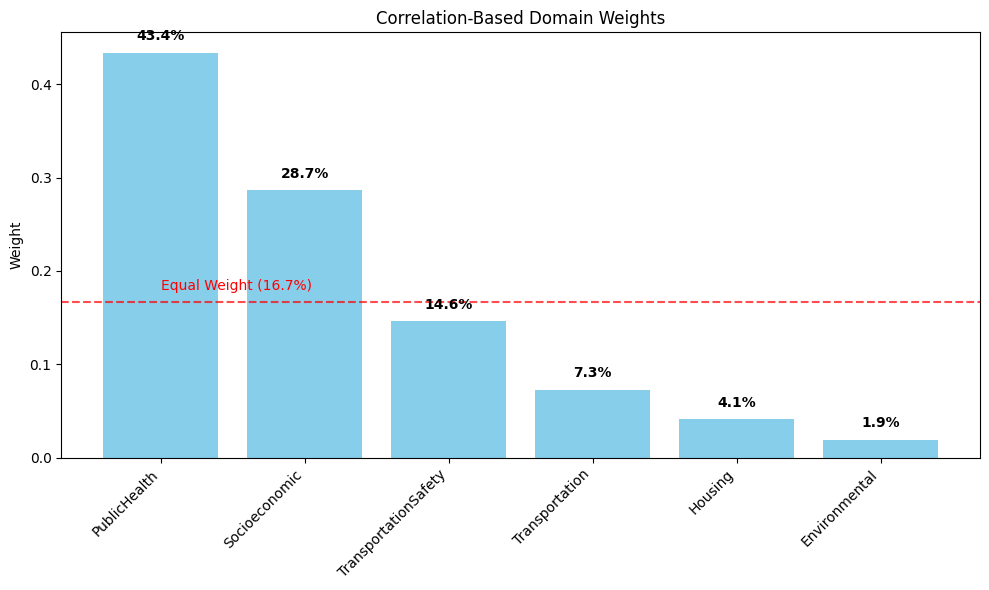

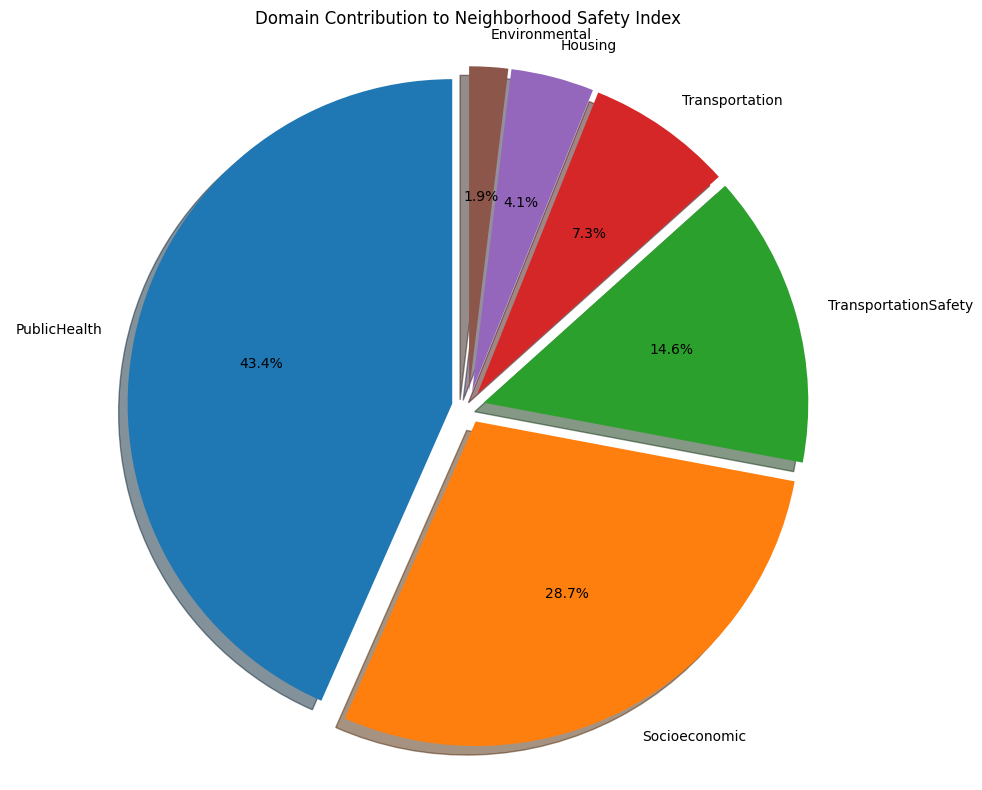

In [ ]:
# Create a correlation matrix between all domain scores
domain_columns = [
    'Socioeconomic_Score', 'Housing_Score', 'Transportation_Score',
    'TransportationSafety_Score', 'Environmental_Score', 'PublicHealth_Score'
]

correlation_matrix = df_final[domain_columns].corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# If you don't have NSI_Equal, let's create a simple average
if 'NSI_Equal' not in df_final.columns:
    df_final['NSI_Equal'] = df_final[domain_columns].mean(axis=1)

# Get correlations with the overall score
correlations = df_final[domain_columns].corrwith(df_final['NSI_Equal']).abs()

# Normalize to create weights
correlation_weights = correlations / correlations.sum()

print("\nCorrelation-based weights:")
for domain, weight in correlation_weights.items():
    domain_name = domain.replace('_Score', '')
    print(f"{domain_name}: {weight:.4f} ({weight*100:.1f}%)")

# Visualize correlation-based weights
import matplotlib.pyplot as plt

# Create a sorted dictionary for better visualization
sorted_weights = dict(sorted(correlation_weights.items(), key=lambda x: x[1], reverse=True))

# Clean up domain names for display
clean_names = {name: name.replace('_Score', '') for name in sorted_weights.keys()}
sorted_weights = {clean_names[k]: v for k, v in sorted_weights.items()}

# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(sorted_weights.keys(), sorted_weights.values(), color='skyblue')

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.1%}', ha='center', va='bottom', fontweight='bold')

plt.ylabel('Weight')
plt.title('Correlation-Based Domain Weights')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add a horizontal line showing equal weighting (1/6)
plt.axhline(y=1/6, color='red', linestyle='--', alpha=0.7)
plt.text(0, 1/6 + 0.01, 'Equal Weight (16.7%)', color='red', va='bottom')

plt.show()

# Create a pie chart for another perspective
plt.figure(figsize=(10, 8))
plt.pie(sorted_weights.values(), labels=sorted_weights.keys(), autopct='%1.1f%%',
        startangle=90, shadow=True, explode=[0.05]*len(sorted_weights))
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.title('Domain Contribution to Neighborhood Safety Index')
plt.tight_layout()
plt.show()

In [ ]:
import altair as alt

# Reshape the dataframe for the heatmap
correlation_matrix_melted = correlation_matrix.reset_index().melt('index')

# Create the heatmap
chart = alt.Chart(correlation_matrix_melted).mark_rect().encode(
    x=alt.X('index', title=''),  # Set x-axis title to empty string
    y=alt.Y('variable', title=''), # Set y-axis title to empty string
    color=alt.Color('value', title='Correlation'),
    tooltip=['index', 'variable', 'value']
).properties(
    title='Correlation Matrix Heatmap'
)

chart

alt.Chart(...)

In [ ]:
df_final_copy = df_final.copy()
domain_columns = ['Socioeconomic_Score', 'Housing_Score', 'Transportation_Score',
                 'TransportationSafety_Score', 'Environmental_Score', 'PublicHealth_Score']

# Apply the correlation-based weights to create a weighted opportunity index
df_final_copy["Raw_Opportunity_Index"] = 0
for domain, weight in correlation_weights.items():
    if domain in domain_columns:
        # Multiply by -1 to flip scores so higher = more opportunity
        df_final_copy["Raw_Opportunity_Index"] += (df_final_copy[domain] * weight)

# Standardize the final index (positive so higher = more opportunity)
scaler = StandardScaler()
df_final_copy["Standardized_Opportunity_Index"] = scaler.fit_transform(df_final_copy[["Raw_Opportunity_Index"]])

# Create 1-8 ranking (8 = most opportunity, 1 = least opportunity)
df_final_copy["PWC_Opportunity_Index"] = pd.qcut(

    df_final_copy["Standardized_Opportunity_Index"],
    q=8,
    labels=False
) + 1

# Create opportunity tiers
df_final_copy["Opportunity_Tier"] = pd.cut(
    df_final_copy["PWC_Opportunity_Index"],
    bins=[0, 2, 4, 6, 8],
    labels=["Less Opportunity", "Moderate Opportunity", "High Opportunity", "Exceptional Opportunity"]
)

# Display the distribution of opportunity tiers
print("Distribution of neighborhoods by opportunity tier:")
display(df_final_copy["Opportunity_Tier"].value_counts())

# Display the first few rows, sorted by opportunity index
print("\nNeighborhoods by Prince William County Opportunity Index:")
display(df_final_copy.sort_values("PWC_Opportunity_Index", ascending=False)[
    ["ID", "PWC_Opportunity_Index", "Opportunity_Tier", "Standardized_Opportunity_Index"]
].head(10))


Distribution of neighborhoods by opportunity tier:


,count
Opportunity_Tier,
Less Opportunity,23
Moderate Opportunity,23
High Opportunity,23
Exceptional Opportunity,23



Neighborhoods by Prince William County Opportunity Index:


,ID,PWC_Opportunity_Index,Opportunity_Tier,Standardized_Opportunity_Index
3,51153900203,8,Exceptional Opportunity,1.240044
7,51153900404,8,Exceptional Opportunity,1.290072
6,51153900403,8,Exceptional Opportunity,5.128031
14,51153900504,8,Exceptional Opportunity,2.164376
20,51153900803,8,Exceptional Opportunity,1.142936
17,51153900701,8,Exceptional Opportunity,0.985477
16,51153900602,8,Exceptional Opportunity,1.330213
22,51153900901,8,Exceptional Opportunity,1.665623
63,51153901403,8,Exceptional Opportunity,1.750593
90,51153901704,8,Exceptional Opportunity,1.782507


In [ ]:
# Use only the domain columns for clustering
X = df_final[domain_columns].copy()

# Apply correlation-based weights to domain columns
X_corr = X.copy()
print("\nApplying weights to the following columns:")
for domain, weight in correlation_weights.items():
    if domain in X_corr.columns:
        X_corr[domain] = X_corr[domain] * weight
        print(f"  - {domain} × {weight:.3f}")

# Perform K-means clustering with 4 clusters
kmeans_corr = KMeans(n_clusters=4, random_state=42)
clusters = kmeans_corr.fit_predict(X_corr)
df_final['Four_Cluster_Solution'] = clusters

# Calculate silhouette score
corr_score = silhouette_score(X_corr, clusters)
print(f"\nFour-cluster silhouette score: {corr_score:.3f}")

# Show cluster distribution
cluster_counts = pd.Series(clusters).value_counts().sort_index()
print("\nCluster distribution:")
for cluster_id, count in cluster_counts.items():
    print(f"Cluster {cluster_id}: {count} census tracts ({count/len(clusters)*100:.1f}%)")

# Analyze clusters and determine opportunity levels
cluster_means = {}
for cluster_id in range(4):
    mask = df_final['Four_Cluster_Solution'] == cluster_id
    domain_means = {}
    for domain in domain_columns:
        domain_means[domain] = df_final.loc[mask, domain].mean()
    cluster_means[cluster_id] = domain_means

# Calculate overall opportunity using correlation weights (flip sign for opportunity framing)
overall_opportunity = {}
for cluster_id, domain_means in cluster_means.items():
    weighted_sum = 0
    for domain, mean_val in domain_means.items():
        if domain in correlation_weights:
            weight = correlation_weights[domain]
            weighted_sum += mean_val * weight
    overall_opportunity[cluster_id] = weighted_sum

# Assign opportunity labels
opportunity_mapping = {
    cluster_id: "Exceptional Opportunity" if rank == 0 else
               "High Opportunity" if rank == 1 else
               "Moderate Opportunity" if rank == 2 else
               "Less Opportunity"
    for rank, (cluster_id, _) in enumerate(sorted(overall_opportunity.items(), key=lambda x: x[1], reverse=True))
}

# Print opportunity level mapping
print("\nCluster opportunity level mapping:")
for cluster_id, opportunity_label in opportunity_mapping.items():
    print(f"Cluster {cluster_id} → {opportunity_label}")
    domain_values = cluster_means[cluster_id]
    print(f"  Average domain scores: ", end="")
    for domain, value in domain_values.items():
        print(f"{domain.replace('_Score', '')}: {value:.3f}  ", end="")
    print(f"\n  Overall weighted opportunity score: {overall_opportunity[cluster_id]:.3f}")


Applying weights to the following columns:
  - Socioeconomic_Score × 0.287
  - Housing_Score × 0.041
  - Transportation_Score × 0.073
  - TransportationSafety_Score × 0.146
  - Environmental_Score × 0.019
  - PublicHealth_Score × 0.434

Four-cluster silhouette score: 0.303

Cluster distribution:
Cluster 0: 35 census tracts (38.0%)
Cluster 1: 34 census tracts (37.0%)
Cluster 2: 1 census tracts (1.1%)
Cluster 3: 22 census tracts (23.9%)

Cluster opportunity level mapping:
Cluster 2 → Exceptional Opportunity
  Average domain scores: Socioeconomic: 1.265  Housing: 0.100  Transportation: -0.656  TransportationSafety: -0.171  Environmental: -0.408  PublicHealth: 9.527  
  Overall weighted opportunity score: 4.420
Cluster 3 → High Opportunity
  Average domain scores: Socioeconomic: 1.241  Housing: -0.963  Transportation: -0.289  TransportationSafety: 0.175  Environmental: -0.027  PublicHealth: 1.420  
  Overall weighted opportunity score: 0.936
Cluster 1 → Moderate Opportunity
  Average doma

In [ ]:
# =============================================
# COMPREHENSIVE OPPORTUNITY INDEX ANALYSIS
# =============================================

print("\n\n--- COMPREHENSIVE OPPORTUNITY INDEX ANALYSIS ---\n")

# Make sure necessary imports are available
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# PART 1: DOMAIN-LEVEL IMPACT ANALYSIS
print("PART 1: DOMAIN-LEVEL IMPACT ANALYSIS")
# Calculate contribution of each domain to the opportunity index
contribution_df = pd.DataFrame(index=df_final_copy.index)

# For each domain, calculate its weighted value and percentage contribution
for domain in domain_columns:
    # Get correlation weight for this domain
    weight = correlation_weights[domain]

    # Calculate weighted value for each census tract
    weighted_values = df_final_copy[domain] * weight

    # Store in dataframe
    contribution_df[f"{domain}_Weighted"] = weighted_values

    # Calculate the absolute contribution for ranking purposes
    contribution_df[f"{domain}_AbsContribution"] = weighted_values.abs()

# Add ID column for reference
if 'ID' in df_final_copy.columns:
    contribution_df['ID'] = df_final_copy['ID']

# Add geographic identifiers if they exist
geographic_columns = ['District', 'City', 'Neighborhood', '1st Due']
for geo_col in geographic_columns:
    if geo_col in df_final_copy.columns:
        contribution_df[geo_col] = df_final_copy[geo_col]

# Add raw and standardized opportunity index
contribution_df['Raw_Opportunity_Index'] = df_final_copy['Raw_Opportunity_Index']
contribution_df['Standardized_Opportunity_Index'] = df_final_copy['Standardized_Opportunity_Index']
contribution_df['PWC_Opportunity_Index'] = df_final_copy['PWC_Opportunity_Index']
contribution_df['Opportunity_Tier'] = df_final_copy['Opportunity_Tier']

# Calculate percentage contribution of each domain to total opportunity
total_abs_contribution = contribution_df[[f"{domain}_AbsContribution" for domain in domain_columns]].sum(axis=1)
for domain in domain_columns:
    contribution_df[f"{domain}_PctContribution"] = (
        contribution_df[f"{domain}_AbsContribution"] / total_abs_contribution * 100
    )

# Create a DataFrame with just the absolute contributions for ranking
abs_contributions = contribution_df[[f"{domain}_AbsContribution" for domain in domain_columns]].copy()
# Rename columns to cleaner names for ranking
abs_contributions.columns = [domain.replace('_Score', '') for domain in domain_columns]

# Rank the domains (1 = highest contribution)
domain_ranks = abs_contributions.rank(axis=1, ascending=False, method='min')

# Add the rank columns to our main dataframe
for domain in domain_columns:
    clean_name = domain.replace('_Score', '')
    contribution_df[f"{clean_name}_Rank"] = domain_ranks[clean_name]

# For each census tract, identify the top contributing domain
contribution_df['Top_Domain'] = ''
for i, row in contribution_df.iterrows():
    # Find domain with rank 1
    for domain in domain_columns:
        clean_name = domain.replace('_Score', '')
        if row[f"{clean_name}_Rank"] == 1:
            contribution_df.at[i, 'Top_Domain'] = clean_name
            break

# Print overview of top contributing domains across all census tracts
print("\nDistribution of top contributing domains:")
print(contribution_df['Top_Domain'].value_counts())

# For each opportunity tier, what are the most common top domains?
print("\nTop contributing domains by opportunity tier:")
try:
    tier_domains = pd.crosstab(contribution_df['Opportunity_Tier'], contribution_df['Top_Domain'])
    print(tier_domains)
except:
    print("Could not create crosstab - check if Opportunity_Tier and Top_Domain columns exist")

# PART 2: SUB-VARIABLE IMPACT ANALYSIS
print("\nPART 2: SUB-VARIABLE IMPACT ANALYSIS")
# Define the sub-variables within each domain INCLUDING DEMOGRAPHICS
domain_variables = {
    'Socioeconomic': [
        "LIFEEXPPCT", "LOWINCPCT", "UNEMPPCT", "LINGISOPCT", "LESSHSPCT", "E_POV150_P",
        "With_PublicAssIncome_P", "With_SSI_P", "E_UNINSUR_P", "With_Medicaid_P",
        "percent_food_insecure"
    ],
    'Housing': [
        "PRE1960PCT", "E_HBURD_P", "House_Vacant_P", "E_MUNIT_P",
        "E_MOBILE_P", "E_CROWD_P", "Owner_occupied_P", "Mean_Proportion_HHIncome",
        "percent_homeowners"
    ],
    'Transportation': [
        "PTRAF", "E_NOVEH_P", "Mean_Transportation_time(min)",
        "Work_Drivealone_P", "Work_Carpooled_P", "Work_PublicTransportation_P",
        "Work_Walk_P", "Work_Fromhome_P"
    ],
    'TransportationSafety': [
        "Percent_Severe/Fatal", "Avg_Person_Injured/Kill", "Avg_Pedestrian_Injured/Kill",
        "Percent_Alcohol_Related", "Percent_Distracted_Related", "Percent_Drowsy_Related",
        "Percent_Drug_Related", "Percent_Speed_Related", "Percent_Hitrun_Related",
        "Percent_Schoolzone_Related", "Percent_Lgtruck_Related",
        "Percent_Young_Related", "Percent_Senior_Related", "Percent_Bike_Related",
        "Percent_Night_Related", "Percent_Workzone_Related"
    ],
    'Environmental': [
        "PM25", "OZONE", "DSLPM", "NO2", "RSEI_AIR",
        "PTSDF", "UST", "PWDIS", "PNPL", "PRMP"
    ],
    'PublicHealth': [
        "EMS_Calls",
        "Structure_Fires",
        "Chronic_History",
        "Violence_Calls",
        "Homeless",
        "Opioid_Calls",
        "Calls_Per_HVU_Caller",
        "CPR_Calls"
    ],
    'Demographics': [  # ADDED DEMOGRAPHICS DOMAIN
        "DISABILITYPCT", "UNDER5PCT", "OVER64PCT", "E_SNGPNT_P", "E_GROUPQ_P",
        "Total_Population", "Median_Age", "Age_Dependency_Ratio",
        "Old-age_Dependency_Ratio", "Child_Dependency_Ratio", "Prop_White",
        "Sex_Ratio(males per 100 females)", "Prop_Black", "Prop_Hisp"
    ]
}

# =============================================
# DEBUG: CHECK AVAILABLE VARIABLES
# =============================================

print("\n--- CHECKING AVAILABLE VARIABLES ---")

# Check which variables actually exist in the dataset
if 'df' in locals() and isinstance(df, pd.DataFrame):
    # Check which variables are actually in the dataset
    for domain_name, variables in domain_variables.items():
        found_vars = [var for var in variables if var in df.columns]
        missing_vars = [var for var in variables if var not in df.columns]

        print(f"\n{domain_name} domain:")
        print(f"  Found {len(found_vars)} variables: {found_vars}")
        if missing_vars:
            print(f"  Missing {len(missing_vars)} variables: {missing_vars}")

    # Check df columns directly to see the actual values
    columns_sample = sorted(list(df.columns))[:50]  # First 50 columns
    print(f"\nSample of actual column names in dataset: {columns_sample}")

    print(f"\nDemographics domain has {len(domain_variables['Demographics'])} variables")
else:
    print("Original dataframe not accessible for variable checking")

# =============================================
# CONTINUE WITH SUB-VARIABLE ANALYSIS
# =============================================

# Check that original df with all variables is available
if 'df' not in locals() or not isinstance(df, pd.DataFrame):
    print("Warning: Original dataframe with sub-variables not available or not accessible.")
    print("Creating domain-level analysis only.")

    # Create domain-level analysis only
    detailed_rows = []
else:
    print(f"Original dataframe available with {len(df.columns)} columns")

    # Create a detailed analysis for each census tract
    detailed_rows = []

    # For each census tract
    for tract_id in df['ID'].unique():
        # Skip if tract_id not in contribution_df
        if tract_id not in contribution_df['ID'].values:
            continue

        tract_data = df[df['ID'] == tract_id].iloc[0]

        # Get opportunity tier and top domain
        tract_info = contribution_df[contribution_df['ID'] == tract_id].iloc[0]
        tract_opportunity = tract_info['Opportunity_Tier']
        top_domain = tract_info['Top_Domain']

        # Get domain rankings for this tract
        domain_ranking = {}
        for domain in domain_columns:
            clean_name = domain.replace('_Score', '')
            domain_ranking[clean_name] = tract_info[f"{clean_name}_Rank"]

        # For each domain, find ALL contributing sub-variables
        for domain_name, variables in domain_variables.items():
            # Make sure all variables exist in the dataframe
            valid_vars = [var for var in variables if var in df.columns]

            if not valid_vars:
                continue

            # Standardize the variables to compare them fairly
            # Get values for this tract
            values = tract_data[valid_vars].values

            # Get means and stds from the entire dataset
            means = df[valid_vars].mean().values
            stds = df[valid_vars].std().values

            # Safely standardize (avoid division by zero)
            z_scores = np.zeros_like(values)
            for i, (val, mean, std) in enumerate(zip(values, means, stds)):
                if std > 0:
                    z_scores[i] = (val - mean) / std
                else:
                    z_scores[i] = 0

            # Create a mini dataframe for this domain's variables
            domain_df = pd.DataFrame({
                'Variable': valid_vars,
                'Value': values,
                'Z_Score': z_scores,
                'Abs_Z_Score': np.abs(z_scores)
            })

            # Sort by absolute z-score (highest = most extreme values)
            domain_df = domain_df.sort_values('Abs_Z_Score', ascending=False)

            # Take ALL variables
            all_vars = domain_df

            # Get domain's rank for this tract
            domain_rank = domain_ranking.get(domain_name, 0)

            # Add to rows list
            for i, (idx, row) in enumerate(all_vars.iterrows()):
                detailed_rows.append({
                    'Tract_ID': tract_id,
                    'Opportunity_Tier': tract_opportunity,
                    'PWC_Opportunity_Index': tract_info['PWC_Opportunity_Index'],
                    'Top_Domain': top_domain,
                    'Domain': domain_name,
                    'Domain_Rank': domain_rank,
                    'Is_Top_Domain': domain_name == top_domain,
                    'Variable': row['Variable'],
                    'Variable_Value': row['Value'],
                    'Variable_Z_Score': row['Z_Score'],
                    'Variable_Rank': i + 1
                })

# PART 3: CREATE COMBINED ANALYSIS OUTPUTS
print("\nPART 3: CREATING COMBINED ANALYSIS OUTPUTS")

# 1. Create domain-level export
print("Creating domain-level export...")
# Create a clean version for export
export_cols = ['ID', 'Raw_Opportunity_Index', 'Standardized_Opportunity_Index',
               'PWC_Opportunity_Index', 'Opportunity_Tier', 'Top_Domain']

# Add geographic columns if they exist
geographic_columns = ['District', 'City', 'Neighborhood', '1st Due']
for geo_col in geographic_columns:
    if geo_col in contribution_df.columns:
        export_cols.append(geo_col)

# Add the rank columns
for domain in domain_columns:
    clean_name = domain.replace('_Score', '')
    export_cols.append(f"{clean_name}_Rank")

# Add weighted contribution and percentage columns
for domain in domain_columns:
    clean_name = domain.replace('_Score', '')
    export_cols.append(f"{domain}_Weighted")
    export_cols.append(f"{domain}_PctContribution")

# Add original domain scores
for domain in domain_columns:
    export_cols.append(domain)

# Create export dataframe with clean column names
export_df = contribution_df.copy()

# Rename percentage columns to be cleaner
for domain in domain_columns:
    clean_name = domain.replace('_Score', '')
    export_df = export_df.rename(columns={
        f"{domain}_PctContribution": f"{clean_name}_Pct"
    })

# Select only the columns we want to export
export_cols = [col for col in export_cols if col in export_df.columns]
export_df = export_df[export_cols]

# Sort by opportunity index (highest opportunity first)
export_df = export_df.sort_values('PWC_Opportunity_Index', ascending=False)

# 2. Create variable-level export if we have that data
print("Creating variable-level export...")
if detailed_rows:
    detailed_df = pd.DataFrame(detailed_rows)

    # Print summary of detailed variables found
    print("\nSummary of detailed variables analyzed:")
    for domain in domain_variables.keys():
        domain_vars = detailed_df[detailed_df['Domain'] == domain]['Variable'].unique()
        print(f"{domain}: {len(domain_vars)} variables analyzed")
        print(f"  {list(domain_vars)[:10]}{'...' if len(domain_vars) > 10 else ''}")

    # Create a pivot table version that's easier to read
    print("Creating pivot table for easy browsing...")
    pivot_rows = []

    # For each tract
    for tract_id in detailed_df['Tract_ID'].unique():
        tract_data = detailed_df[detailed_df['Tract_ID'] == tract_id]

        # Get basic tract info from first row
        basic_info = {
            'Tract_ID': tract_id,
            'Opportunity_Tier': tract_data['Opportunity_Tier'].iloc[0],
            'PWC_Opportunity_Index': tract_data['PWC_Opportunity_Index'].iloc[0],
            'Top_Domain': tract_data['Top_Domain'].iloc[0]
        }

        # Add geographic identifiers if they exist in the original df
        if 'df' in locals() and isinstance(df, pd.DataFrame):
            tract_original_data = df[df['ID'] == tract_id]
            if not tract_original_data.empty:
                tract_row = tract_original_data.iloc[0]

                # Check for various possible column names for geographic data
                geo_columns = {
                    'District': ['District', 'district', 'DISTRICT'],
                    'City': ['City', 'city', 'CITY'],
                    'Neighborhood': ['Neighborhood', 'neighborhood', 'NEIGHBORHOOD'],
                    '1st Due': ['1st Due', '1st_Due', 'First_Due', 'FirstDue', 'first_due']
                }

                for standard_name, possible_names in geo_columns.items():
                    for col_name in possible_names:
                        if col_name in df.columns:
                            basic_info[standard_name] = tract_row[col_name]
                            break
                    else:
                        basic_info[standard_name] = 'Not Available'

                # Add ALL individual variables as direct columns
                all_individual_vars = []
                for domain_vars in domain_variables.values():
                    all_individual_vars.extend(domain_vars)

                existing_individual_vars = [var for var in all_individual_vars if var in df.columns]
                for var in existing_individual_vars:
                    basic_info[var] = tract_row[var]

        # Add domain ranks
        for domain in domain_variables.keys():
            domain_rows = tract_data[tract_data['Domain'] == domain]
            if not domain_rows.empty:
                basic_info[f"{domain}_Rank"] = domain_rows['Domain_Rank'].iloc[0]

                # Add top variables for each domain
                domain_vars = domain_rows.sort_values('Variable_Rank')
                for i, (idx, row) in enumerate(domain_vars.iterrows(), 1):
                    if i <= 5:  # Keep top 5 in structured format
                        basic_info[f"{domain}_Var{i}"] = row['Variable']
                        basic_info[f"{domain}_Val{i}"] = row['Variable_Value']
                        basic_info[f"{domain}_Z{i}"] = row['Variable_Z_Score']

        pivot_rows.append(basic_info)

    if pivot_rows:
        pivot_df = pd.DataFrame(pivot_rows)

        # Rename Tract_ID to CensusTract
        pivot_df = pivot_df.rename(columns={'Tract_ID': 'CensusTract'})

        # Ensure geographic columns are present
        required_geo_cols = ['District', 'City', 'Neighborhood', '1st Due']
        for geo_col in required_geo_cols:
            if geo_col not in pivot_df.columns:
                pivot_df[geo_col] = 'Not Available'

        # 3. Export all files
        print("\nExporting files...")

        # Domain-level analysis
        domain_csv = "PWC_Domain_Impact_Analysis.csv"
        export_df.to_csv(domain_csv, index=False)
        print(f"✅ Exported domain-level analysis to {domain_csv}")

        # Detailed variable analysis
        var_csv = "PWC_Variable_Impact_Analysis.csv"
        detailed_df.to_csv(var_csv, index=False)
        print(f"✅ Exported detailed variable analysis to {var_csv}")

        # Pivot table format
        pivot_csv = "PWC_Census_Tract_Opportunity_Profile.csv"
        pivot_df.to_csv(pivot_csv, index=False)
        print(f"✅ Exported census tract opportunity profiles to {pivot_csv}")
        print(f"   Contains {len(pivot_df.columns)} total columns including all individual variables")

        # For Colab, provide download links
        try:
            from google.colab import files
            files.download(domain_csv)
            files.download(var_csv)
            files.download(pivot_csv)
            print("All files ready for download")
        except:
            print("Files saved locally")

        # 4. Print examples
        print("\nExample domain rankings for highest-opportunity census tracts:")
        try:
            high_opportunity = export_df[export_df['Opportunity_Tier'] == 'Exceptional Opportunity'].head(3)
            display_cols = ['ID', 'PWC_Opportunity_Index', 'Top_Domain']

            # Add geographic columns if they exist
            for geo_col in geographic_columns:
                if geo_col in high_opportunity.columns:
                    display_cols.append(geo_col)

            for domain in domain_columns:
                clean_name = domain.replace('_Score', '')
                if f"{clean_name}_Rank" in high_opportunity.columns:
                    display_cols.append(f"{clean_name}_Rank")
            print(high_opportunity[display_cols])

            print("\nExample of top contributing variables for a high-opportunity tract:")
            if not high_opportunity.empty:
                example_tract = high_opportunity['ID'].iloc[0]
                top_vars = detailed_df[(detailed_df['Tract_ID'] == example_tract) &
                                      (detailed_df['Domain'] == detailed_df['Top_Domain']) &
                                      (detailed_df['Variable_Rank'] <= 3)]
                if not top_vars.empty:
                    print(f"Tract {example_tract} - Top domain: {top_vars['Domain'].iloc[0]}")
                    print(top_vars[['Variable', 'Variable_Value', 'Variable_Z_Score', 'Variable_Rank']])

                # Also show demographics variables if they exist
                demo_vars = detailed_df[(detailed_df['Tract_ID'] == example_tract) &
                                       (detailed_df['Domain'] == 'Demographics')]
                if not demo_vars.empty:
                    print(f"\nDemographics variables for tract {example_tract}:")
                    print(demo_vars[['Variable', 'Variable_Value', 'Variable_Z_Score', 'Variable_Rank']])

        except Exception as e:
            print(f"Could not display examples: {e}")
    else:
        export_df.to_csv("PWC_Domain_Impact_Analysis.csv", index=False)
        print("✅ Only domain-level analysis could be exported")
else:
    export_df.to_csv("PWC_Domain_Impact_Analysis.csv", index=False)
    print("✅ Only domain-level analysis could be exported")

print("\n🎯 PRINCE WILLIAM COUNTY OPPORTUNITY INDEX ANALYSIS COMPLETE:")
print("   ✅ Domain-level impact analysis")
print("   ✅ Variable-level impact analysis")
print("   ✅ Comprehensive opportunity profiles")
print("   ✅ Export files ready for mapping and visualization")
print("   ✅ Demographics domain included with all variables")
print("   ✅ FIXED: Removed double-flip issue - high-risk areas now = high opportunity scores")



--- COMPREHENSIVE OPPORTUNITY INDEX ANALYSIS ---

PART 1: DOMAIN-LEVEL IMPACT ANALYSIS

Distribution of top contributing domains:
Top_Domain
Socioeconomic    46
PublicHealth     46
Name: count, dtype: int64

Top contributing domains by opportunity tier:
Top_Domain               PublicHealth  Socioeconomic
Opportunity_Tier                                    
Less Opportunity                   16              7
Moderate Opportunity               10             13
High Opportunity                    9             14
Exceptional Opportunity            11             12

PART 2: SUB-VARIABLE IMPACT ANALYSIS

--- CHECKING AVAILABLE VARIABLES ---

Socioeconomic domain:
  Found 11 variables: ['LIFEEXPPCT', 'LOWINCPCT', 'UNEMPPCT', 'LINGISOPCT', 'LESSHSPCT', 'E_POV150_P', 'With_PublicAssIncome_P', 'With_SSI_P', 'E_UNINSUR_P', 'With_Medicaid_P', 'percent_food_insecure']

Housing domain:
  Found 9 variables: ['PRE1960PCT', 'E_HBURD_P', 'House_Vacant_P', 'E_MUNIT_P', 'E_MOBILE_P', 'E_CROWD_P', '

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files ready for download

Example domain rankings for highest-opportunity census tracts:
            ID  PWC_Opportunity_Index     Top_Domain  Socioeconomic_Rank  \
3  51153900203                      8  Socioeconomic                 1.0   
7  51153900404                      8  Socioeconomic                 1.0   
6  51153900403                      8   PublicHealth                 2.0   

   Housing_Rank  Transportation_Rank  TransportationSafety_Rank  \
3           3.0                  5.0                        4.0   
7           6.0                  4.0                        3.0   
6           6.0                  3.0                        4.0   

   Environmental_Rank  PublicHealth_Rank  
3                 6.0                2.0  
7                 5.0                2.0  
6                 5.0                1.0  

Example of top contributing variables for a high-opportunity tract:
Tract 51153900203 - Top domain: Socioeconomic
                  Variable  Variable_Value  Va

Please upload the census tract shapefile components (multiple files):
Upload .shp, .shx, .dbf, and .prj files when prompted


Saving tl_2024_51_tract.dbf to tl_2024_51_tract (9).dbf
Saving tl_2024_51_tract.prj to tl_2024_51_tract (9).prj
Saving tl_2024_51_tract.shp to tl_2024_51_tract (9).shp
Saving tl_2024_51_tract.shx to tl_2024_51_tract (9).shx
Shapefile CRS:
EPSG:4269

Shapefile columns:
['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']

Unmatched tracts: 0


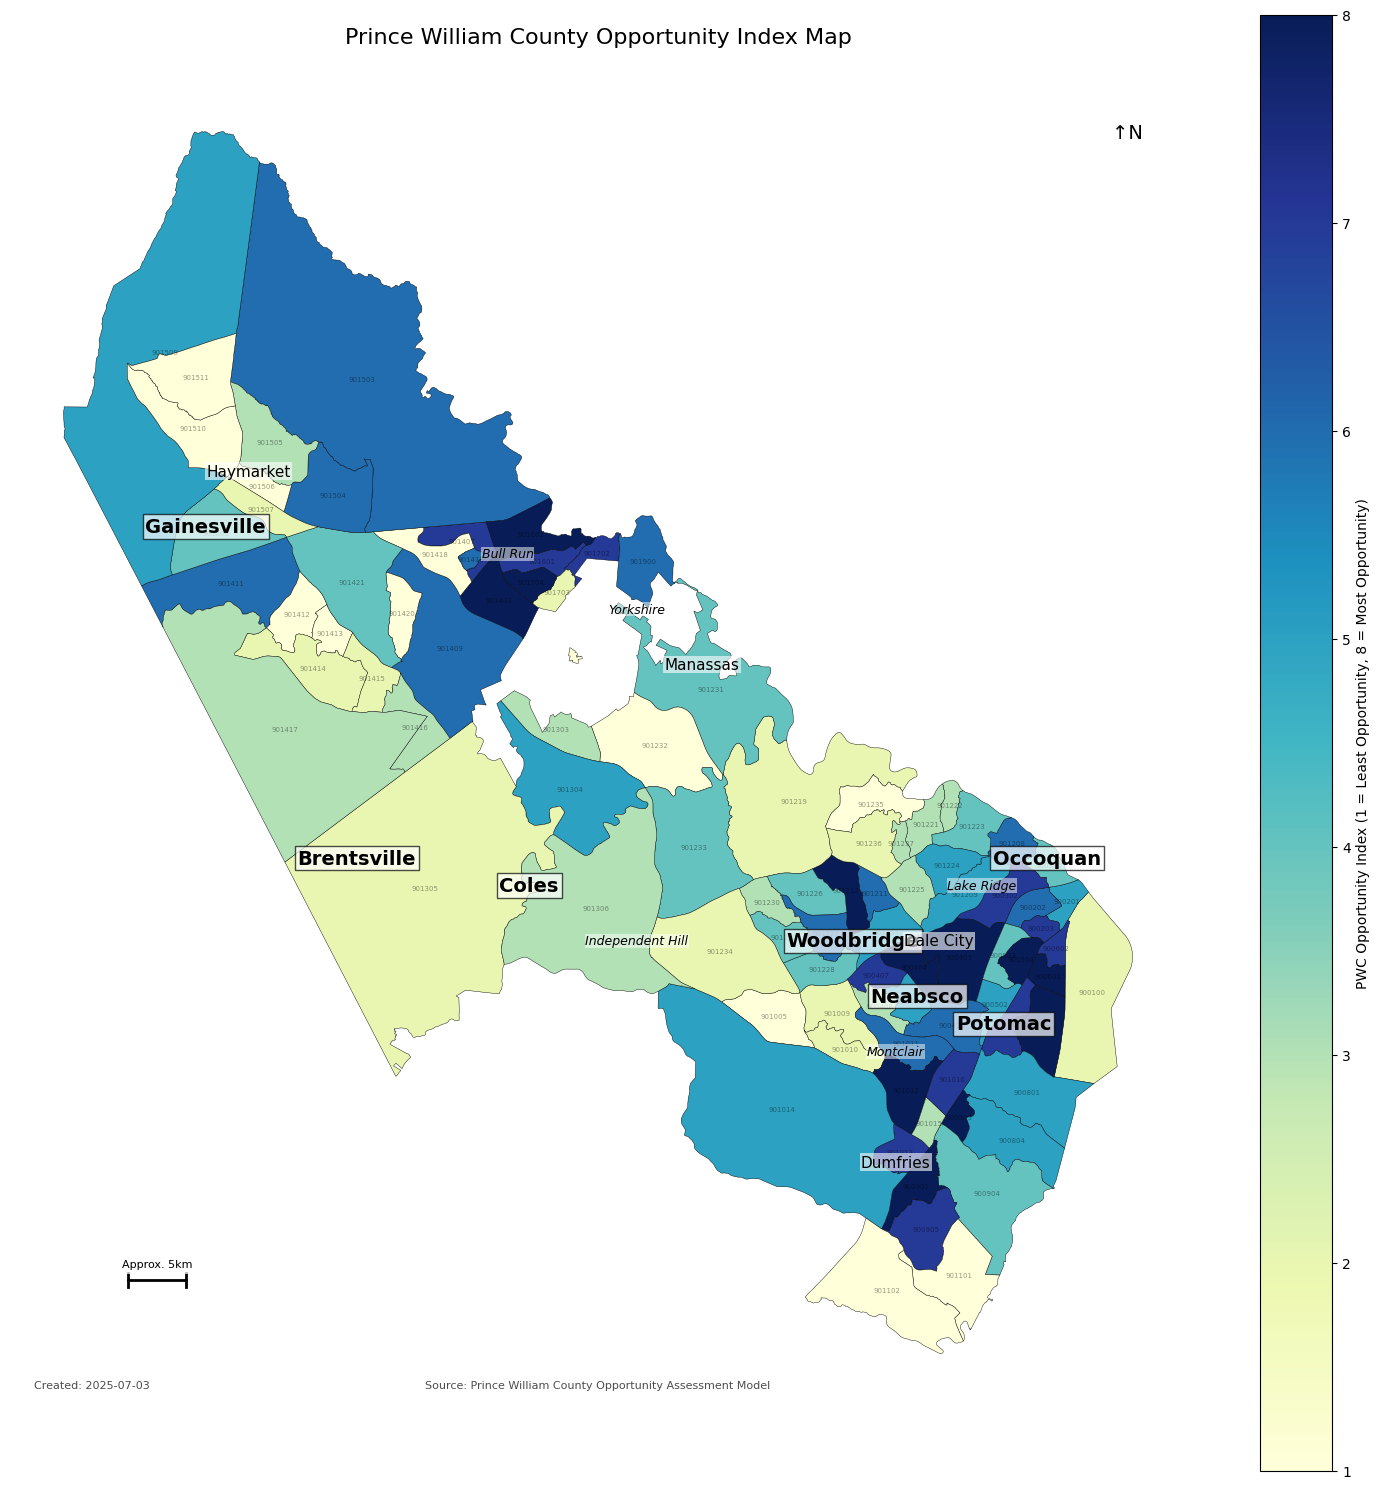

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Map image ready for download


In [ ]:
import geopandas as gpd
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd
import io

# Upload shapefile parts (you'll need to upload all .shp, .shx, .dbf, .prj files)
print("Please upload the census tract shapefile components (multiple files):")
print("Upload .shp, .shx, .dbf, and .prj files when prompted")
uploaded = files.upload()

# Organize uploaded files
shapefile_parts = {}
for filename in uploaded.keys():
    with open(filename, 'wb') as f:
        f.write(uploaded[filename])
    shapefile_parts[filename] = filename

# Find the .shp file from uploaded files
shp_file = [f for f in shapefile_parts.keys() if f.endswith('.shp')]
if not shp_file:
    print("No .shp file found in uploads. Please upload a shapefile.")
else:
    shp_file = shp_file[0]

    # Load the shapefile
    gdf_shp = gpd.read_file(shp_file)

    # Check CRS and preview
    print("Shapefile CRS:")
    print(gdf_shp.crs)
    print("\nShapefile columns:")
    print(gdf_shp.columns.tolist())

    # Prepare data for merge
    df_final_copy["GEOID"] = df_final_copy["ID"].astype(str)
    gdf_shp["GEOID"] = gdf_shp["GEOID"].astype(str)

    # Merge shapefile with opportunity index data
    merged_data = df_final_copy[["GEOID", "PWC_Opportunity_Index", "Opportunity_Tier"]].merge(
        gdf_shp,
        on="GEOID",
        how="left"
    )

    # Ensure the result is a GeoDataFrame
    merged_data = gpd.GeoDataFrame(merged_data, geometry='geometry')

    # Check for missing merges
    missing = merged_data.loc[merged_data.geometry.isna()].shape[0]
    print(f"\nUnmatched tracts: {missing}")

    # If there are missing geometries, they can't be mapped
    if missing > 0:
        print("Warning: Some census tracts couldn't be matched to shapefile geometries.")
        merged_data = merged_data.dropna(subset=['geometry'])

    # Define helper functions for map labels and elements
    def add_geographic_labels(ax, merged_data):
        """Add geographic labels to the visualization"""
        # Add census tract labels
        for idx, row in merged_data.iterrows():
            if row.geometry is not None:
                centroid = row.geometry.centroid
                ax.text(
                    centroid.x,
                    centroid.y,
                    row.get('TRACTCE', ''),  # Use .get in case TRACTCE is missing
                    fontsize=5,
                    ha='center',
                    va='center',
                    alpha=0.4
                )

        # Define district and city locations
        features = {
            'districts': {
                'Brentsville': (-77.58, 38.68),
                'Coles': (-77.5, 38.67),
                'Gainesville': (-77.65, 38.8),
                'Neabsco': (-77.32, 38.63),
                'Potomac': (-77.28, 38.62),
                'Woodbridge': (-77.35, 38.65),
                'Occoquan': (-77.26, 38.68)
            },
            'cities': {
                'Manassas': (-77.42, 38.75),
                'Haymarket': (-77.63, 38.82),
                'Dale City': (-77.31, 38.65),
                'Dumfries': (-77.33, 38.57),
            },
            'neighborhoods': {
                'Lake Ridge': (-77.29, 38.67),
                'Montclair': (-77.33, 38.61),
                'Yorkshire': (-77.45, 38.77),
                'Bull Run': (-77.51, 38.79),
                'Independent Hill': (-77.45, 38.65)
            }
        }

        # Add labels with different styles
        for feature_type, locations in features.items():
            for name, coords in locations.items():
                style = {
                    'districts': {'fontsize': 14, 'fontweight': 'bold', 'bbox': dict(facecolor='white', alpha=0.7, edgecolor='black', pad=2)},
                    'cities': {'fontsize': 11, 'bbox': dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1)},
                    'neighborhoods': {'fontsize': 9, 'style': 'italic', 'bbox': dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.5)}
                }[feature_type]

                ax.text(
                    coords[0],
                    coords[1],
                    name,
                    ha='center',
                    va='center',
                    **style
                )

    def add_map_elements(ax):
        """Add map elements (North arrow, scale bar)"""
        # Add North arrow
        ax.text(
            0.95, 0.95, '↑N',
            transform=ax.transAxes,
            fontsize=14,
            ha='center',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
        )

        # Add scale bar
        bar_x = 0.1
        bar_y = 0.1
        bar_width = 0.05

        ax.plot([bar_x, bar_x + bar_width], [bar_y, bar_y], 'k-',
               transform=ax.transAxes, linewidth=2)
        ax.plot([bar_x, bar_x], [bar_y - 0.005, bar_y + 0.005], 'k-',
               transform=ax.transAxes, linewidth=2)
        ax.plot([bar_x + bar_width, bar_x + bar_width], [bar_y - 0.005, bar_y + 0.005], 'k-',
               transform=ax.transAxes, linewidth=2)

        ax.text(bar_x + bar_width/2, bar_y + 0.01, 'Approx. 5km',
               transform=ax.transAxes, ha='center', fontsize=8,
               bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        # Add creation date
        ax.text(
            0.02, 0.02,
            f'Created: {pd.Timestamp.now().strftime("%Y-%m-%d")}',
            transform=ax.transAxes,
            fontsize=8,
            alpha=0.7
        )

        # Add data source and model info
        ax.text(
            0.5, 0.02,
            'Source: Prince William County Opportunity Assessment Model',
            transform=ax.transAxes,
            fontsize=8,
            ha='center',
            alpha=0.7
        )

    # Create the map with a larger figure size
    fig, ax = plt.subplots(figsize=(15, 15))

    # Plot with merged data using YlGnBu (light yellow = low, dark blue = high)
    merged_data.plot(
        column="PWC_Opportunity_Index",
        cmap="YlGnBu",
        edgecolor="black",
        linewidth=0.3,
        legend=True,
        ax=ax,
        legend_kwds={'label': "PWC Opportunity Index (1 = Least Opportunity, 8 = Most Opportunity)"}
    )

    # Add district, neighborhood, and tract labels
    add_geographic_labels(ax, merged_data)

    # Add map elements (north arrow, scale bar, source text)
    add_map_elements(ax)

    # Final touches
    ax.set_title("Prince William County Opportunity Index Map", fontsize=16, pad=20)
    ax.axis('off')
    plt.tight_layout()

    # Save the map
    plt.savefig('PWC_Opportunity_Index_Map.png', dpi=300, bbox_inches='tight')
    plt.show()

    # For Colab, provide a download link
    try:
        from google.colab import files
        files.download('PWC_Opportunity_Index_Map.png')
        print("Map image ready for download")
    except:
        print("Map saved locally as 'PWC_Opportunity_Index_Map.png'")

In [ ]:
# =============================================
# MODERN OPPORTUNITY INDEX MAP WITH SIDE PANEL - UPDATED VERSION
# =============================================

print("\n\n--- CREATING MODERN OPPORTUNITY INDEX MAP WITH SIDE PANEL ---\n")

# Make sure necessary imports are available
import pandas as pd
import numpy as np
import folium
import geopandas as gpd
import branca.colormap as cm
from folium.plugins import MeasureControl
from google.colab import files
import json

# Use existing dataframe with opportunity data
print("Using existing opportunity index data...")
profile_data = pivot_df.copy()  # Use the pivot dataframe from comprehensive analysis
print(f"Loaded profile data with {len(profile_data)} census tracts")

# Enhanced dictionary for variable name mapping (ADDED DEMOGRAPHICS)
variable_name_map = {
    # Socioeconomic
    "LOWINCPCT": "Low Income Population",
    "UNEMPPCT": "Unemployment Rate",
    "LINGISOPCT": "Limited English Proficiency",
    "LESSHSPCT": "Less than High School Education",
    "E_POV150_P": "Population Below 150% Poverty Level",
    "With_PublicAssIncome_P": "Public Assistance Income",
    "With_SSI_P": "Supplemental Security Income",
    "E_UNINSUR_P": "Uninsured Population",
    "With_Medicaid_P": "Medicaid Coverage",
    "percent_food_insecure": "Food Insecurity Rate",
    "LIFEEXPPCT": "Life Expectancy",

    # Housing
    "PRE1960PCT": "Housing Built Before 1960",
    "E_HBURD_P": "Housing Cost Burden",
    "House_Vacant_P": "Vacant Housing",
    "E_MUNIT_P": "Multi-Unit Housing",
    "E_MOBILE_P": "Mobile Homes",
    "E_CROWD_P": "Crowded Housing",
    "Owner_occupied_P": "Owner-Occupied Housing",
    "Mean_Proportion_HHIncome": "Housing Cost as % of Income",
    "percent_homeowners": "Homeownership Rate",

    # Mobility (formerly Transportation)
    "PTRAF": "Traffic Volume",
    "E_NOVEH_P": "No Vehicle Access",
    "Mean_Transportation_time(min)": "Average Commute Time",
    "Work_Drivealone_P": "Drive Alone to Work",
    "Work_Carpooled_P": "Carpool to Work",
    "Work_PublicTransportation_P": "Public Transit to Work",
    "Work_Walk_P": "Walk to Work",
    "Work_Fromhome_P": "Work from Home",

    # Transportation Safety (formerly TransportationSafety)
    "Percent_Severe/Fatal": "Severe/Fatal Crashes",
    "Avg_Person_Injured/Kill": "Person Injuries/Fatalities",
    "Avg_Pedestrian_Injured/Kill": "Pedestrian Injuries/Fatalities",
    "Percent_Alcohol_Related": "Alcohol-Related Crashes",
    "Percent_Distracted_Related": "Distracted Driving Crashes",
    "Percent_Drowsy_Related": "Drowsy Driving Crashes",
    "Percent_Drug_Related": "Drug-Related Crashes",
    "Percent_Speed_Related": "Speed-Related Crashes",
    "Percent_Hitrun_Related": "Hit and Run Crashes",
    "Percent_Schoolzone_Related": "School Zone Crashes",
    "Percent_Lgtruck_Related": "Large Truck Crashes",
    "Percent_Young_Related": "Young Driver Crashes",
    "Percent_Senior_Related": "Senior Driver Crashes",
    "Percent_Bike_Related": "Bicycle Crashes",
    "Percent_Night_Related": "Nighttime Crashes",
    "Percent_Workzone_Related": "Work Zone Crashes",

    # Environmental
    "PM25": "Fine Particulate Matter",
    "OZONE": "Ozone Level",
    "DSLPM": "Diesel Particulate Matter",
    "NO2": "Nitrogen Dioxide",
    "CANCER": "Cancer Risk",
    "RESP": "Respiratory Hazard",
    "PTRAF": "Traffic Proximity",
    "PWDIS": "Wastewater Discharge",
    "PNPL": "Superfund Sites",
    "PRMP": "RMP Facilities",
    "PTSDF": "Hazardous Waste Sites",
    "UST": "Underground Storage Tanks",
    "WATR": "Water Discharge Sites",
    "RSEI_AIR": "Air Releases",

    # Public Health (formerly PublicHealth)
    "EMS_Calls": "EMS Emergency Calls",
    "Chronic_History": "Chronic Health Conditions",  # Updated
    "Structure_Fires": "Structure Fire Incidents",
    "Violence_Calls": "Violence-Related Calls",
    "Domestic": "Domestic-Related Calls",
    "Homeless": "Homelessness-Related Calls",
    "Opioid_Calls": "Opioid-Related Emergency Calls",
    "Calls_Per_HVU_Caller": "Calls per High Volume User",

    # Demographics
    "DISABILITYPCT": "Disability Rate",
    "UNDER5PCT": "Under 5 Years Old",
    "OVER64PCT": "Over 64 Years Old",
    "E_SNGPNT_P": "Single Parent Households",
    "E_GROUPQ_P": "Group Quarters Population",
    "Total_Population": "Total Population",
    "Median_Age": "Median Age",
    "Age_Dependency_Ratio": "Age Dependency Ratio",
    "Old-age_Dependency_Ratio": "Old-Age Dependency Ratio",
    "Child_Dependency_Ratio": "Child Dependency Ratio",
    "Prop_White": "White Population",
    "Sex_Ratio(males per 100 females)": "Sex Ratio (males per 100 females)",
    "Prop_Black": "Black Population",
    "Prop_Hisp": "Hispanic Population"
}

# Enhanced domain categorization with updated domain names
domain_categories = {
    "Socioeconomic": [
        "LOWINCPCT", "UNEMPPCT", "LINGISOPCT", "LESSHSPCT", "E_POV150_P",
        "With_PublicAssIncome_P", "With_SSI_P", "E_UNINSUR_P", "With_Medicaid_P",
        "percent_food_insecure", "LIFEEXPPCT"
    ],
    "Housing": [
        "PRE1960PCT", "E_HBURD_P", "House_Vacant_P", "E_MUNIT_P", "E_MOBILE_P",
        "E_CROWD_P", "Owner_occupied_P", "Mean_Proportion_HHIncome", "percent_homeowners"
    ],
    "Mobility": [  # Changed from Transportation
        "PTRAF", "E_NOVEH_P", "Mean_Transportation_time(min)", "Work_Drivealone_P",
        "Work_Carpooled_P", "Work_PublicTransportation_P", "Work_Walk_P", "Work_Fromhome_P"
    ],
    "Transportation Safety": [  # Changed from TransportationSafety (added space)
        "Percent_Severe/Fatal", "Avg_Person_Injured/Kill", "Avg_Pedestrian_Injured/Kill",
        "Percent_Alcohol_Related", "Percent_Distracted_Related", "Percent_Drowsy_Related",
        "Percent_Drug_Related", "Percent_Speed_Related", "Percent_Hitrun_Related",
        "Percent_Schoolzone_Related", "Percent_Lgtruck_Related", "Percent_Young_Related",
        "Percent_Senior_Related", "Percent_Bike_Related", "Percent_Night_Related",
        "Percent_Workzone_Related"
    ],
    "Environmental": [
        "PM25", "OZONE", "DSLPM", "NO2", "CANCER", "RESP", "PTRAF", "PWDIS",
        "PNPL", "PRMP", "PTSDF", "UST", "WATR", "RSEI_AIR"
    ],
    "Public Health": [  # Changed from PublicHealth (added space)
        "EMS_Calls","Chronic_History", "Structure_Fires", "Violence_Calls",
        "Homeless", "Domestic", "Opioid_Calls", "Calls_Per_HVU_Caller",
    ],
    "Demographics": [
        "DISABILITYPCT", "UNDER5PCT", "OVER64PCT", "E_SNGPNT_P", "E_GROUPQ_P",
        "Total_Population", "Median_Age", "Age_Dependency_Ratio",
        "Old-age_Dependency_Ratio", "Child_Dependency_Ratio", "Prop_White",
        "Sex_Ratio(males per 100 females)", "Prop_Black", "Prop_Hisp"
    ]
}

# Filter domain categories to only include variables that exist in the data
print("Filtering variables to only include those that exist in the data...")
filtered_domain_categories = {}
for domain_name, variables in domain_categories.items():
    existing_variables = [var for var in variables if var in profile_data.columns]
    filtered_domain_categories[domain_name] = existing_variables
    print(f"{domain_name}: {len(existing_variables)}/{len(variables)} variables found")

# Variables where higher values are better (reverse scoring for opportunity interpretation)
reverse_variables = [
    'percent_homeowners', 'Owner_occupied_P', 'Work_Carpooled_P', 'Work_PublicTransportation_P',
    'Work_Walk_P', 'Work_Fromhome_P', 'Total_Population', 'LIFEEXPPCT'
]

# Calculate percentile-based thresholds for each variable
print("Calculating percentile-based thresholds...")
variable_thresholds = {}

for domain_name, variables in filtered_domain_categories.items():
    for variable in variables:
        if variable in profile_data.columns:
            values = profile_data[variable].dropna()
            if len(values) > 0:
                if variable in reverse_variables:
                    variable_thresholds[variable] = {
                        'p33': values.quantile(0.33),
                        'p67': values.quantile(0.67),
                        'reverse': True
                    }
                else:
                    variable_thresholds[variable] = {
                        'p33': values.quantile(0.33),
                        'p67': values.quantile(0.67),
                        'reverse': False
                    }

print(f"Calculated thresholds for {len(variable_thresholds)} variables")

# Function to get a readable variable name
def get_readable_name(var_name):
    return variable_name_map.get(var_name, var_name.replace('_', ' '))

# Upload shapefile components
print("Please upload the census tract shapefile components (multiple files):")
print("Upload .shp, .shx, .dbf, and .prj files when prompted")
uploaded = files.upload()

# Organize uploaded files
shapefile_parts = {}
for filename in uploaded.keys():
    with open(filename, 'wb') as f:
        f.write(uploaded[filename])
    shapefile_parts[filename] = filename

# Find the .shp file from uploaded files
shp_file = [f for f in shapefile_parts.keys() if f.endswith('.shp')]
if not shp_file:
    print("No .shp file found in uploads. Please upload a shapefile.")
else:
    shp_file = shp_file[0]
    print(f"Found shapefile: {shp_file}")

    # Load the shapefile
    census_tracts = gpd.read_file(shp_file)
    print(f"Shapefile CRS:\n{census_tracts.crs}\n")
    print(f"Shapefile columns:\n{census_tracts.columns.tolist()}")

    # Prepare data for merge
    print("Preparing data for merge...")
    # Create GEOID column in profile data if needed - using CensusTract
    if 'GEOID' not in profile_data.columns:
        profile_data["GEOID"] = profile_data["CensusTract"].astype(str)

    # Ensure GEOID is string type in both datasets
    census_tracts["GEOID"] = census_tracts["GEOID"].astype(str)
    profile_data["GEOID"] = profile_data["GEOID"].astype(str)

    # Filter census tracts to just Prince William County if needed (COUNTYFP = 153 for Prince William)
    if 'COUNTYFP' in census_tracts.columns:
        pwc_tracts = census_tracts[census_tracts['COUNTYFP'] == '153']
        if len(pwc_tracts) > 0:
            print(f"Filtering to {len(pwc_tracts)} Prince William County census tracts")
            census_tracts = pwc_tracts

    # Merge data
    print("Merging data with boundaries...")
    merged_data = profile_data.merge(
        census_tracts,
        on="GEOID",
        how="left"
    )

    # Convert to GeoDataFrame
    merged_data = gpd.GeoDataFrame(merged_data, geometry='geometry')

    # Check for missing merges
    missing = merged_data.loc[merged_data.geometry.isna()].shape[0]
    print(f"\nUnmatched tracts: {missing}")

    if missing > 0:
        print("Warning: Some census tracts couldn't be matched to shapefile geometries.")
        merged_data = merged_data.dropna(subset=['geometry'])

    # Create a dictionary to prepare our tract data for JavaScript
    tract_data = {}
    for idx, row in merged_data.iterrows():
        tract_id = row['CensusTract']

        # Domain rankings - need to map old names to new names for lookup
        domain_ranks = {}
        # Map old domain names from CSV to new display names
        old_to_new_domain_map = {
            'Socioeconomic': 'Socioeconomic',
            'Housing': 'Housing',
            'Transportation': 'Mobility',
            'TransportationSafety': 'Transportation Safety',
            'Environmental': 'Environmental',
            'PublicHealth': 'Public Health'
        }

        old_domains = ['Socioeconomic', 'Housing', 'Transportation', 'TransportationSafety', 'Environmental', 'PublicHealth']
        for old_domain in old_domains:
            rank_col = f"{old_domain}_Rank"
            if rank_col in row and pd.notna(row[rank_col]):
                new_domain = old_to_new_domain_map[old_domain]
                domain_ranks[new_domain] = int(row[rank_col])

        # Top variables by domain
        domain_variables = {}
        for old_domain in old_domains:
            domain_vars = []
            for i in range(1, 4):
                var_col = f"{old_domain}_Var{i}"
                if var_col in row and pd.notna(row[var_col]) and row[var_col]:
                    domain_vars.append(get_readable_name(row[var_col]))
            if domain_vars:
                new_domain = old_to_new_domain_map[old_domain]
                domain_variables[new_domain] = domain_vars

        # Geographic identifiers
        def safe_get(column_name, default="Not Available"):
            if column_name in row and pd.notna(row[column_name]) and str(row[column_name]).strip():
                return str(row[column_name]).strip()
            return default

        tract_data[tract_id] = {
            'opportunity_index': float(row['PWC_Opportunity_Index']),  # Updated column name
            'opportunity_tier': row['Opportunity_Tier'] if 'Opportunity_Tier' in row else '',  # Updated
            'top_domain': old_to_new_domain_map.get(row['Top_Domain'], row['Top_Domain']) if 'Top_Domain' in row else '',
            'domain_ranks': domain_ranks,
            'domain_variables': domain_variables,
            'district': safe_get('District'),
            'neighborhood': safe_get('Neighborhood'),
            'first_due': safe_get('1st Due')
        }

    # Add opportunity_index to the GeoJSON properties
    merged_data['opportunity_index'] = merged_data['PWC_Opportunity_Index']

    # Create map file
    print("Creating modern opportunity index map...")

    # Prepare GeoJSON
    geo_data = merged_data.to_json()
    tract_data_json = json.dumps(tract_data).replace("'", "\\'")

    # Prepare domain categories and thresholds for JavaScript
    domain_categories_json = json.dumps(filtered_domain_categories)
    variable_thresholds_json = json.dumps(variable_thresholds)
    variable_name_map_json = json.dumps(variable_name_map)

    # HTML file name
    output_file = "Prince_William_County_Opportunity_Index_Map.html"

    # Write HTML file
    with open(output_file, "w") as f:
        # Write the complete HTML file
        bounds = merged_data.total_bounds
        center_lat = (bounds[1] + bounds[3]) / 2
        center_lon = (bounds[0] + bounds[2]) / 2

        html_content = f'''<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Prince William County Opportunity Index Map</title>
    <link rel="stylesheet" href="https://unpkg.com/leaflet@1.7.1/dist/leaflet.css"/>
    <script src="https://unpkg.com/leaflet@1.7.1/dist/leaflet.js"></script>
    <link href="https://fonts.googleapis.com/css2?family=Roboto:wght@300;400;500;700&display=swap" rel="stylesheet">
    <style>
        * {{
            margin: 0;
            padding: 0;
            box-sizing: border-box;
            font-family: 'Roboto', sans-serif;
        }}

        body {{
            display: flex;
            height: 100vh;
            overflow: hidden;
            background-color: #1f2937;
            color: #f3f4f6;
        }}

        #map {{
            flex: 3;
            height: 100%;
            z-index: 1;
        }}

        #panel {{
            flex: 1;
            min-width: 320px;
            max-width: 400px;
            padding: 20px;
            background-color: #1f2937;
            box-shadow: -3px 0 10px rgba(0,0,0,0.2);
            overflow-y: auto;
            display: flex;
            flex-direction: column;
            z-index: 2;
            border-left: 1px solid #374151;
        }}

        #panel.hidden {{
            display: none;
        }}

        h1 {{
            margin-top: 0;
            margin-bottom: 15px;
            font-size: 22px;
            font-weight: 500;
            text-align: center;
            color: #f3f4f6;
        }}

        h2 {{
            margin-top: 0;
            font-size: 18px;
            font-weight: 500;
            color: #f3f4f6;
        }}

        h3 {{
            margin-top: 20px;
            margin-bottom: 10px;
            font-size: 16px;
            font-weight: 500;
            color: #f3f4f6;
        }}

        hr {{
            border: 0;
            height: 1px;
            background: #374151;
            margin: 15px 0;
        }}

        table {{
            width: 100%;
            border-collapse: collapse;
            margin-bottom: 15px;
            background-color: #283548;
            border-radius: 8px;
            overflow: hidden;
        }}

        td {{
            padding: 10px;
            border-bottom: 1px solid #374151;
        }}

        tr:last-child td {{
            border-bottom: none;
        }}

        ul {{
            margin-top: 8px;
            margin-bottom: 15px;
            padding-left: 25px;
        }}

        li {{
            margin-bottom: 6px;
            color: #e5e7eb;
        }}

        .info {{
            padding: 8px 10px;
            font: 14px/16px 'Roboto', sans-serif;
            background: #283548;
            color: #f3f4f6;
            box-shadow: 0 0 15px rgba(0,0,0,0.2);
            border-radius: 8px;
            border: 1px solid #374151;
        }}

        .info h4 {{
            margin: 0 0 8px;
            color: #9ca3af;
            font-weight: 500;
        }}

        .legend {{
            line-height: 20px;
            color: #e5e7eb;
        }}

        .legend i {{
            width: 18px;
            height: 18px;
            float: left;
            margin-right: 8px;
            opacity: 0.85;
        }}

        .place-label {{
            background-color: transparent;
            border: none;
            white-space: nowrap;
        }}

        .subtitle {{
            text-align: center;
            font-size: 14px;
            margin-bottom: 20px;
            color: #9ca3af;
            font-weight: 300;
        }}

        .panel-header {{
            text-align: center;
            margin-bottom: 25px;
        }}

        .panel-content {{
            flex: 1;
        }}

        .info-box {{
            background-color: #283548;
            border: 1px solid #374151;
            border-radius: 8px;
            padding: 15px;
            margin-bottom: 20px;
            box-shadow: 0 2px 5px rgba(0,0,0,0.1);
        }}

        .info-box p {{
            margin-bottom: 8px;
            color: #e5e7eb;
        }}

        .info-box p:last-child {{
            margin-bottom: 0;
        }}

        .info-box strong {{
            color: #f3f4f6;
            font-weight: 500;
        }}

        .domain-section {{
            background-color: #283548;
            border-radius: 8px;
            padding: 12px;
            margin-bottom: 12px;
        }}

        .domain-section strong {{
            color: #f3f4f6;
            font-weight: 500;
        }}

        .welcome-message {{
            padding: 30px;
            text-align: center;
            font-size: 16px;
            color: #9ca3af;
            height: 100%;
            display: flex;
            align-items: center;
            justify-content: center;
            font-weight: 300;
        }}

        .close-button {{
            position: absolute;
            top: 15px;
            right: 15px;
            border: none;
            background: none;
            font-size: 20px;
            font-weight: 300;
            color: #9ca3af;
            cursor: pointer;
            transition: color 0.2s;
        }}

        .close-button:hover {{
            color: #f3f4f6;
        }}

        .opportunity-value {{
            display: flex;
            align-items: center;
            margin: 15px 0;
        }}

        .opportunity-value-number {{
            font-size: 24px;
            font-weight: 700;
            margin-right: 10px;
            color: #f3f4f6;
        }}

        .opportunity-value-label {{
            font-size: 14px;
            color: #9ca3af;
        }}

        .opportunity-tier {{
            display: inline-block;
            padding: 3px 10px;
            border-radius: 12px;
            font-size: 14px;
            font-weight: 500;
            margin-top: 5px;
            margin-bottom: 10px;
        }}

        .tier-less {{
            background-color: rgba(220, 38, 38, 0.2);
            color: #ef4444;
        }}

        .tier-moderate {{
            background-color: rgba(245, 158, 11, 0.2);
            color: #f59e0b;
        }}

        .tier-high {{
            background-color: rgba(16, 185, 129, 0.2);
            color: #10b981;
        }}

        .tier-exceptional {{
            background-color: rgba(5, 150, 105, 0.2);
            color: #059669;
        }}

        .rank-number {{
            display: inline-block;
            width: 24px;
            height: 24px;
            border-radius: 50%;
            background-color: #374151;
            color: #f3f4f6;
            text-align: center;
            line-height: 24px;
            margin-right: 8px;
            font-weight: 500;
        }}

        .geographic-info {{
            background-color: #374151;
            border-radius: 8px;
            padding: 12px;
            margin-bottom: 15px;
        }}

        .geographic-info .geo-item {{
            display: flex;
            justify-content: space-between;
            margin-bottom: 6px;
            padding: 2px 0;
        }}

        .geographic-info .geo-item:last-child {{
            margin-bottom: 0;
        }}

        .geographic-info .geo-label {{
            font-weight: 500;
            color: #9ca3af;
            min-width: 120px;
        }}

        .geographic-info .geo-value {{
            color: #f3f4f6;
            text-align: right;
            flex: 1;
        }}

        .leaflet-container {{
            background-color: #111827;
        }}

        .leaflet-control-zoom a {{
            background-color: #283548;
            color: #f3f4f6;
            border-color: #374151;
        }}

        .leaflet-control-zoom a:hover {{
            background-color: #374151;
        }}

        .leaflet-control-attribution {{
            background-color: rgba(40, 53, 72, 0.8) !important;
            color: #9ca3af !important;
        }}

        .leaflet-control-attribution a {{
            color: #60a5fa !important;
        }}

        .district-label {{
            font-weight: bold;
            font-size: 15px;
            background-color: rgba(40, 53, 72, 0.85);
            border: 1px solid #4b5563;
            border-radius: 4px;
            padding: 4px 8px;
            box-shadow: 0 2px 4px rgba(0,0,0,0.3);
        }}

        .neighborhood-label {{
            font-weight: 400;
            font-style: italic;
            font-size: 12px;
            background-color: rgba(40, 53, 72, 0.75);
            border: 1px solid #4b5563;
            border-radius: 3px;
            padding: 2px 6px;
            box-shadow: 0 1px 2px rgba(0,0,0,0.3);
        }}

        .tab-container {{
            margin-top: 20px;
            background-color: #283548;
            border-radius: 8px;
            overflow: hidden;
        }}

        .tab-header {{
            display: flex;
            flex-wrap: wrap;
            background-color: #1f2937;
            border-bottom: 1px solid #374151;
        }}

        .tab-button {{
            flex: 1;
            min-width: 85px;
            padding: 8px 6px;
            border: none;
            background: none;
            color: #9ca3af;
            cursor: pointer;
            font-size: 10px;
            font-weight: 500;
            transition: all 0.2s;
            border-bottom: 2px solid transparent;
        }}

        .tab-button:hover {{
            color: #f3f4f6;
            background-color: rgba(55, 65, 81, 0.3);
        }}

        .tab-button.active {{
            color: #f3f4f6;
            border-bottom-color: #60a5fa;
            background-color: rgba(55, 65, 81, 0.5);
        }}

        .tab-content {{
            display: none;
            padding: 15px;
            max-height: 300px;
            overflow-y: auto;
        }}

        .tab-content.active {{
            display: block;
        }}

        .variable-item {{
            display: flex;
            justify-content: space-between;
            align-items: center;
            padding: 8px 0;
            border-bottom: 1px solid #374151;
        }}

        .variable-item:last-child {{
            border-bottom: none;
        }}

        .variable-name {{
            font-size: 13px;
            color: #e5e7eb;
            flex: 1;
            margin-right: 10px;
        }}

        .variable-value {{
            display: flex;
            align-items: center;
            gap: 6px;
            flex-wrap: wrap;
        }}

        .value {{
            font-weight: 600;
            color: #f3f4f6;
            min-width: 50px;
            text-align: right;
        }}

        .risk-direction {{
            display: flex;
            align-items: center;
            gap: 4px;
        }}

        .risk-arrow {{
            font-size: 12px;
            font-weight: bold;
        }}

        .increases-opportunity {{
            color: #10b981;
        }}

        .decreases-opportunity {{
            color: #ef4444;
        }}

        .neutral-opportunity {{
            color: #9ca3af;
        }}

        .risk-text {{
            font-size: 9px;
            font-weight: 500;
        }}

        .demographic-value {{
            display: flex;
            align-items: center;
            gap: 6px;
            flex-wrap: wrap;
        }}

        .demographic-item {{
            display: flex;
            justify-content: space-between;
            align-items: center;
            padding: 8px 0;
            border-bottom: 1px solid #374151;
        }}

        .demographic-item:last-child {{
            border-bottom: none;
        }}
    </style>
</head>
<body>
    <div id="map"></div>
    <div id="panel" class="hidden">
        <button class="close-button" onclick="document.getElementById('panel').classList.add('hidden')">X</button>
        <div class="panel-header">
            <h1>Prince William County Opportunity Index</h1>
            <div class="subtitle">Census Tract Details</div>
        </div>
        <div class="panel-content" id="panel-content">
            <div class="welcome-message">
                Click on a census tract to view detailed information
            </div>
        </div>
    </div>

    <script>
        var map = L.map('map', {{
            center: [{center_lat}, {center_lon}],
            zoom: 10,
            zoomControl: false
        }});

        L.tileLayer('https://cartodb-basemaps-{{s}}.global.ssl.fastly.net/dark_all/{{z}}/{{x}}/{{y}}{{r}}.png', {{
            attribution: '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> &copy; <a href="https://carto.com/attributions">CARTO</a>',
            subdomains: 'abcd',
            maxZoom: 19
        }}).addTo(map);

        L.control.zoom({{position: 'topright'}}).addTo(map);

        var selectedLayer = null;
        var domainCategories = {domain_categories_json};
        var variableThresholds = {variable_thresholds_json};
        var variableNameMap = {variable_name_map_json};

        function getOpportunityDirection(value, domain, variable) {{
            var numValue = parseFloat(value);
            if (isNaN(numValue)) {{
                return {{ arrow: '→', text: 'Neutral', class: 'neutral-opportunity' }};
            }}

            var threshold = variableThresholds[variable];
            if (!threshold) {{
                return {{ arrow: '→', text: 'Neutral', class: 'neutral-opportunity' }};
            }}

            var median = (threshold.p33 + threshold.p67) / 2;

            if (threshold.reverse) {{
                if (numValue > median) {{
                    return {{ arrow: '↓', text: 'Decreases Impact', class: 'decreases-opportunity' }};
                }} else {{
                    return {{ arrow: '↑', text: 'Increases Impact', class: 'increases-opportunity' }};
                }}
            }} else {{
                if (numValue > median) {{
                    return {{ arrow: '↑', text: 'Increases Impact', class: 'increases-opportunity' }};
                }} else {{
                    return {{ arrow: '↓', text: 'Decreases Impact', class: 'decreases-opportunity' }};
                }}
            }}
        }}

        function showTab(tabName) {{
            var contents = document.querySelectorAll('.tab-content');
            contents.forEach(function(content) {{
                content.classList.remove('active');
            }});

            var buttons = document.querySelectorAll('.tab-button');
            buttons.forEach(function(button) {{
                button.classList.remove('active');
            }});

            document.getElementById(tabName + '-content').classList.add('active');
            document.getElementById(tabName + '-button').classList.add('active');
        }}

        // YlGnBu color scheme: Light Yellow to Dark Blue
        function getColor(d) {{
            return d > 7 ? '#08519c' :   // Darkest blue
                   d > 6 ? '#3182bd' :   // Dark blue
                   d > 5 ? '#6baed6' :   // Medium blue
                   d > 4 ? '#9ecae1' :   // Light blue
                   d > 3 ? '#c7e9b4' :   // Light green
                   d > 2 ? '#edf8b1' :   // Yellow-green
                   d > 1 ? '#ffffcc' :   // Light yellow
                            '#ffffe5';   // Lightest yellow
        }}

        function style(feature) {{
            return {{
                fillColor: getColor(feature.properties.opportunity_index),
                weight: 1.5,
                opacity: 1,
                color: '#1f2937',
                fillOpacity: 0.85
            }};
        }}

        function highlightFeature(e) {{
            var layer = e.target;
            layer.setStyle({{
                weight: 3,
                color: '#f3f4f6',
                dashArray: '',
                fillOpacity: 0.9
            }});
            if (!L.Browser.ie && !L.Browser.opera && !L.Browser.edge) {{
                layer.bringToFront();
            }}
            info.update(layer.feature.properties);
        }}

        function resetHighlight(e) {{
            if (selectedLayer !== e.target) {{
                geojson.resetStyle(e.target);
            }}
            info.update();
        }}

        function getTierClass(tier) {{
            if (tier.includes('Less')) return 'tier-less';
            if (tier.includes('Moderate')) return 'tier-moderate';
            if (tier.includes('High') && !tier.includes('Exceptional')) return 'tier-high';
            if (tier.includes('Exceptional')) return 'tier-exceptional';
            return '';
        }}

        function createVariableList(properties, domain) {{
            var html = '';
            var variables = domainCategories[domain];

            if (variables && variables.length > 0) {{
                variables.forEach(function(variable) {{
                    var value = properties[variable];
                    var displayName = variableNameMap[variable] || variable;
                    var displayValue = 'N/A';

                    if (value !== null && value !== undefined && value !== '') {{
                        var numValue = parseFloat(value);
                        if (!isNaN(numValue)) {{
                            var isPercentage = (variable.includes('PCT') || variable.includes('_P') ||
                                              variable.includes('Percent_') || variable.includes('percent_') ||
                                              variable.includes('Work_') || variable.includes('With_') ||
                                              variable.includes('Owner_occupied') || variable.includes('House_Vacant') ||
                                              variable.includes('Prop_')) &&
                                              !variable.includes('Calls') && !variable.includes('_Calls') &&
                                              !variable.includes('EMS') && !variable.includes('Medical') &&
                                              !variable.includes('Violence') && !variable.includes('Opioid') &&
                                              !variable.includes('Fires') && !variable.includes('Homeless') &&
                                              !variable.includes('VMC') && !variable.includes('SFPC') &&
                                              !variable.includes('Vegetation') && !variable.includes('LIFEEXPPCT') &&
                                              !variable.includes('PM25') && !variable.includes('OZONE') &&
                                              !variable.includes('NO2') && !variable.includes('PTRAF') &&
                                              !variable.includes('Total_Population') && !variable.includes('Median_Age');

                            if (isPercentage && numValue < 1) {{
                                displayValue = Math.round(numValue * 100) + '%';
                            }} else if (isPercentage && numValue >= 1) {{
                                displayValue = Math.round(numValue) + '%';
                            }} else if (variable === 'Median_Age') {{
                                displayValue = Math.round(numValue) + ' years';
                            }} else if (variable.includes('Ratio')) {{
                                displayValue = numValue.toFixed(2);
                            }} else {{
                                displayValue = Math.round(numValue * 100) / 100;
                            }}
                        }} else {{
                            displayValue = value;
                        }}
                    }}

                    if (domain === 'Demographics') {{
                        html += `
                            <div class="demographic-item">
                                <div class="variable-name">${{displayName}}</div>
                                <div class="demographic-value">
                                    <span class="value">${{displayValue}}</span>
                                </div>
                            </div>`;
                    }} else {{
                        var opportunityDir = getOpportunityDirection(value, domain, variable);

                        html += `
                            <div class="variable-item">
                                <div class="variable-name">${{displayName}}</div>
                                <div class="variable-value">
                                    <span class="value">${{displayValue}}</span>
                                    <div class="risk-direction">
                                        <span class="risk-arrow ${{opportunityDir.class}}">${{opportunityDir.arrow}}</span>
                                        <span class="risk-text ${{opportunityDir.class}}">${{opportunityDir.text}}</span>
                                    </div>
                                </div>
                            </div>`;
                    }}
                }});
            }} else {{
                html = '<div class="variable-item"><div class="variable-name">No variables available for this domain</div></div>';
            }}

            return html;
        }}

        function clickFeature(e) {{
            var properties = e.target.feature.properties;
            var tractId = properties.CensusTract;
            var tractData = tractDataLookup[tractId];

            if (selectedLayer) {{
                geojson.resetStyle(selectedLayer);
            }}

            selectedLayer = e.target;
            selectedLayer.setStyle({{
                weight: 4,
                color: '#60a5fa',
                dashArray: '',
                fillOpacity: 0.9
            }});

            if (!L.Browser.ie && !L.Browser.opera && !L.Browser.edge) {{
                selectedLayer.bringToFront();
            }}

            document.getElementById('panel').classList.remove('hidden');
            var panelContent = document.getElementById('panel-content');

            var html = `
                <div class="info-box">
                    <h2>Census Tract: ${{tractId}}</h2>
                    <div class="opportunity-value">
                        <div class="opportunity-value-number">${{tractData.opportunity_index.toFixed(1)}}</div>
                        <div class="opportunity-value-label">Service Opportunity Score<br/>(1-8 scale, higher = more opportunity)</div>
                    </div>
                    <div class="opportunity-tier ${{getTierClass(tractData.opportunity_tier)}}">${{tractData.opportunity_tier}}</div>
                    <p><strong>Primary Contributing Factor:</strong> ${{tractData.top_domain}}</p>
                </div>

                <div class="geographic-info">
                    <div class="geo-item">
                        <span class="geo-label">Census Tract:</span>
                        <span class="geo-value">${{tractId}}</span>
                    </div>
                    <div class="geo-item">
                        <span class="geo-label">District:</span>
                        <span class="geo-value">${{tractData.district}}</span>
                    </div>
                    <div class="geo-item">
                        <span class="geo-label">Neighborhood:</span>
                        <span class="geo-value">${{tractData.neighborhood}}</span>
                    </div>
                    <div class="geo-item">
                        <span class="geo-label">Fire and Rescue 1st Due:</span>
                        <span class="geo-value">${{tractData.first_due}}</span>
                    </div>
                </div>

                <h3>Domain Ranking</h3>
                <table>`;

            var domains = Object.keys(tractData.domain_ranks);
            for (var i = 0; i < domains.length; i += 2) {{
                html += '<tr>';
                html += `<td><span class="rank-number">${{tractData.domain_ranks[domains[i]]}}</span> ${{domains[i]}}</td>`;
                if (i + 1 < domains.length) {{
                    html += `<td><span class="rank-number">${{tractData.domain_ranks[domains[i+1]]}}</span> ${{domains[i+1]}}</td>`;
                }} else {{
                    html += '<td></td>';
                }}
                html += '</tr>';
            }}

            html += `</table>
                    <h3>Top Contributors to Identifying Opportunity</h3>`;

            var domainVars = Object.keys(tractData.domain_variables);
            for (var j = 0; j < domainVars.length; j++) {{
                var domain = domainVars[j];
                var variables = tractData.domain_variables[domain];
                html += `
                    <div class="domain-section">
                        <strong>${{domain}}:</strong>
                        <ul>`;
                for (var k = 0; k < variables.length; k++) {{
                    html += `<li>${{variables[k]}}</li>`;
                }}
                html += `</ul></div>`;
            }}

            html += `
                <h3>All Domain Variables</h3>
                <div class="tab-container">
                    <div class="tab-header">
                        <button id="socioeconomic-button" class="tab-button active" onclick="showTab('socioeconomic')">Socioeconomic</button>
                        <button id="housing-button" class="tab-button" onclick="showTab('housing')">Housing</button>
                        <button id="mobility-button" class="tab-button" onclick="showTab('mobility')">Mobility</button>
                        <button id="transportation-safety-button" class="tab-button" onclick="showTab('transportation-safety')">Transportation Safety</button>
                        <button id="environmental-button" class="tab-button" onclick="showTab('environmental')">Environmental</button>
                        <button id="public-health-button" class="tab-button" onclick="showTab('public-health')">Public Health</button>
                        <button id="demographics-button" class="tab-button" onclick="showTab('demographics')">Demographics</button>
                    </div>

                    <div id="socioeconomic-content" class="tab-content active">
                        ${{createVariableList(properties, 'Socioeconomic')}}
                    </div>
                    <div id="housing-content" class="tab-content">
                        ${{createVariableList(properties, 'Housing')}}
                    </div>
                    <div id="mobility-content" class="tab-content">
                        ${{createVariableList(properties, 'Mobility')}}
                    </div>
                    <div id="transportation-safety-content" class="tab-content">
                        ${{createVariableList(properties, 'Transportation Safety')}}
                    </div>
                    <div id="environmental-content" class="tab-content">
                        ${{createVariableList(properties, 'Environmental')}}
                    </div>
                    <div id="public-health-content" class="tab-content">
                        ${{createVariableList(properties, 'Public Health')}}
                    </div>
                    <div id="demographics-content" class="tab-content">
                        ${{createVariableList(properties, 'Demographics')}}
                    </div>
                </div>`;

            panelContent.innerHTML = html;

            // Pan to center on the clicked tract (but keep current zoom level)
            var center = e.target.getBounds().getCenter();
            map.panTo(center, {{
                animate: true,
                duration: 0.8
            }});
        }}

        function onEachFeature(feature, layer) {{
            layer.on({{
                mouseover: highlightFeature,
                mouseout: resetHighlight,
                click: clickFeature
            }});
        }}

        var tractDataLookup = {tract_data_json};
        var geoData = {geo_data};

        var geojson = L.geoJSON(geoData, {{
            style: style,
            onEachFeature: onEachFeature
        }}).addTo(map);

        var info = L.control({{position: 'topright'}});

        info.onAdd = function (map) {{
            this._div = L.DomUtil.create('div', 'info');
            this.update();
            return this._div;
        }};

        info.update = function (props) {{
            this._div.innerHTML = '<h4>Prince William County Opportunity Index</h4>' +  (props ?
                '<b>Census Tract: ' + props.CensusTract + '</b><br />' +
                'Opportunity Index: ' + (props.opportunity_index ? props.opportunity_index.toFixed(1) : 'N/A') + '/8'
                : 'Hover over a census tract');
        }};

        info.addTo(map);

        var legend = L.control({{position: 'bottomright'}});

        legend.onAdd = function (map) {{
            var div = L.DomUtil.create('div', 'info legend'),
                grades = [0, 1, 2, 3, 4, 5, 6, 7],
                labels = [],
                from, to;

            div.innerHTML = '<h4>Opportunity Index</h4><div style="text-align:center;margin-bottom:8px;font-size:12px;">(higher = more opportunity)</div>';

            for (var i = 0; i < grades.length; i++) {{
                from = grades[i];
                to = grades[i + 1];

                labels.push(
                    '<i style="background:' + getColor(from + 1) + '"></i> ' +
                    from + (to ? '&ndash;' + to : '+'));
            }}

            div.innerHTML += labels.join('<br>');
            return div;
        }};

        legend.addTo(map);

        var placeLabels = {{
            districts: [
                {{name: "Brentsville", location: [38.68, -77.58]}},
                {{name: "Coles", location: [38.67, -77.5]}},
                {{name: "Gainesville", location: [38.8, -77.65]}},
                {{name: "Neabsco", location: [38.63, -77.32]}},
                {{name: "Occoquan", location: [38.68, -77.26]}},
                {{name: "Potomac", location: [38.62, -77.28]}},
                {{name: "Woodbridge", location: [38.66, -77.30]}}
            ],
            neighborhoods: [
                {{name: "Manassas", location: [38.75, -77.42]}},
                {{name: "Haymarket", location: [38.82, -77.63]}},
                {{name: "Dale City", location: [38.65, -77.31]}},
                {{name: "Dumfries", location: [38.57, -77.33]}},
                {{name: "Lake Ridge", location: [38.67, -77.29]}},
                {{name: "Montclair", location: [38.61, -77.33]}},
                {{name: "Yorkshire", location: [38.77, -77.45]}},
                {{name: "Bull Run", location: [38.79, -77.51]}},
                {{name: "Independent Hill", location: [38.65, -77.45]}}
            ]
        }};

        var labelLayers = {{
            districts: L.layerGroup(),
            neighborhoods: L.layerGroup()
        }};

        function createLabels() {{
            placeLabels.districts.forEach(function(place) {{
                var icon = L.divIcon({{
                    className: 'place-label',
                    html: '<div class="district-label">' + place.name + '</div>',
                    iconSize: [110, 32],
                    iconAnchor: [55, 16]
                }});

                L.marker(place.location, {{
                    icon: icon,
                    interactive: false,
                    keyboard: false
                }}).addTo(labelLayers.districts);
            }});

            placeLabels.neighborhoods.forEach(function(place) {{
                var icon = L.divIcon({{
                    className: 'place-label',
                    html: '<div class="neighborhood-label">' + place.name + '</div>',
                    iconSize: [80, 25],
                    iconAnchor: [40, 12]
                }});

                L.marker(place.location, {{
                    icon: icon,
                    interactive: false,
                    keyboard: false
                }}).addTo(labelLayers.neighborhoods);
            }});

            labelLayers.districts.addTo(map);
        }}

        createLabels();

        map.on('zoomend', function() {{
            var zoom = map.getZoom();

            if (zoom < 11) {{
                map.addLayer(labelLayers.districts);
                map.removeLayer(labelLayers.neighborhoods);
            }}
            else {{
                map.addLayer(labelLayers.districts);
                map.addLayer(labelLayers.neighborhoods);
            }}
        }});
    </script>
</body>
</html>'''

        f.write(html_content)

    # Download the HTML file
    try:
        from google.colab import files
        files.download(output_file)
        print(f"\nMap created and downloaded as '{output_file}'")
    except:
        print(f"\nMap created as '{output_file}'")
        print("To view the map, open this file in a web browser.")

    print("\nThe enhanced Opportunity Index map includes:")
    print("- Updated to 'Service Opportunity Score' instead of 'Opportunity Index'")
    print("- Changed to 'Top Contributors to Identifying Opportunity'")
    print("- Updated impact language: 'Increases Impact' / 'Decreases Impact'")
    print("- Removed all concern level badges (High/Moderate/Low Concern)")
    print("- YlGnBu color scheme: Light yellow (least opportunity) to dark blue (most opportunity)")
    print("- Updated tab labels: Socioeconomic, Housing, Mobility, Transportation Safety, Environmental, Public Health, Demographics")
    print("- Demographics section shows only variable names and values (no impact indicators)")
    print("- All other domains show values with impact direction indicators only")
    print("- Interactive map with complete data integration")
    print("- Census tract highlighting: clicked tracts remain highlighted with a blue border")
    print("- Service Opportunity Score scale: 1-8 (higher = more opportunity)")
    print("- Map pans to center on clicked tract but maintains current zoom level")




--- CREATING MODERN OPPORTUNITY INDEX MAP WITH SIDE PANEL ---

Using existing opportunity index data...
Loaded profile data with 92 census tracts
Filtering variables to only include those that exist in the data...
Socioeconomic: 11/11 variables found
Housing: 9/9 variables found
Mobility: 8/8 variables found
Transportation Safety: 16/16 variables found
Environmental: 11/14 variables found
Public Health: 7/8 variables found
Demographics: 14/14 variables found
Calculating percentile-based thresholds...
Calculated thresholds for 75 variables
Please upload the census tract shapefile components (multiple files):
Upload .shp, .shx, .dbf, and .prj files when prompted


Saving tl_2024_51_tract.dbf to tl_2024_51_tract (12).dbf
Saving tl_2024_51_tract.prj to tl_2024_51_tract (12).prj
Saving tl_2024_51_tract.shp to tl_2024_51_tract (12).shp
Saving tl_2024_51_tract.shx to tl_2024_51_tract (12).shx
Found shapefile: tl_2024_51_tract (12).shp
Shapefile CRS:
EPSG:4269

Shapefile columns:
['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']
Preparing data for merge...
Filtering to 93 Prince William County census tracts
Merging data with boundaries...

Unmatched tracts: 0
Creating modern opportunity index map...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Map created and downloaded as 'Prince_William_County_Opportunity_Index_Map.html'

The enhanced Opportunity Index map includes:
- Updated to 'Service Opportunity Score' instead of 'Opportunity Index'
- Changed to 'Top Contributors to Identifying Opportunity'
- Updated impact language: 'Increases Impact' / 'Decreases Impact'
- Removed all concern level badges (High/Moderate/Low Concern)
- YlGnBu color scheme: Light yellow (least opportunity) to dark blue (most opportunity)
- Updated tab labels: Socioeconomic, Housing, Mobility, Transportation Safety, Environmental, Public Health, Demographics
- Demographics section shows only variable names and values (no impact indicators)
- All other domains show values with impact direction indicators only
- Interactive map with complete data integration
- Census tract highlighting: clicked tracts remain highlighted with a blue border
- Service Opportunity Score scale: 1-8 (higher = more opportunity)
- Map pans to center on clicked tract but maintain

In [ ]:
# =============================================
# MODERN OPPORTUNITY INDEX MAP WITH SIDE PANEL - UPDATED WITH COLOR CODING
# =============================================

print("\n\n--- CREATING MODERN OPPORTUNITY INDEX MAP WITH SIDE PANEL ---\n")

# Make sure necessary imports are available
import pandas as pd
import numpy as np
import folium
import geopandas as gpd
import branca.colormap as cm
from folium.plugins import MeasureControl
from google.colab import files
import json

# Use existing dataframe with opportunity data
print("Using existing opportunity index data...")
profile_data = pivot_df.copy()  # Use the pivot dataframe from comprehensive analysis
print(f"Loaded profile data with {len(profile_data)} census tracts")

# Enhanced dictionary for variable name mapping (ADDED DEMOGRAPHICS)
variable_name_map = {
    # Socioeconomic
    "LOWINCPCT": "Low Income Population",
    "UNEMPPCT": "Unemployment Rate",
    "LINGISOPCT": "Limited English Proficiency",
    "LESSHSPCT": "Less than High School Education",
    "E_POV150_P": "Population Below 150% Poverty Level",
    "With_PublicAssIncome_P": "Public Assistance Income",
    "With_SSI_P": "Supplemental Security Income",
    "E_UNINSUR_P": "Uninsured Population",
    "With_Medicaid_P": "Medicaid Coverage",
    "percent_food_insecure": "Food Insecurity Rate",
    "LIFEEXPPCT": "Life Expectancy",

    # Housing
    "PRE1960PCT": "Housing Built Before 1960",
    "E_HBURD_P": "Housing Cost Burden",
    "House_Vacant_P": "Vacant Housing",
    "E_MUNIT_P": "Multi-Unit Housing",
    "E_MOBILE_P": "Mobile Homes",
    "E_CROWD_P": "Crowded Housing",
    "Owner_occupied_P": "Owner-Occupied Housing",
    "Mean_Proportion_HHIncome": "Housing Cost as % of Income",
    "percent_homeowners": "Homeownership Rate",

    # Mobility (formerly Transportation)
    "PTRAF": "Traffic Volume",
    "E_NOVEH_P": "No Vehicle Access",
    "Mean_Transportation_time(min)": "Average Commute Time",
    "Work_Drivealone_P": "Drive Alone to Work",
    "Work_Carpooled_P": "Carpool to Work",
    "Work_PublicTransportation_P": "Public Transit to Work",
    "Work_Walk_P": "Walk to Work",
    "Work_Fromhome_P": "Work from Home",

    # Transportation Safety (formerly TransportationSafety)
    "Percent_Severe/Fatal": "Severe/Fatal Crashes",
    "Avg_Person_Injured/Kill": "Person Injuries/Fatalities",
    "Avg_Pedestrian_Injured/Kill": "Pedestrian Injuries/Fatalities",
    "Percent_Alcohol_Related": "Alcohol-Related Crashes",
    "Percent_Distracted_Related": "Distracted Driving Crashes",
    "Percent_Drowsy_Related": "Drowsy Driving Crashes",
    "Percent_Drug_Related": "Drug-Related Crashes",
    "Percent_Speed_Related": "Speed-Related Crashes",
    "Percent_Hitrun_Related": "Hit and Run Crashes",
    "Percent_Schoolzone_Related": "School Zone Crashes",
    "Percent_Lgtruck_Related": "Large Truck Crashes",
    "Percent_Young_Related": "Young Driver Crashes",
    "Percent_Senior_Related": "Senior Driver Crashes",
    "Percent_Bike_Related": "Bicycle Crashes",
    "Percent_Night_Related": "Nighttime Crashes",
    "Percent_Workzone_Related": "Work Zone Crashes",

    # Environmental
    "PM25": "Fine Particulate Matter",
    "OZONE": "Ozone Level",
    "DSLPM": "Diesel Particulate Matter",
    "NO2": "Nitrogen Dioxide",
    "CANCER": "Cancer Risk",
    "RESP": "Respiratory Hazard",
    "PTRAF": "Traffic Proximity",
    "PWDIS": "Wastewater Discharge",
    "PNPL": "Superfund Sites",
    "PRMP": "RMP Facilities",
    "PTSDF": "Hazardous Waste Sites",
    "UST": "Underground Storage Tanks",
    "WATR": "Water Discharge Sites",
    "RSEI_AIR": "Air Releases",

    # Public Health (formerly PublicHealth)
    "EMS_Calls": "EMS Emergency Calls",
    "Chronic_History": "Chronic Health Conditions",
    "Structure_Fires": "Structure Fire Incidents",
    "Violence_Calls": "Violence-Related Calls",
    "CPR_Calls": "Cardiac Arrests",
    "Homeless": "Homelessness-Related Calls",
    "Opioid_Calls": "Opioid-Related Emergency Calls",
    "Calls_Per_HVU_Caller": "Calls per High Volume User",

    # Demographics
    "DISABILITYPCT": "Disability Rate",
    "UNDER5PCT": "Under 5 Years Old",
    "OVER64PCT": "Over 64 Years Old",
    "E_SNGPNT_P": "Single Parent Households",
    "E_GROUPQ_P": "Group Quarters Population",
    "Total_Population": "Total Population",
    "Median_Age": "Median Age",
    "Age_Dependency_Ratio": "Age Dependency Ratio",
    "Old-age_Dependency_Ratio": "Old-Age Dependency Ratio",
    "Child_Dependency_Ratio": "Child Dependency Ratio",
    "Prop_White": "White Population",
    "Sex_Ratio(males per 100 females)": "Sex Ratio (males per 100 females)",
    "Prop_Black": "Black Population",
    "Prop_Hisp": "Hispanic Population"
}

# Enhanced domain categorization with updated domain names
domain_categories = {
    "Socioeconomic": [
        "LOWINCPCT", "UNEMPPCT", "LINGISOPCT", "LESSHSPCT", "E_POV150_P",
        "With_PublicAssIncome_P", "With_SSI_P", "E_UNINSUR_P", "With_Medicaid_P",
        "percent_food_insecure", "LIFEEXPPCT"
    ],
    "Housing": [
        "PRE1960PCT", "E_HBURD_P", "House_Vacant_P", "E_MUNIT_P", "E_MOBILE_P",
        "E_CROWD_P", "Owner_occupied_P", "Mean_Proportion_HHIncome", "percent_homeowners"
    ],
    "Mobility": [
        "PTRAF", "E_NOVEH_P", "Mean_Transportation_time(min)", "Work_Drivealone_P",
        "Work_Carpooled_P", "Work_PublicTransportation_P", "Work_Walk_P", "Work_Fromhome_P"
    ],
    "Transportation Safety": [
        "Percent_Severe/Fatal", "Avg_Person_Injured/Kill", "Avg_Pedestrian_Injured/Kill",
        "Percent_Alcohol_Related", "Percent_Distracted_Related", "Percent_Drowsy_Related",
        "Percent_Drug_Related", "Percent_Speed_Related", "Percent_Hitrun_Related",
        "Percent_Schoolzone_Related", "Percent_Lgtruck_Related", "Percent_Young_Related",
        "Percent_Senior_Related", "Percent_Bike_Related", "Percent_Night_Related",
        "Percent_Workzone_Related"
    ],
    "Environmental": [
        "PM25", "OZONE", "DSLPM", "NO2", "CANCER", "RESP", "PTRAF", "PWDIS",
        "PNPL", "PRMP", "PTSDF", "UST", "WATR", "RSEI_AIR"
    ],
    "Public Health": [
        "EMS_Calls","Chronic_History", "Structure_Fires", "Violence_Calls",
        "Homeless","CPR_Calls", "Opioid_Calls", "Calls_Per_HVU_Caller",
    ],
    "Demographics": [
        "DISABILITYPCT", "UNDER5PCT", "OVER64PCT", "E_SNGPNT_P", "E_GROUPQ_P",
        "Total_Population", "Median_Age", "Age_Dependency_Ratio",
        "Old-age_Dependency_Ratio", "Child_Dependency_Ratio", "Prop_White",
        "Sex_Ratio(males per 100 females)", "Prop_Black", "Prop_Hisp"
    ]
}

# Filter domain categories to only include variables that exist in the data
print("Filtering variables to only include those that exist in the data...")
filtered_domain_categories = {}
for domain_name, variables in domain_categories.items():
    existing_variables = [var for var in variables if var in profile_data.columns]
    filtered_domain_categories[domain_name] = existing_variables
    print(f"{domain_name}: {len(existing_variables)}/{len(variables)} variables found")

# Variables where higher values are better (reverse scoring for opportunity interpretation)
reverse_variables = [
    'percent_homeowners', 'Owner_occupied_P', 'Work_Carpooled_P', 'Work_PublicTransportation_P',
    'Work_Walk_P', 'Work_Fromhome_P', 'Total_Population', 'LIFEEXPPCT'
]

# Calculate domain-relative percentile-based thresholds for each variable
print("Calculating domain-relative percentile-based thresholds...")
variable_thresholds = {}

for domain_name, variables in filtered_domain_categories.items():
    domain_values = {}
    # Collect all values for variables in this domain
    for variable in variables:
        if variable in profile_data.columns:
            values = profile_data[variable].dropna()
            if len(values) > 0:
                domain_values[variable] = values

    # Calculate domain-relative thresholds
    for variable, values in domain_values.items():
        if variable in reverse_variables:
            variable_thresholds[variable] = {
                'low': values.quantile(0.67),    # Above 67th percentile = high impact (reverse)
                'medium': values.quantile(0.33), # Between 33rd-67th = moderate impact
                'high': values.min(),            # Below 33rd percentile = low impact
                'reverse': True
            }
        else:
            variable_thresholds[variable] = {
                'low': values.quantile(0.33),    # Below 33rd percentile = low impact
                'medium': values.quantile(0.67), # Between 33rd-67th = moderate impact
                'high': values.max(),            # Above 67th percentile = high impact
                'reverse': False
            }

print(f"Calculated domain-relative thresholds for {len(variable_thresholds)} variables")

# Function to get a readable variable name
def get_readable_name(var_name):
    return variable_name_map.get(var_name, var_name.replace('_', ' '))

# Upload shapefile components
print("Please upload the census tract shapefile components (multiple files):")
print("Upload .shp, .shx, .dbf, and .prj files when prompted")
uploaded = files.upload()

# Organize uploaded files
shapefile_parts = {}
for filename in uploaded.keys():
    with open(filename, 'wb') as f:
        f.write(uploaded[filename])
    shapefile_parts[filename] = filename

# Find the .shp file from uploaded files
shp_file = [f for f in shapefile_parts.keys() if f.endswith('.shp')]
if not shp_file:
    print("No .shp file found in uploads. Please upload a shapefile.")
else:
    shp_file = shp_file[0]
    print(f"Found shapefile: {shp_file}")

    # Load the shapefile
    census_tracts = gpd.read_file(shp_file)
    print(f"Shapefile CRS:\n{census_tracts.crs}\n")
    print(f"Shapefile columns:\n{census_tracts.columns.tolist()}")

    # Prepare data for merge
    print("Preparing data for merge...")
    # Create GEOID column in profile data if needed - using CensusTract
    if 'GEOID' not in profile_data.columns:
        profile_data["GEOID"] = profile_data["CensusTract"].astype(str)

    # Ensure GEOID is string type in both datasets
    census_tracts["GEOID"] = census_tracts["GEOID"].astype(str)
    profile_data["GEOID"] = profile_data["GEOID"].astype(str)

    # Filter census tracts to just Prince William County if needed (COUNTYFP = 153 for Prince William)
    if 'COUNTYFP' in census_tracts.columns:
        pwc_tracts = census_tracts[census_tracts['COUNTYFP'] == '153']
        if len(pwc_tracts) > 0:
            print(f"Filtering to {len(pwc_tracts)} Prince William County census tracts")
            census_tracts = pwc_tracts

    # Merge data
    print("Merging data with boundaries...")
    merged_data = profile_data.merge(
        census_tracts,
        on="GEOID",
        how="left"
    )

    # Convert to GeoDataFrame
    merged_data = gpd.GeoDataFrame(merged_data, geometry='geometry')

    # Check for missing merges
    missing = merged_data.loc[merged_data.geometry.isna()].shape[0]
    print(f"\nUnmatched tracts: {missing}")

    if missing > 0:
        print("Warning: Some census tracts couldn't be matched to shapefile geometries.")
        merged_data = merged_data.dropna(subset=['geometry'])

    # Create a dictionary to prepare our tract data for JavaScript
    tract_data = {}
    for idx, row in merged_data.iterrows():
        tract_id = row['CensusTract']

        # Domain rankings - need to map old names to new names for lookup
        domain_ranks = {}
        # Map old domain names from CSV to new display names
        old_to_new_domain_map = {
            'Socioeconomic': 'Socioeconomic',
            'Housing': 'Housing',
            'Transportation': 'Mobility',
            'TransportationSafety': 'Transportation Safety',
            'Environmental': 'Environmental',
            'PublicHealth': 'Public Health'
        }

        old_domains = ['Socioeconomic', 'Housing', 'Transportation', 'TransportationSafety', 'Environmental', 'PublicHealth']
        for old_domain in old_domains:
            rank_col = f"{old_domain}_Rank"
            if rank_col in row and pd.notna(row[rank_col]):
                new_domain = old_to_new_domain_map[old_domain]
                domain_ranks[new_domain] = int(row[rank_col])

        # Top variables by domain
        domain_variables = {}
        for old_domain in old_domains:
            domain_vars = []
            for i in range(1, 4):
                var_col = f"{old_domain}_Var{i}"
                if var_col in row and pd.notna(row[var_col]) and row[var_col]:
                    domain_vars.append(get_readable_name(row[var_col]))
            if domain_vars:
                new_domain = old_to_new_domain_map[old_domain]
                domain_variables[new_domain] = domain_vars

        # Geographic identifiers
        def safe_get(column_name, default="Not Available"):
            if column_name in row and pd.notna(row[column_name]) and str(row[column_name]).strip():
                return str(row[column_name]).strip()
            return default

        tract_data[tract_id] = {
            'opportunity_index': float(row['PWC_Opportunity_Index']),
            'opportunity_tier': row['Opportunity_Tier'] if 'Opportunity_Tier' in row else '',
            'top_domain': old_to_new_domain_map.get(row['Top_Domain'], row['Top_Domain']) if 'Top_Domain' in row else '',
            'domain_ranks': domain_ranks,
            'domain_variables': domain_variables,
            'district': safe_get('District'),
            'neighborhood': safe_get('Neighborhood'),
            'first_due': safe_get('1st Due')
        }

    # Add opportunity_index to the GeoJSON properties
    merged_data['opportunity_index'] = merged_data['PWC_Opportunity_Index']

    # Create map file
    print("Creating modern opportunity index map...")

    # Prepare GeoJSON
    geo_data = merged_data.to_json()
    tract_data_json = json.dumps(tract_data).replace("'", "\\'")

    # Prepare domain categories and thresholds for JavaScript
    domain_categories_json = json.dumps(filtered_domain_categories)
    variable_thresholds_json = json.dumps(variable_thresholds)
    variable_name_map_json = json.dumps(variable_name_map)

    # HTML file name
    output_file = "Prince_William_County_Opportunity_Index_Map.html"

    # Calculate center coordinates from shapefile bounds
    bounds = merged_data.total_bounds
    center_lat = (bounds[1] + bounds[3]) / 2
    center_lon = (bounds[0] + bounds[2]) / 2

    # Write HTML file using string concatenation
    html_content = """<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Prince William County Opportunity Index Map</title>
    <link rel="stylesheet" href="https://unpkg.com/leaflet@1.7.1/dist/leaflet.css"/>
    <script src="https://unpkg.com/leaflet@1.7.1/dist/leaflet.js"></script>
    <link href="https://fonts.googleapis.com/css2?family=Roboto:wght@300;400;500;700&display=swap" rel="stylesheet">
    <style>
        * {
            margin: 0;
            padding: 0;
            box-sizing: border-box;
            font-family: 'Roboto', sans-serif;
        }

        body {
            display: flex;
            height: 100vh;
            overflow: hidden;
            background-color: #1f2937;
            color: #f3f4f6;
        }

        #map {
            flex: 3;
            height: 100%;
            z-index: 1;
        }

        #panel {
            flex: 1;
            min-width: 320px;
            max-width: 400px;
            padding: 20px;
            background-color: #1f2937;
            box-shadow: -3px 0 10px rgba(0,0,0,0.2);
            overflow-y: auto;
            display: flex;
            flex-direction: column;
            z-index: 2;
            border-left: 1px solid #374151;
        }

        #panel.hidden {
            display: none;
        }

        h1 {
            margin-top: 0;
            margin-bottom: 15px;
            font-size: 22px;
            font-weight: 500;
            text-align: center;
            color: #f3f4f6;
        }

        h2 {
            margin-top: 0;
            font-size: 18px;
            font-weight: 500;
            color: #f3f4f6;
        }

        h3 {
            margin-top: 20px;
            margin-bottom: 10px;
            font-size: 16px;
            font-weight: 500;
            color: #f3f4f6;
        }

        hr {
            border: 0;
            height: 1px;
            background: #374151;
            margin: 15px 0;
        }

        table {
            width: 100%;
            border-collapse: collapse;
            margin-bottom: 15px;
            background-color: #283548;
            border-radius: 8px;
            overflow: hidden;
        }

        td {
            padding: 10px;
            border-bottom: 1px solid #374151;
        }

        tr:last-child td {
            border-bottom: none;
        }

        ul {
            margin-top: 8px;
            margin-bottom: 15px;
            padding-left: 25px;
        }

        li {
            margin-bottom: 6px;
            color: #e5e7eb;
        }

        .info {
            padding: 8px 10px;
            font: 14px/16px 'Roboto', sans-serif;
            background: #283548;
            color: #f3f4f6;
            box-shadow: 0 0 15px rgba(0,0,0,0.2);
            border-radius: 8px;
            border: 1px solid #374151;
        }

        .info h4 {
            margin: 0 0 8px;
            color: #9ca3af;
            font-weight: 500;
        }

        .legend {
            line-height: 20px;
            color: #e5e7eb;
        }

        .legend i {
            width: 18px;
            height: 18px;
            float: left;
            margin-right: 8px;
            opacity: 0.85;
        }

        .place-label {
            background-color: transparent;
            border: none;
            white-space: nowrap;
        }

        .subtitle {
            text-align: center;
            font-size: 14px;
            margin-bottom: 20px;
            color: #9ca3af;
            font-weight: 300;
        }

        .panel-header {
            text-align: center;
            margin-bottom: 25px;
        }

        .panel-content {
            flex: 1;
        }

        .info-box {
            background-color: #283548;
            border: 1px solid #374151;
            border-radius: 8px;
            padding: 15px;
            margin-bottom: 20px;
            box-shadow: 0 2px 5px rgba(0,0,0,0.1);
        }

        .info-box p {
            margin-bottom: 8px;
            color: #e5e7eb;
        }

        .info-box p:last-child {
            margin-bottom: 0;
        }

        .info-box strong {
            color: #f3f4f6;
            font-weight: 500;
        }

        .domain-section {
            background-color: #283548;
            border-radius: 8px;
            padding: 12px;
            margin-bottom: 12px;
        }

        .domain-section strong {
            color: #f3f4f6;
            font-weight: 500;
        }

        .welcome-message {
            padding: 30px;
            text-align: center;
            font-size: 16px;
            color: #9ca3af;
            height: 100%;
            display: flex;
            align-items: center;
            justify-content: center;
            font-weight: 300;
        }

        .close-button {
            position: absolute;
            top: 15px;
            right: 15px;
            border: none;
            background: none;
            font-size: 20px;
            font-weight: 300;
            color: #9ca3af;
            cursor: pointer;
            transition: color 0.2s;
        }

        .close-button:hover {
            color: #f3f4f6;
        }

        .opportunity-value {
            display: flex;
            align-items: center;
            margin: 15px 0;
        }

        .opportunity-value-number {
            font-size: 24px;
            font-weight: 700;
            margin-right: 10px;
            color: #f3f4f6;
        }

        .opportunity-value-label {
            font-size: 14px;
            color: #9ca3af;
        }

        .opportunity-tier {
            display: inline-block;
            padding: 3px 10px;
            border-radius: 12px;
            font-size: 14px;
            font-weight: 500;
            margin-top: 5px;
            margin-bottom: 10px;
        }

        .tier-less {
            background-color: rgba(220, 38, 38, 0.2);
            color: #ef4444;
        }

        .tier-moderate {
            background-color: rgba(245, 158, 11, 0.2);
            color: #f59e0b;
        }

        .tier-high {
            background-color: rgba(16, 185, 129, 0.2);
            color: #10b981;
        }

        .tier-exceptional {
            background-color: rgba(5, 150, 105, 0.2);
            color: #059669;
        }

        .rank-number {
            display: inline-block;
            width: 24px;
            height: 24px;
            border-radius: 50%;
            background-color: #374151;
            color: #f3f4f6;
            text-align: center;
            line-height: 24px;
            margin-right: 8px;
            font-weight: 500;
        }

        .geographic-info {
            background-color: #374151;
            border-radius: 8px;
            padding: 12px;
            margin-bottom: 15px;
        }

        .geographic-info .geo-item {
            display: flex;
            justify-content: space-between;
            margin-bottom: 6px;
            padding: 2px 0;
        }

        .geographic-info .geo-item:last-child {
            margin-bottom: 0;
        }

        .geographic-info .geo-label {
            font-weight: 500;
            color: #9ca3af;
            min-width: 120px;
        }

        .geographic-info .geo-value {
            color: #f3f4f6;
            text-align: right;
            flex: 1;
        }

        .leaflet-container {
            background-color: #111827;
        }

        .leaflet-control-zoom a {
            background-color: #283548;
            color: #f3f4f6;
            border-color: #374151;
        }

        .leaflet-control-zoom a:hover {
            background-color: #374151;
        }

        .leaflet-control-attribution {
            background-color: rgba(40, 53, 72, 0.8) !important;
            color: #9ca3af !important;
        }

        .leaflet-control-attribution a {
            color: #60a5fa !important;
        }

        .district-label {
            font-weight: bold;
            font-size: 15px;
            background-color: rgba(40, 53, 72, 0.85);
            border: 1px solid #4b5563;
            border-radius: 4px;
            padding: 4px 8px;
            box-shadow: 0 2px 4px rgba(0,0,0,0.3);
        }

        .neighborhood-label {
            font-weight: 400;
            font-style: italic;
            font-size: 12px;
            background-color: rgba(40, 53, 72, 0.75);
            border: 1px solid #4b5563;
            border-radius: 3px;
            padding: 2px 6px;
            box-shadow: 0 1px 2px rgba(0,0,0,0.3);
        }

        .tab-container {
            margin-top: 20px;
            background-color: #283548;
            border-radius: 8px;
            overflow: hidden;
        }

        .tab-header {
            display: flex;
            flex-wrap: wrap;
            background-color: #1f2937;
            border-bottom: 1px solid #374151;
        }

        .tab-button {
            flex: 1;
            min-width: 85px;
            padding: 8px 6px;
            border: none;
            background: none;
            color: #9ca3af;
            cursor: pointer;
            font-size: 10px;
            font-weight: 500;
            transition: all 0.2s;
            border-bottom: 2px solid transparent;
        }

        .tab-button:hover {
            color: #f3f4f6;
            background-color: rgba(55, 65, 81, 0.3);
        }

        .tab-button.active {
            color: #f3f4f6;
            border-bottom-color: #60a5fa;
            background-color: rgba(55, 65, 81, 0.5);
        }

        .tab-content {
            display: none;
            padding: 15px;
            max-height: 300px;
            overflow-y: auto;
        }

        .tab-content.active {
            display: block;
        }

        .variable-item {
            display: flex;
            justify-content: space-between;
            align-items: center;
            padding: 8px;
            border-bottom: 1px solid #374151;
            border-radius: 4px;
            margin-bottom: 2px;
        }

        .variable-item:last-child {
            border-bottom: none;
        }

        .variable-name {
            font-size: 13px;
            color: #e5e7eb;
            flex: 1;
            margin-right: 10px;
        }

        .variable-value {
            display: flex;
            align-items: center;
            gap: 6px;
            flex-wrap: wrap;
        }

        .value {
            font-weight: 600;
            color: #f3f4f6;
            min-width: 50px;
            text-align: right;
        }

        .risk-direction {
            display: flex;
            align-items: center;
            gap: 4px;
        }

        .risk-arrow {
            font-size: 12px;
            font-weight: bold;
        }

        .increases-opportunity {
            color: #10b981;
        }

        .decreases-opportunity {
            color: #ef4444;
        }

        .neutral-opportunity {
            color: #9ca3af;
        }

        .risk-text {
            font-size: 9px;
            font-weight: 500;
        }

        .demographic-value {
            display: flex;
            align-items: center;
            gap: 6px;
            flex-wrap: wrap;
        }

        .demographic-item {
            display: flex;
            justify-content: space-between;
            align-items: center;
            padding: 8px;
            border-bottom: 1px solid #374151;
            border-radius: 4px;
            margin-bottom: 2px;
        }

        .demographic-item:last-child {
            border-bottom: none;
        }

        /* Updated Impact Level Color Coding - Pale Colors */
        .impact-high {
            background-color: rgba(59, 130, 246, 0.15);
            border-left: 3px solid #3b82f6;
        }

        .impact-moderate {
            background-color: rgba(134, 239, 172, 0.15);
            border-left: 3px solid #86efac;
        }

        .impact-low {
            background-color: rgba(254, 240, 138, 0.15);
            border-left: 3px solid #fef08a;
        }
    </style>
</head>
<body>
    <div id="map"></div>
    <div id="panel" class="hidden">
        <button class="close-button" onclick="document.getElementById('panel').classList.add('hidden')">X</button>
        <div class="panel-header">
            <h1>Prince William County Opportunity Index</h1>
            <div class="subtitle">Census Tract Details</div>
        </div>
        <div class="panel-content" id="panel-content">
            <div class="welcome-message">
                Click on a census tract to view detailed information
            </div>
        </div>
    </div>

    <script>
        var map = L.map('map', {
            center: [""" + str(center_lat) + """, """ + str(center_lon) + """],
            zoom: 10,
            zoomControl: false
        });

        L.tileLayer('https://cartodb-basemaps-{s}.global.ssl.fastly.net/dark_all/{z}/{x}/{y}{r}.png', {
            attribution: '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> &copy; <a href="https://carto.com/attributions">CARTO</a>',
            subdomains: 'abcd',
            maxZoom: 19
        }).addTo(map);

        L.control.zoom({position: 'topright'}).addTo(map);

        var selectedLayer = null;
        var domainCategories = """ + domain_categories_json + """;
        var variableThresholds = """ + variable_thresholds_json + """;
        var variableNameMap = """ + variable_name_map_json + """;

        function getDomainImpactLevel(variable, value, domain) {
            var threshold = variableThresholds[variable];
            if (!threshold) {
                return 'impact-low';
            }

            var numValue = parseFloat(value);
            if (isNaN(numValue)) {
                return 'impact-low';
            }

            if (threshold.reverse) {
                if (numValue <= threshold.medium) {
                    return 'impact-high';
                } else if (numValue <= threshold.low) {
                    return 'impact-moderate';
                } else {
                    return 'impact-low';
                }
            } else {
                if (numValue >= threshold.medium) {
                    return 'impact-high';
                } else if (numValue >= threshold.low) {
                    return 'impact-moderate';
                } else {
                    return 'impact-low';
                }
            }
        }

        function getOpportunityDirection(value, domain, variable) {
            var numValue = parseFloat(value);
            if (isNaN(numValue)) {
                return { arrow: '→', text: 'Neutral', class: 'neutral-opportunity' };
            }

            var threshold = variableThresholds[variable];
            if (!threshold) {
                return { arrow: '→', text: 'Neutral', class: 'neutral-opportunity' };
            }

            var median = (threshold.low + threshold.medium) / 2;

            if (threshold.reverse) {
                if (numValue > median) {
                    return { arrow: '↓', text: 'Less Impact', class: 'decreases-opportunity' };
                } else {
                    return { arrow: '↑', text: 'More Impact', class: 'increases-opportunity' };
                }
            } else {
                if (numValue > median) {
                    return { arrow: '↑', text: 'More Impact', class: 'increases-opportunity' };
                } else {
                    return { arrow: '↓', text: 'Less Impact', class: 'decreases-opportunity' };
                }
            }
        }

        function showTab(tabName) {
            var contents = document.querySelectorAll('.tab-content');
            contents.forEach(function(content) {
                content.classList.remove('active');
            });

            var buttons = document.querySelectorAll('.tab-button');
            buttons.forEach(function(button) {
                button.classList.remove('active');
            });

            document.getElementById(tabName + '-content').classList.add('active');
            document.getElementById(tabName + '-button').classList.add('active');
        }

        // YlGnBu color scheme: Light Yellow to Dark Blue
        function getColor(d) {
            return d > 7 ? '#08519c' :   // Darkest blue
                   d > 6 ? '#3182bd' :   // Dark blue
                   d > 5 ? '#6baed6' :   // Medium blue
                   d > 4 ? '#9ecae1' :   // Light blue
                   d > 3 ? '#c7e9b4' :   // Light green
                   d > 2 ? '#edf8b1' :   // Yellow-green
                   d > 1 ? '#ffffcc' :   // Light yellow
                            '#ffffe5';   // Lightest yellow
        }

        function style(feature) {
            return {
                fillColor: getColor(feature.properties.opportunity_index),
                weight: 1.5,
                opacity: 1,
                color: '#1f2937',
                fillOpacity: 0.85
            };
        }

        function highlightFeature(e) {
            var layer = e.target;
            layer.setStyle({
                weight: 3,
                color: '#f3f4f6',
                dashArray: '',
                fillOpacity: 0.9
            });
            if (!L.Browser.ie && !L.Browser.opera && !L.Browser.edge) {
                layer.bringToFront();
            }
            info.update(layer.feature.properties);
        }

        function resetHighlight(e) {
            if (selectedLayer !== e.target) {
                geojson.resetStyle(e.target);
            }
            info.update();
        }

        function getTierClass(tier) {
            if (tier.includes('Less')) return 'tier-less';
            if (tier.includes('Moderate')) return 'tier-moderate';
            if (tier.includes('High') && !tier.includes('Exceptional')) return 'tier-high';
            if (tier.includes('Exceptional')) return 'tier-exceptional';
            return '';
        }

        function createVariableList(properties, domain) {
            var html = '';
            var variables = domainCategories[domain];

            if (variables && variables.length > 0) {
                variables.forEach(function(variable) {
                    var value = properties[variable];
                    var displayName = variableNameMap[variable] || variable;
                    var displayValue = 'N/A';

                    if (value !== null && value !== undefined && value !== '') {
                        var numValue = parseFloat(value);
                        if (!isNaN(numValue)) {
                            var isPercentage = (variable.includes('PCT') || variable.includes('_P') ||
                                              variable.includes('Percent_') || variable.includes('percent_') ||
                                              variable.includes('Work_') || variable.includes('With_') ||
                                              variable.includes('Owner_occupied') || variable.includes('House_Vacant') ||
                                              variable.includes('Prop_')) &&
                                              !variable.includes('Calls') && !variable.includes('_Calls') &&
                                              !variable.includes('EMS') && !variable.includes('Medical') &&
                                              !variable.includes('Violence') && !variable.includes('Opioid') &&
                                              !variable.includes('Fires') && !variable.includes('Homeless') &&
                                              !variable.includes('VMC') && !variable.includes('SFPC') &&
                                              !variable.includes('Vegetation') && !variable.includes('LIFEEXPPCT') &&
                                              !variable.includes('PM25') && !variable.includes('OZONE') &&
                                              !variable.includes('NO2') && !variable.includes('PTRAF') &&
                                              !variable.includes('Total_Population') && !variable.includes('Median_Age');

                            if (isPercentage && numValue < 1) {
                                displayValue = Math.round(numValue * 100) + '%';
                            } else if (isPercentage && numValue >= 1) {
                                displayValue = Math.round(numValue) + '%';
                            } else if (variable === 'Median_Age') {
                                displayValue = Math.round(numValue) + ' years';
                            } else if (variable.includes('Ratio')) {
                                displayValue = numValue.toFixed(2);
                            } else {
                                displayValue = Math.round(numValue * 100) / 100;
                            }
                        } else {
                            displayValue = value;
                        }
                    }

                    // Get impact level for color coding (domain-relative)
                    var impactClass = getDomainImpactLevel(variable, value, domain);

                    if (domain === 'Demographics') {
                        html += '<div class="demographic-item ' + impactClass + '">' +
                               '<div class="variable-name">' + displayName + '</div>' +
                               '<div class="demographic-value">' +
                               '<span class="value">' + displayValue + '</span>' +
                               '</div></div>';
                    } else {
                        var opportunityDir = getOpportunityDirection(value, domain, variable);

                        html += '<div class="variable-item ' + impactClass + '">' +
                               '<div class="variable-name">' + displayName + '</div>' +
                               '<div class="variable-value">' +
                               '<span class="value">' + displayValue + '</span>' +
                               '<div class="risk-direction">' +
                               '<span class="risk-arrow ' + opportunityDir.class + '">' + opportunityDir.arrow + '</span>' +
                               '<span class="risk-text ' + opportunityDir.class + '">' + opportunityDir.text + '</span>' +
                               '</div></div></div>';
                    }
                });
            } else {
                html = '<div class="variable-item"><div class="variable-name">No variables available for this domain</div></div>';
            }

            return html;
        }

        function clickFeature(e) {
            var properties = e.target.feature.properties;
            var tractId = properties.CensusTract;
            var tractData = tractDataLookup[tractId];

            if (selectedLayer) {
                geojson.resetStyle(selectedLayer);
            }

            selectedLayer = e.target;
            selectedLayer.setStyle({
                weight: 4,
                color: '#60a5fa',
                dashArray: '',
                fillOpacity: 0.9
            });

            if (!L.Browser.ie && !L.Browser.opera && !L.Browser.edge) {
                selectedLayer.bringToFront();
            }

            document.getElementById('panel').classList.remove('hidden');
            var panelContent = document.getElementById('panel-content');

            var html = '<div class="info-box">' +
                      '<h2>Census Tract: ' + tractId + '</h2>' +
                      '<div class="opportunity-value">' +
                      '<div class="opportunity-value-number">' + tractData.opportunity_index.toFixed(1) + '</div>' +
                      '<div class="opportunity-value-label">Service Opportunity Score<br/>(1-8 scale, higher = more opportunity)</div>' +
                      '</div>' +
                      '<div class="opportunity-tier ' + getTierClass(tractData.opportunity_tier) + '">' + tractData.opportunity_tier + '</div>' +
                      '<p><strong>Primary Contributing Factor:</strong> ' + tractData.top_domain + '</p>' +
                      '</div>' +
                      '<div class="geographic-info">' +
                      '<div class="geo-item">' +
                      '<span class="geo-label">Census Tract:</span>' +
                      '<span class="geo-value">' + tractId + '</span>' +
                      '</div>' +
                      '<div class="geo-item">' +
                      '<span class="geo-label">District:</span>' +
                      '<span class="geo-value">' + tractData.district + '</span>' +
                      '</div>' +
                      '<div class="geo-item">' +
                      '<span class="geo-label">Neighborhood:</span>' +
                      '<span class="geo-value">' + tractData.neighborhood + '</span>' +
                      '</div>' +
                      '<div class="geo-item">' +
                      '<span class="geo-label">Fire and Rescue 1st Due:</span>' +
                      '<span class="geo-value">' + tractData.first_due + '</span>' +
                      '</div>' +
                      '</div>' +
                      '<h3>Domain Ranking</h3>' +
                      '<table>';

            var domains = Object.keys(tractData.domain_ranks);
            for (var i = 0; i < domains.length; i += 2) {
                html += '<tr>';
                html += '<td><span class="rank-number">' + tractData.domain_ranks[domains[i]] + '</span> ' + domains[i] + '</td>';
                if (i + 1 < domains.length) {
                    html += '<td><span class="rank-number">' + tractData.domain_ranks[domains[i+1]] + '</span> ' + domains[i+1] + '</td>';
                } else {
                    html += '<td></td>';
                }
                html += '</tr>';
            }

            html += '</table>' +
                   '<h3>Top Contributors to Identifying Opportunity</h3>';

            var domainVars = Object.keys(tractData.domain_variables);
            for (var j = 0; j < domainVars.length; j++) {
                var domain = domainVars[j];
                var variables = tractData.domain_variables[domain];
                html += '<div class="domain-section">' +
                       '<strong>' + domain + ':</strong>' +
                       '<ul>';
                for (var k = 0; k < variables.length; k++) {
                    html += '<li>' + variables[k] + '</li>';
                }
                html += '</ul></div>';
            }

            html += '<h3>All Domain Variables</h3>' +
                   '<div class="tab-container">' +
                   '<div class="tab-header">' +
                   '<button id="socioeconomic-button" class="tab-button active" onclick="showTab(\'socioeconomic\')">Socioeconomic</button>' +
                   '<button id="housing-button" class="tab-button" onclick="showTab(\'housing\')">Housing</button>' +
                   '<button id="mobility-button" class="tab-button" onclick="showTab(\'mobility\')">Mobility</button>' +
                   '<button id="transportation-safety-button" class="tab-button" onclick="showTab(\'transportation-safety\')">Transportation Safety</button>' +
                   '<button id="environmental-button" class="tab-button" onclick="showTab(\'environmental\')">Environmental</button>' +
                   '<button id="public-health-button" class="tab-button" onclick="showTab(\'public-health\')">Public Health</button>' +
                   '<button id="demographics-button" class="tab-button" onclick="showTab(\'demographics\')">Demographics</button>' +
                   '</div>' +
                   '<div id="socioeconomic-content" class="tab-content active">' +
                   createVariableList(properties, 'Socioeconomic') +
                   '</div>' +
                   '<div id="housing-content" class="tab-content">' +
                   createVariableList(properties, 'Housing') +
                   '</div>' +
                   '<div id="mobility-content" class="tab-content">' +
                   createVariableList(properties, 'Mobility') +
                   '</div>' +
                   '<div id="transportation-safety-content" class="tab-content">' +
                   createVariableList(properties, 'Transportation Safety') +
                   '</div>' +
                   '<div id="environmental-content" class="tab-content">' +
                   createVariableList(properties, 'Environmental') +
                   '</div>' +
                   '<div id="public-health-content" class="tab-content">' +
                   createVariableList(properties, 'Public Health') +
                   '</div>' +
                   '<div id="demographics-content" class="tab-content">' +
                   createVariableList(properties, 'Demographics') +
                   '</div>' +
                   '</div>';

            panelContent.innerHTML = html;

            // Pan to center on the clicked tract (but keep current zoom level)
            var center = e.target.getBounds().getCenter();
            map.panTo(center, {
                animate: true,
                duration: 0.8
            });
        }

        function onEachFeature(feature, layer) {
            layer.on({
                mouseover: highlightFeature,
                mouseout: resetHighlight,
                click: clickFeature
            });
        }

        var tractDataLookup = """ + tract_data_json + """;
        var geoData = """ + geo_data + """;

        var geojson = L.geoJSON(geoData, {
            style: style,
            onEachFeature: onEachFeature
        }).addTo(map);

        var info = L.control({position: 'topright'});

        info.onAdd = function (map) {
            this._div = L.DomUtil.create('div', 'info');
            this.update();
            return this._div;
        };

        info.update = function (props) {
            this._div.innerHTML = '<h4>Prince William County Opportunity Index</h4>' +  (props ?
                '<b>Census Tract: ' + props.CensusTract + '</b><br />' +
                'Opportunity Index: ' + (props.opportunity_index ? props.opportunity_index.toFixed(1) : 'N/A') + '/8'
                : 'Hover over a census tract');
        };

        info.addTo(map);

        var legend = L.control({position: 'bottomright'});

        legend.onAdd = function (map) {
            var div = L.DomUtil.create('div', 'info legend'),
                grades = [0, 1, 2, 3, 4, 5, 6, 7],
                labels = [],
                from, to;

            div.innerHTML = '<h4>Service Opportunity Score</h4><div style="text-align:center;margin-bottom:8px;font-size:12px;">(higher = more opportunity)</div>';

            for (var i = 0; i < grades.length; i++) {
                from = grades[i];
                to = grades[i + 1];

                labels.push(
                    '<i style="background:' + getColor(from + 1) + '"></i> ' +
                    from + (to ? '&ndash;' + to : '+'));
            }

            div.innerHTML += labels.join('<br>');
            return div;
        };

        legend.addTo(map);

        var placeLabels = {
            districts: [
                {name: "Brentsville", location: [38.68, -77.58]},
                {name: "Coles", location: [38.67, -77.5]},
                {name: "Gainesville", location: [38.8, -77.65]},
                {name: "Neabsco", location: [38.63, -77.32]},
                {name: "Occoquan", location: [38.68, -77.26]},
                {name: "Potomac", location: [38.62, -77.28]},
                {name: "Woodbridge", location: [38.66, -77.30]}
            ],
            neighborhoods: [
                {name: "Manassas", location: [38.75, -77.42]},
                {name: "Haymarket", location: [38.82, -77.63]},
                {name: "Dale City", location: [38.65, -77.31]},
                {name: "Dumfries", location: [38.57, -77.33]},
                {name: "Lake Ridge", location: [38.67, -77.29]},
                {name: "Montclair", location: [38.61, -77.33]},
                {name: "Yorkshire", location: [38.77, -77.45]},
                {name: "Bull Run", location: [38.79, -77.51]},
                {name: "Independent Hill", location: [38.65, -77.45]}
            ]
        };

        var labelLayers = {
            districts: L.layerGroup(),
            neighborhoods: L.layerGroup()
        };

        function createLabels() {
            placeLabels.districts.forEach(function(place) {
                var icon = L.divIcon({
                    className: 'place-label',
                    html: '<div class="district-label">' + place.name + '</div>',
                    iconSize: [110, 32],
                    iconAnchor: [55, 16]
                });

                L.marker(place.location, {
                    icon: icon,
                    interactive: false,
                    keyboard: false
                }).addTo(labelLayers.districts);
            });

            placeLabels.neighborhoods.forEach(function(place) {
                var icon = L.divIcon({
                    className: 'place-label',
                    html: '<div class="neighborhood-label">' + place.name + '</div>',
                    iconSize: [80, 25],
                    iconAnchor: [40, 12]
                });

                L.marker(place.location, {
                    icon: icon,
                    interactive: false,
                    keyboard: false
                }).addTo(labelLayers.neighborhoods);
            });

            labelLayers.districts.addTo(map);
        }

        createLabels();

        map.on('zoomend', function() {
            var zoom = map.getZoom();

            if (zoom < 11) {
                map.addLayer(labelLayers.districts);
                map.removeLayer(labelLayers.neighborhoods);
            }
            else {
                map.addLayer(labelLayers.districts);
                map.addLayer(labelLayers.neighborhoods);
            }
        });
    </script>
</body>
</html>"""

    with open(output_file, "w") as f:
        f.write(html_content)

    # Download the HTML file
    try:
        from google.colab import files
        files.download(output_file)
        print(f"\nMap created and downloaded as '{output_file}'")
    except:
        print(f"\nMap created as '{output_file}'")
        print("To view the map, open this file in a web browser.")

    print("\nThe enhanced Opportunity Index map includes:")
    print("- Updated to 'Service Opportunity Score' instead of 'Opportunity Index'")
    print("- Changed to 'Top Contributors to Identifying Opportunity'")
    print("- Updated impact language: 'More Impact' / 'Less Impact'")
    print("- Domain-relative color-coding by impact level:")
    print("  🔵 High Impact (pale blue) - Strongest opportunity indicators within domain")
    print("  🟢 Moderate Impact (pale green) - Important secondary factors within domain")
    print("  🟡 Low Impact (pale yellow) - Contextual information within domain")
    print("- YlGnBu color scheme: Light yellow (least opportunity) to dark blue (most opportunity)")
    print("- Updated tab labels: Socioeconomic, Housing, Mobility, Transportation Safety, Environmental, Public Health, Demographics")
    print("- Demographics section shows only variable names and values with pale color-coding (no impact indicators)")
    print("- All other domains show values with impact direction indicators AND domain-relative color coding")
    print("- Interactive map with complete data integration")
    print("- Census tract highlighting: clicked tracts remain highlighted with a blue border")
    print("- Service Opportunity Score scale: 1-8 (higher = more opportunity)")
    print("- Map pans to center on clicked tract but maintains current zoom level")
    print("- Consistent logic: Top Contributors and color-coding both use domain-relative percentile rankings")

print(f"\n🎉 MODERN OPPORTUNITY INDEX MAP COMPLETE! 🎉")




--- CREATING MODERN OPPORTUNITY INDEX MAP WITH SIDE PANEL ---

Using existing opportunity index data...
Loaded profile data with 92 census tracts
Filtering variables to only include those that exist in the data...
Socioeconomic: 11/11 variables found
Housing: 9/9 variables found
Mobility: 8/8 variables found
Transportation Safety: 16/16 variables found
Environmental: 11/14 variables found
Public Health: 8/8 variables found
Demographics: 14/14 variables found
Calculating domain-relative percentile-based thresholds...
Calculated domain-relative thresholds for 76 variables
Please upload the census tract shapefile components (multiple files):
Upload .shp, .shx, .dbf, and .prj files when prompted


Saving tl_2024_51_tract.dbf to tl_2024_51_tract (14).dbf
Saving tl_2024_51_tract.prj to tl_2024_51_tract (14).prj
Saving tl_2024_51_tract.shp to tl_2024_51_tract (14).shp
Saving tl_2024_51_tract.shx to tl_2024_51_tract (14).shx
Found shapefile: tl_2024_51_tract (14).shp
Shapefile CRS:
EPSG:4269

Shapefile columns:
['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']
Preparing data for merge...
Filtering to 93 Prince William County census tracts
Merging data with boundaries...

Unmatched tracts: 0
Creating modern opportunity index map...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Map created and downloaded as 'Prince_William_County_Opportunity_Index_Map.html'

The enhanced Opportunity Index map includes:
- Updated to 'Service Opportunity Score' instead of 'Opportunity Index'
- Changed to 'Top Contributors to Identifying Opportunity'
- Updated impact language: 'More Impact' / 'Less Impact'
- Domain-relative color-coding by impact level:
  🔵 High Impact (pale blue) - Strongest opportunity indicators within domain
  🟢 Moderate Impact (pale green) - Important secondary factors within domain
  🟡 Low Impact (pale yellow) - Contextual information within domain
- YlGnBu color scheme: Light yellow (least opportunity) to dark blue (most opportunity)
- Updated tab labels: Socioeconomic, Housing, Mobility, Transportation Safety, Environmental, Public Health, Demographics
- Demographics section shows only variable names and values with pale color-coding (no impact indicators)
- All other domains show values with impact direction indicators AND domain-relative color coding




--- OPPORTUNITY INDEX REGRESSION ANALYSIS ---

Columns in df_final:
['ID', 'Socioeconomic_Score', 'Housing_Score', 'Transportation_Score', 'TransportationSafety_Score', 'Environmental_Score', 'PublicHealth_Score', 'NSI_Equal', 'Four_Cluster_Solution']

Columns in df_final_copy:
['ID', 'Socioeconomic_Score', 'Housing_Score', 'Transportation_Score', 'TransportationSafety_Score', 'Environmental_Score', 'PublicHealth_Score', 'NSI_Equal', 'Raw_Opportunity_Index', 'Standardized_Opportunity_Index', 'PWC_Opportunity_Index', 'Opportunity_Tier']

Created regression dataframe with 92 rows and 8 columns
Columns in regression_df: ['ID', 'Socioeconomic_Score', 'Housing_Score', 'Transportation_Score', 'TransportationSafety_Score', 'Environmental_Score', 'PublicHealth_Score', 'PWC_Opportunity_Index']


--- PART 1: EXPLORATORY DATA ANALYSIS ---


Descriptive Statistics:
       Socioeconomic_Score  Housing_Score  Transportation_Score  \
count         9.200000e+01   9.200000e+01          9.200000e+01  

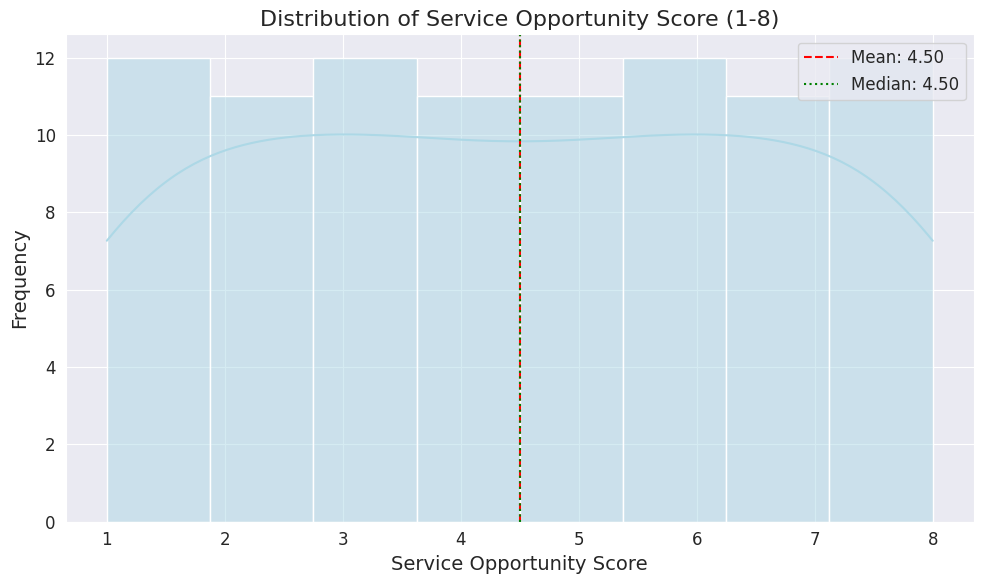

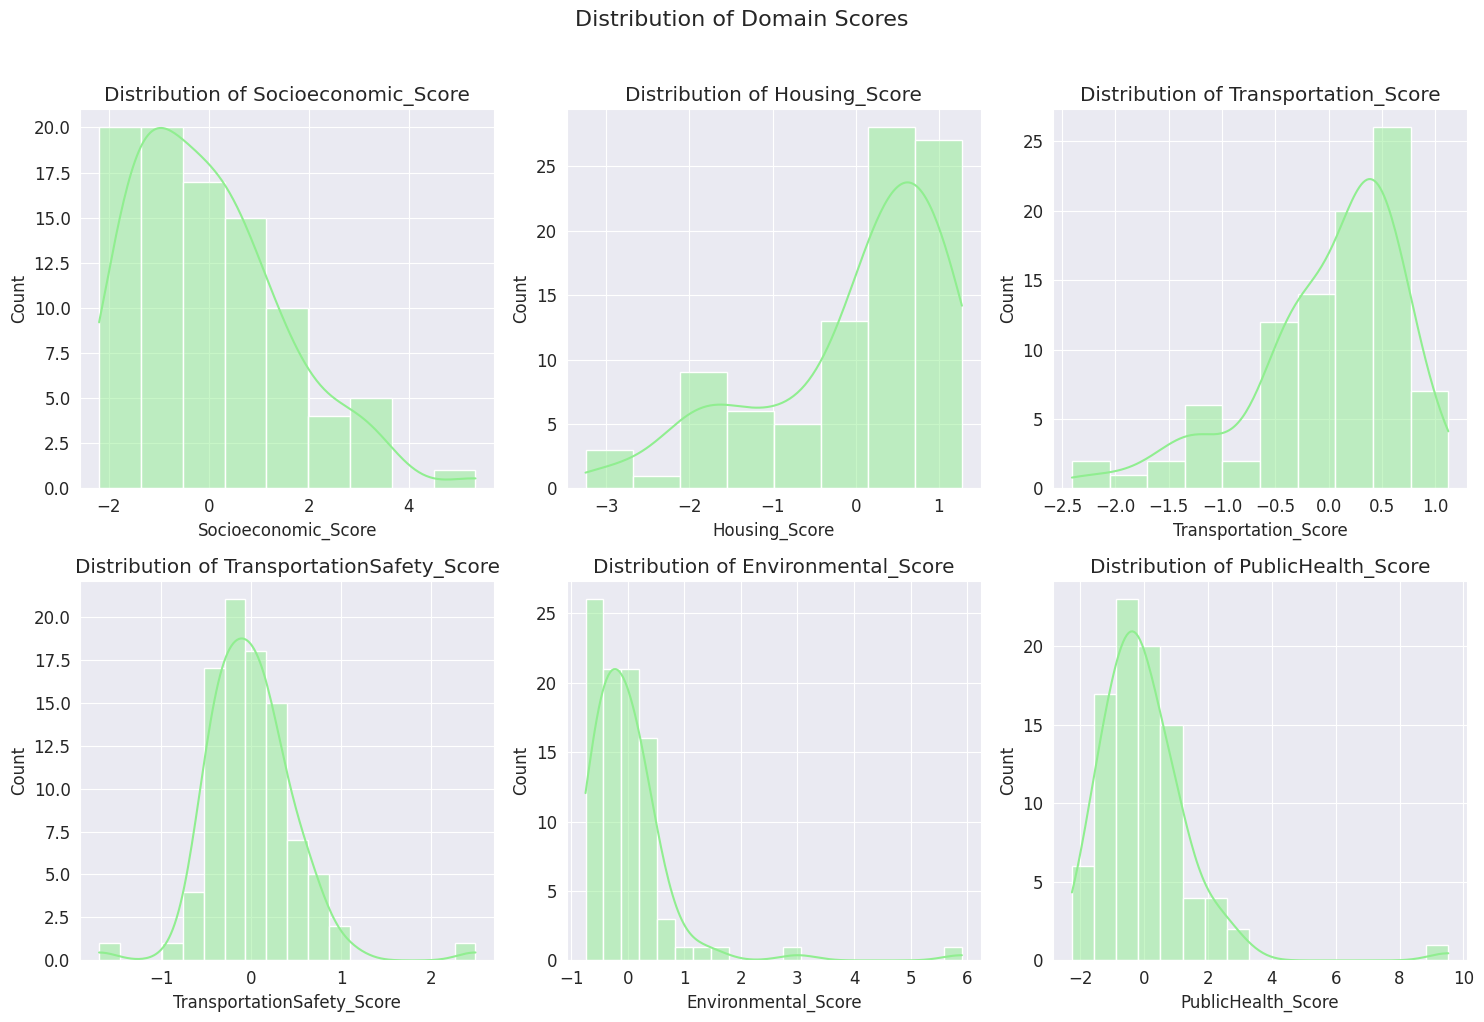



--- PART 2: CORRELATION ANALYSIS ---


Correlation with Service Opportunity Score:
Socioeconomic_Score           0.770787
PublicHealth_Score            0.714458
TransportationSafety_Score    0.349956
Environmental_Score          -0.146424
Transportation_Score         -0.403045
Housing_Score                -0.546135
dtype: float64


/tmp/ipython-input-124-646794897.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Correlation', y='Domain', data=corr_df,


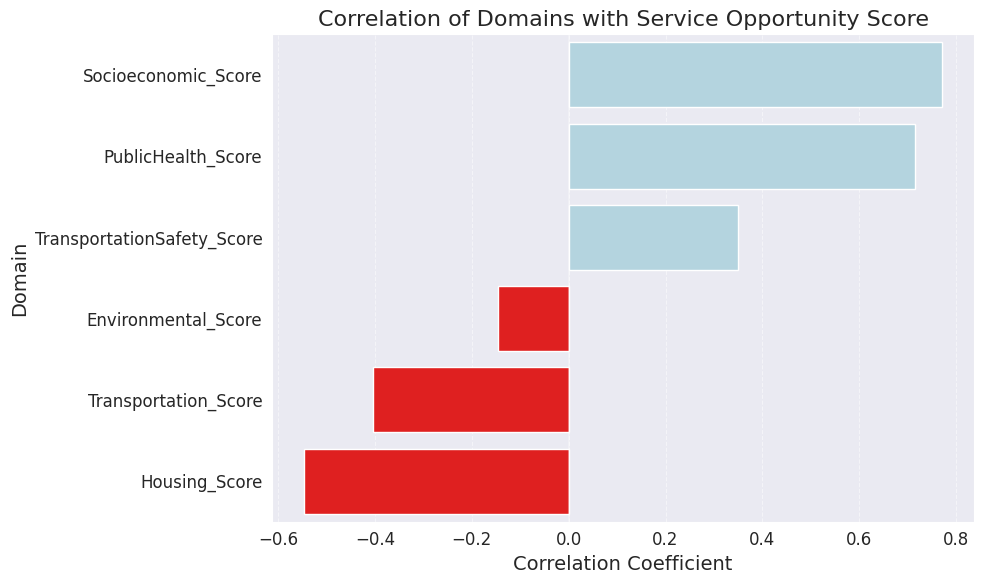

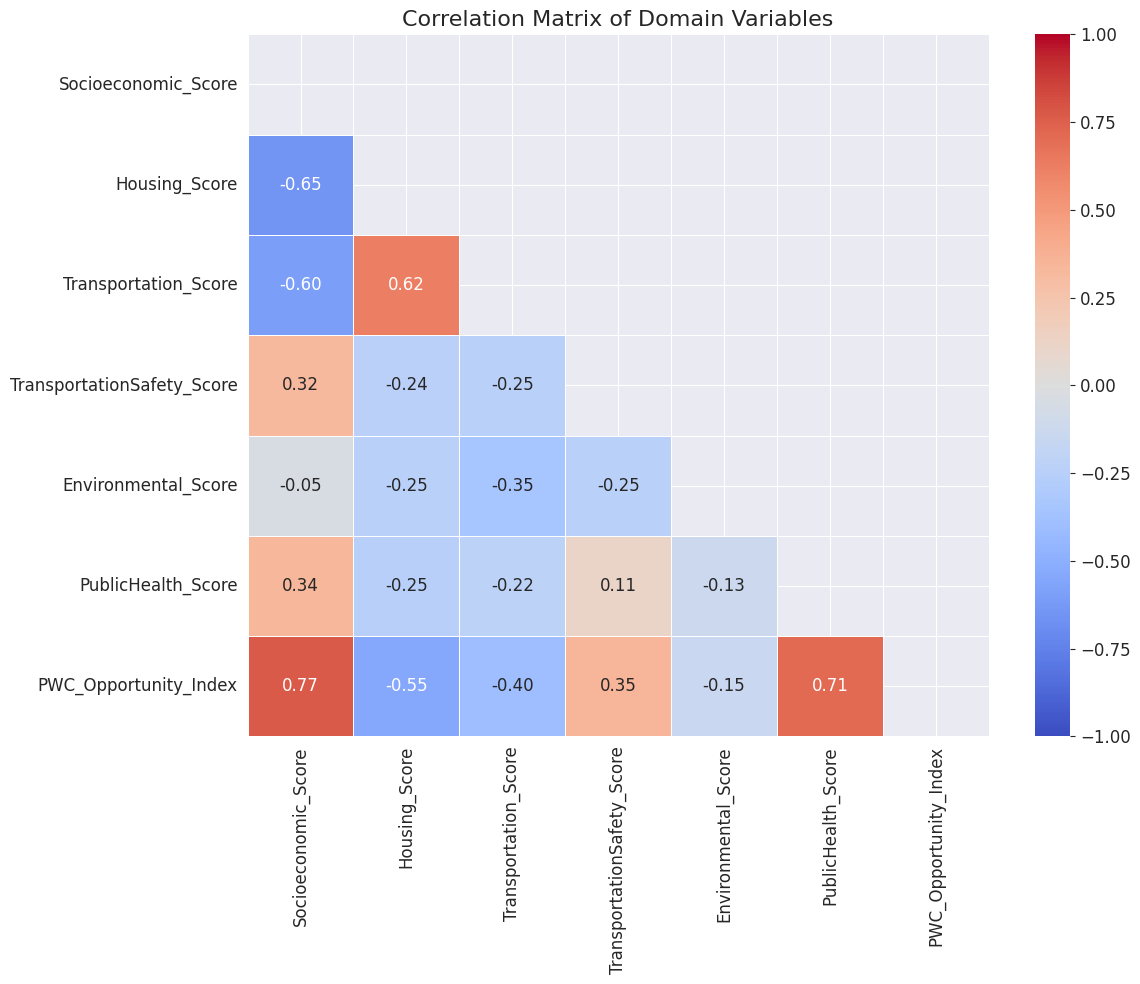



--- PART 3: MULTICOLLINEARITY CHECK ---


Variance Inflation Factors:
                       Domain       VIF
0         Socioeconomic_Score  2.360710
2        Transportation_Score  2.206873
1               Housing_Score  2.180127
4         Environmental_Score  1.555622
3  TransportationSafety_Score  1.259429
5          PublicHealth_Score  1.167421


/tmp/ipython-input-124-646794897.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='VIF', y='Domain', data=vif_data, palette='viridis')


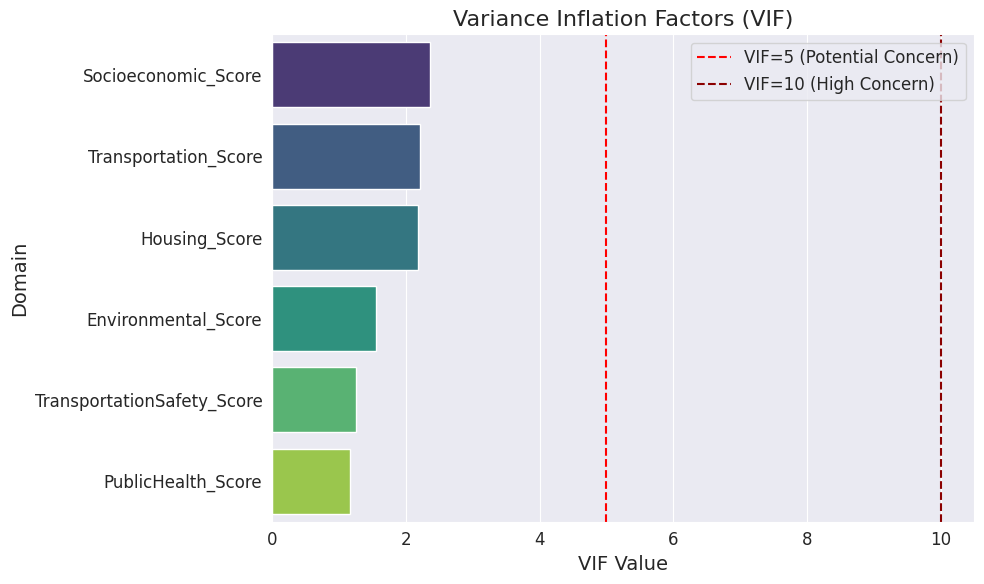



--- PART 4: REGRESSION ANALYSIS ---


Regression Results:
                              OLS Regression Results                             
Dep. Variable:     PWC_Opportunity_Index   R-squared:                       0.850
Model:                               OLS   Adj. R-squared:                  0.839
Method:                    Least Squares   F-statistic:                     80.14
Date:                   Thu, 03 Jul 2025   Prob (F-statistic):           7.23e-33
Time:                           17:24:56   Log-Likelihood:                -120.38
No. Observations:                     92   AIC:                             254.8
Df Residuals:                         85   BIC:                             272.4
Df Model:                              6                                         
Covariance Type:               nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------

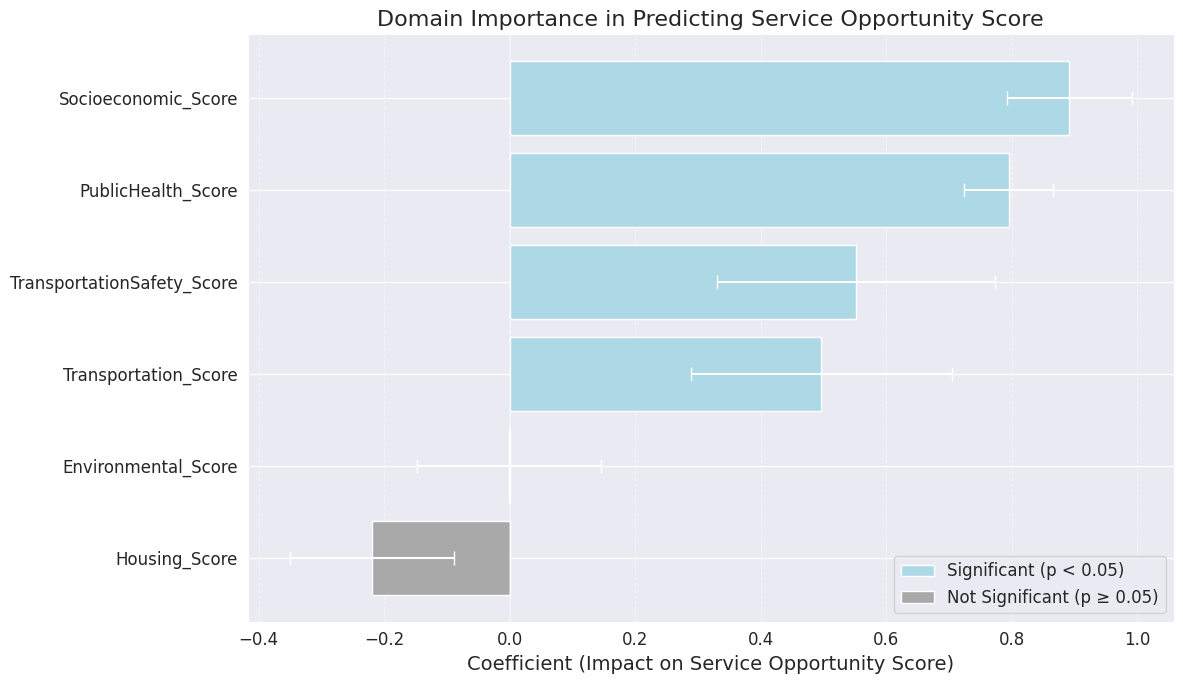



--- PART 5: MODEL EVALUATION ---

Model Performance Metrics:
R² Score: 0.8004
Root Mean Squared Error: 0.9726
Mean Absolute Error: 0.8010


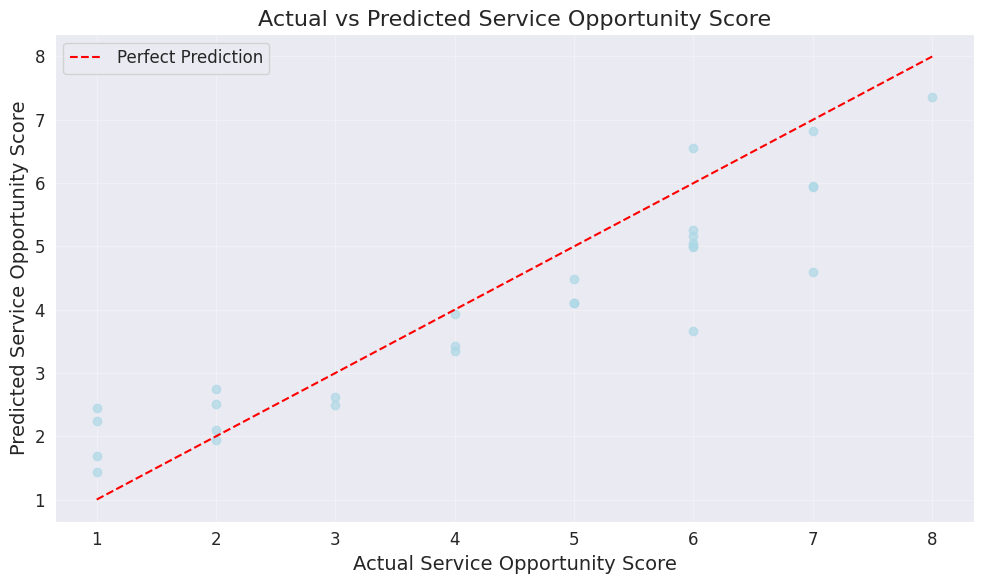

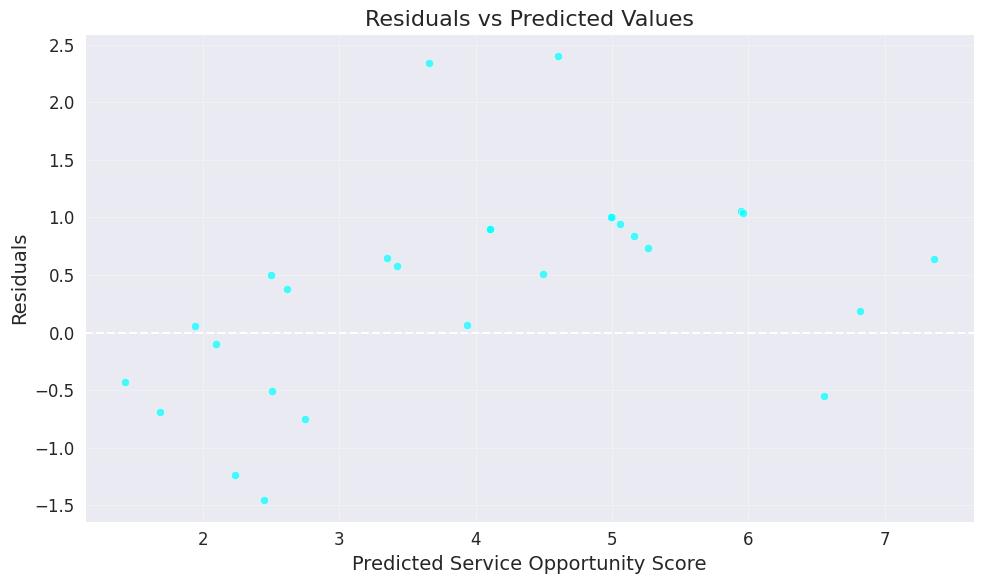



--- PART 6: PRACTICAL INTERPRETATION ---


Standardized Coefficients (for direct comparison):
                        Domain  Standardized_Coefficient       P_Value
x1         Socioeconomic_Score                  1.338755  6.160222e-14
x6          PublicHealth_Score                  1.180157  1.659633e-18
x3        Transportation_Score                  0.344541  1.915207e-02
x4  TransportationSafety_Score                  0.271267  1.476373e-02
x5         Environmental_Score                 -0.000623  9.959112e-01
x2               Housing_Score                 -0.241555  9.575275e-02


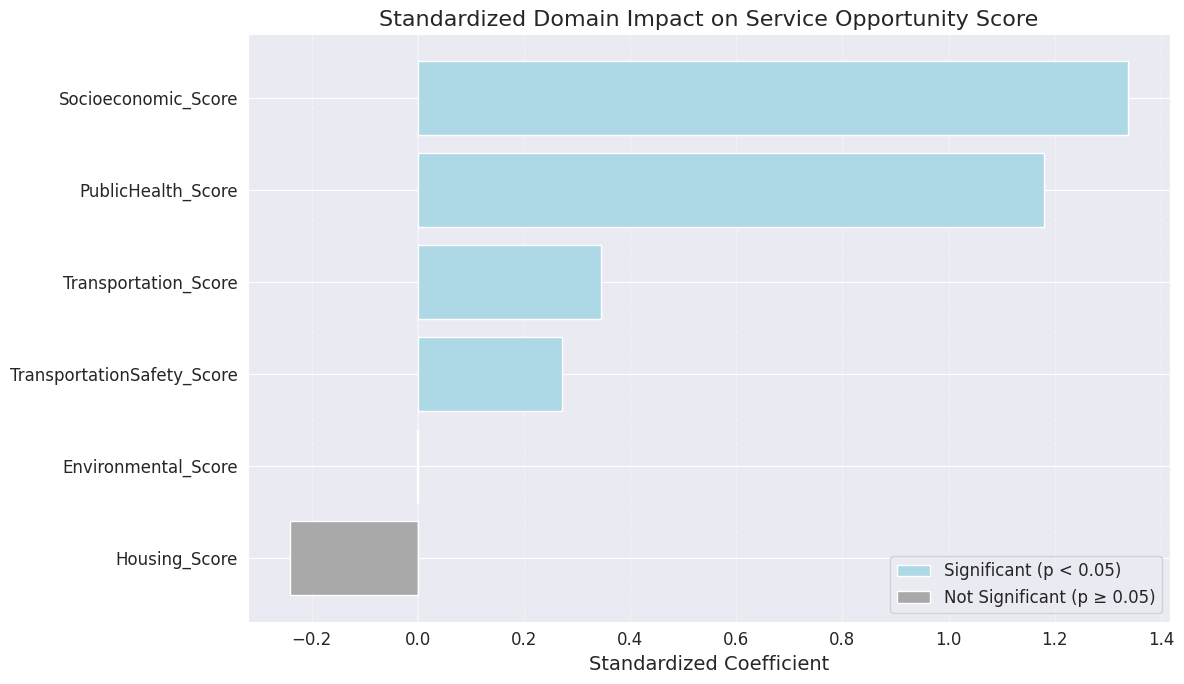


Practical Impact on Service Opportunity Score:
                                                Domain  Coefficient  \
Socioeconomic_Score                Socioeconomic_Score     0.892014   
PublicHealth_Score                  PublicHealth_Score     0.795074   
TransportationSafety_Score  TransportationSafety_Score     0.551587   
Transportation_Score              Transportation_Score     0.496336   
Environmental_Score                Environmental_Score    -0.000755   
Housing_Score                            Housing_Score    -0.220022   

                            Impact_for_1_point_change       P_Value  
Socioeconomic_Score                          0.892014  6.160222e-14  
PublicHealth_Score                           0.795074  1.659633e-18  
TransportationSafety_Score                   0.551587  1.476373e-02  
Transportation_Score                         0.496336  1.915207e-02  
Environmental_Score                         -0.000755  9.959112e-01  
Housing_Score                     

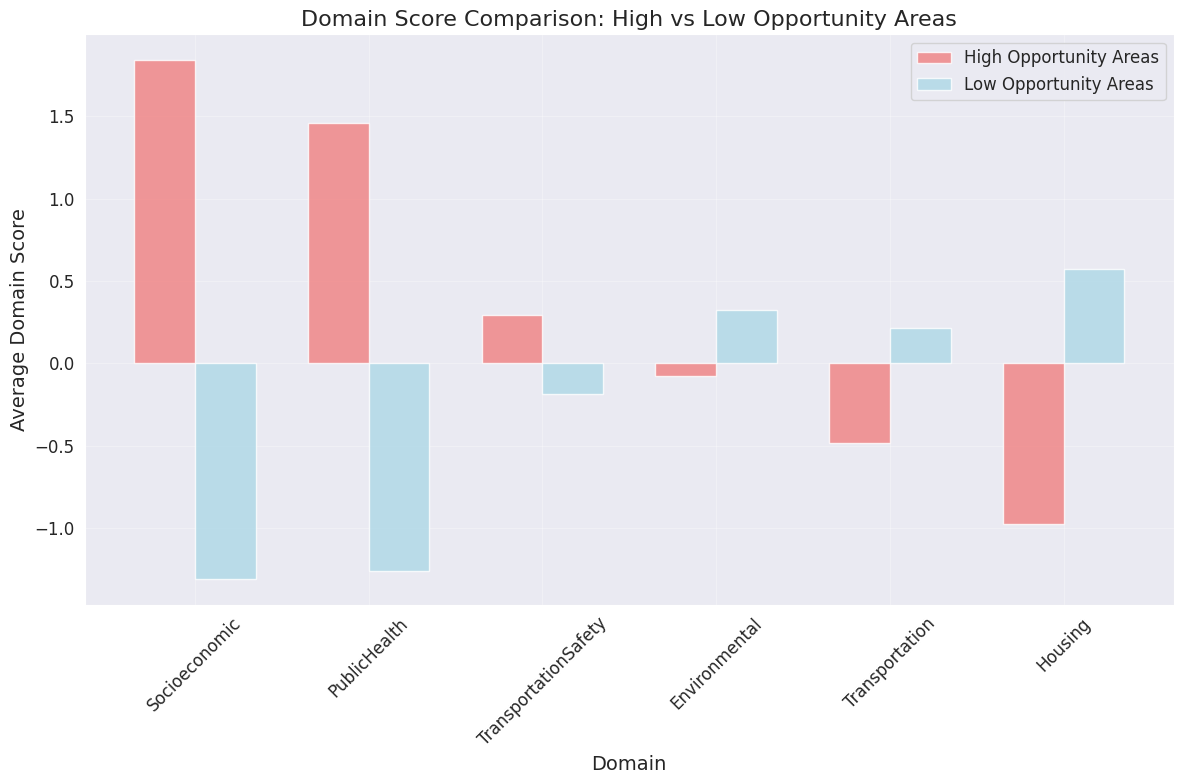


Key Insights for Resource Allocation:
- Domains with larger positive differences are key drivers of opportunity identification
- High opportunity areas show greater need across multiple domains
- Focus service delivery on areas with high opportunity scores
- Monitor domains with strongest coefficients for maximum impact


In [ ]:
# =============================================
# OPPORTUNITY INDEX REGRESSION ANALYSIS
# =============================================

print("\n\n--- OPPORTUNITY INDEX REGRESSION ANALYSIS ---\n")

# Import required libraries
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Set styling for better visualizations
plt.style.use('dark_background')
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# First, let's check all columns in both dataframes
print("Columns in df_final:")
print(df_final.columns.tolist())
print("\nColumns in df_final_copy:")
print(df_final_copy.columns.tolist())

# Define core domain columns
core_domains = [
    'Socioeconomic_Score',
    'Housing_Score',
    'Transportation_Score',  # Updated from Transportation_Score
    'TransportationSafety_Score',
    'Environmental_Score',
    'PublicHealth_Score'
]

# Create a comprehensive dataframe with all needed variables
# Assuming 'ID' is the common key between both dataframes
if 'ID' in df_final.columns and 'ID' in df_final_copy.columns:
    # Create a new dataframe with domains from df_final and target from df_final_copy
    regression_df = df_final[['ID'] + core_domains].merge(
        df_final_copy[['ID', 'PWC_Opportunity_Index']],  # Updated target variable
        on='ID',
        how='inner'
    )

    print(f"\nCreated regression dataframe with {regression_df.shape[0]} rows and {regression_df.shape[1]} columns")
    print("Columns in regression_df:", regression_df.columns.tolist())

    # Save a copy of original data
    regression_df_orig = regression_df.copy()

    # =============================================
    # PART 1: EXPLORATORY DATA ANALYSIS
    # =============================================
    print("\n\n--- PART 1: EXPLORATORY DATA ANALYSIS ---\n")

    # Basic statistics
    print("\nDescriptive Statistics:")
    desc_stats = regression_df[core_domains + ['PWC_Opportunity_Index']].describe()
    print(desc_stats)

    # Check for missing values
    missing_values = regression_df.isnull().sum()
    if missing_values.sum() > 0:
        print("\nMissing Values:")
        print(missing_values[missing_values > 0])
    else:
        print("\nNo missing values found in the dataset.")

    # Distribution of Opportunity Index
    plt.figure(figsize=(10, 6))
    sns.histplot(regression_df['PWC_Opportunity_Index'], kde=True, bins=8, color='lightblue')
    plt.title('Distribution of Service Opportunity Score (1-8)', fontsize=16)
    plt.xlabel('Service Opportunity Score', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.axvline(regression_df['PWC_Opportunity_Index'].mean(), color='red', linestyle='--',
                label=f'Mean: {regression_df["PWC_Opportunity_Index"].mean():.2f}')
    plt.axvline(regression_df['PWC_Opportunity_Index'].median(), color='green', linestyle=':',
                label=f'Median: {regression_df["PWC_Opportunity_Index"].median():.2f}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Domain distributions
    plt.figure(figsize=(15, 10))
    for i, domain in enumerate(core_domains):
        plt.subplot(2, 3, i+1)
        sns.histplot(regression_df[domain], kde=True, color='lightgreen')
        plt.title(f'Distribution of {domain}')
        plt.xlabel(domain)
        plt.tight_layout()
    plt.suptitle('Distribution of Domain Scores', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    # =============================================
    # PART 2: CORRELATION ANALYSIS
    # =============================================
    print("\n\n--- PART 2: CORRELATION ANALYSIS ---\n")

    # Correlation with Opportunity Index
    print("\nCorrelation with Service Opportunity Score:")
    correlations = regression_df[core_domains].corrwith(regression_df['PWC_Opportunity_Index'])
    corr_sorted = correlations.sort_values(ascending=False)
    print(corr_sorted)

    # Visualize correlations with Opportunity Index
    plt.figure(figsize=(10, 6))
    corr_df = pd.DataFrame(corr_sorted).reset_index()
    corr_df.columns = ['Domain', 'Correlation']
    sns.barplot(x='Correlation', y='Domain', data=corr_df,
                palette=['red' if x < 0 else 'lightblue' for x in corr_df['Correlation']])
    plt.title('Correlation of Domains with Service Opportunity Score', fontsize=16)
    plt.xlabel('Correlation Coefficient', fontsize=14)
    plt.ylabel('Domain', fontsize=14)
    plt.axvline(x=0, color='white', linestyle='-', alpha=0.3)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Correlation matrix heatmap
    plt.figure(figsize=(12, 10))
    correlation_matrix = regression_df[core_domains + ['PWC_Opportunity_Index']].corr()
    mask = np.triu(correlation_matrix)
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f',
                mask=mask, vmin=-1, vmax=1, center=0, linewidths=.5)
    plt.title('Correlation Matrix of Domain Variables', fontsize=16)
    plt.tight_layout()
    plt.show()

    # =============================================
    # PART 3: MULTICOLLINEARITY CHECK
    # =============================================
    print("\n\n--- PART 3: MULTICOLLINEARITY CHECK ---\n")

    # Variance Inflation Factor (VIF)
    X = regression_df[core_domains]
    vif_data = pd.DataFrame()
    vif_data["Domain"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif_data = vif_data.sort_values('VIF', ascending=False)
    print("\nVariance Inflation Factors:")
    print(vif_data)

    # Visualize VIF values
    plt.figure(figsize=(10, 6))
    sns.barplot(x='VIF', y='Domain', data=vif_data, palette='viridis')
    plt.title('Variance Inflation Factors (VIF)', fontsize=16)
    plt.xlabel('VIF Value', fontsize=14)
    plt.ylabel('Domain', fontsize=14)
    plt.axvline(x=5, color='red', linestyle='--', label='VIF=5 (Potential Concern)')
    plt.axvline(x=10, color='darkred', linestyle='--', label='VIF=10 (High Concern)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =============================================
    # PART 4: REGRESSION ANALYSIS
    # =============================================
    print("\n\n--- PART 4: REGRESSION ANALYSIS ---\n")

    # Prepare data for regression
    X = sm.add_constant(regression_df[core_domains])
    y = regression_df['PWC_Opportunity_Index']

    # Run regression
    model = sm.OLS(y, X).fit()

    # Print regression results
    print("\nRegression Results:")
    print(model.summary())

    # Feature importance
    importance = pd.DataFrame({
        'Domain': core_domains,
        'Coefficient': model.params[1:],
        'Std_Error': model.bse[1:],
        'P_Value': model.pvalues[1:],
        'Correlation': correlations
    })
    importance = importance.sort_values('Coefficient', ascending=False)

    print("\nFeature Importance:")
    print(importance)

    # Mark significant features
    importance['Significant'] = importance['P_Value'] < 0.05

    # Plot feature importance
    plt.figure(figsize=(12, 7))
    importance_plot = importance.sort_values('Coefficient')
    colors = ['lightblue' if x < 0.05 else 'darkgrey' for x in importance_plot['P_Value']]
    bars = plt.barh(importance_plot['Domain'], importance_plot['Coefficient'], color=colors)

    # Add error bars
    plt.errorbar(
        importance_plot['Coefficient'],
        importance_plot['Domain'],
        xerr=importance_plot['Std_Error'],
        fmt='none',
        color='white',
        capsize=5
    )

    plt.xlabel('Coefficient (Impact on Service Opportunity Score)', fontsize=14)
    plt.title('Domain Importance in Predicting Service Opportunity Score', fontsize=16)
    plt.axvline(x=0, color='white', linestyle='-', alpha=0.3)
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    # Add legend for significance
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='lightblue', label='Significant (p < 0.05)'),
        Patch(facecolor='darkgrey', label='Not Significant (p ≥ 0.05)')
    ]
    plt.legend(handles=legend_elements, loc='lower right')

    plt.tight_layout()
    plt.show()

    # =============================================
    # PART 5: MODEL EVALUATION
    # =============================================
    print("\n\n--- PART 5: MODEL EVALUATION ---\n")

    # Simple train-test split to evaluate model performance
    X_train, X_test, y_train, y_test = train_test_split(
        regression_df[core_domains],
        regression_df['PWC_Opportunity_Index'],
        test_size=0.3,
        random_state=42
    )

    # Add constant for statsmodels
    X_train_const = sm.add_constant(X_train)
    X_test_const = sm.add_constant(X_test)

    # Train model
    eval_model = sm.OLS(y_train, X_train_const).fit()

    # Make predictions
    y_pred = eval_model.predict(X_test_const)

    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"Model Performance Metrics:")
    print(f"R² Score: {r2:.4f}")
    print(f"Root Mean Squared Error: {rmse:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")

    # Plot predicted vs actual
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.7, color='lightblue')

    # Add perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

    plt.xlabel('Actual Service Opportunity Score', fontsize=14)
    plt.ylabel('Predicted Service Opportunity Score', fontsize=14)
    plt.title('Actual vs Predicted Service Opportunity Score', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Residuals plot
    residuals = y_test - y_pred
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.7, color='cyan')
    plt.axhline(y=0, color='white', linestyle='--')
    plt.xlabel('Predicted Service Opportunity Score', fontsize=14)
    plt.ylabel('Residuals', fontsize=14)
    plt.title('Residuals vs Predicted Values', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # =============================================
    # PART 6: PRACTICAL INTERPRETATION
    # =============================================
    print("\n\n--- PART 6: PRACTICAL INTERPRETATION ---\n")

    # Calculate standardized coefficients for better interpretation
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(regression_df[core_domains])
    X_scaled = sm.add_constant(X_scaled)

    # Run regression with standardized variables
    model_std = sm.OLS(y, X_scaled).fit()

    # Get standardized coefficients (skip the constant)
    std_coefs = pd.DataFrame({
        'Domain': core_domains,
        'Standardized_Coefficient': model_std.params[1:],
        'P_Value': model_std.pvalues[1:]
    }).sort_values('Standardized_Coefficient', ascending=False)

    print("\nStandardized Coefficients (for direct comparison):")
    print(std_coefs)

    # Plot standardized coefficients
    plt.figure(figsize=(12, 7))
    std_coefs_plot = std_coefs.sort_values('Standardized_Coefficient')
    colors = ['lightblue' if x < 0.05 else 'darkgrey' for x in std_coefs_plot['P_Value']]
    plt.barh(std_coefs_plot['Domain'], std_coefs_plot['Standardized_Coefficient'], color=colors)
    plt.xlabel('Standardized Coefficient', fontsize=14)
    plt.title('Standardized Domain Impact on Service Opportunity Score', fontsize=16)
    plt.axvline(x=0, color='white', linestyle='-', alpha=0.3)
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    # Add legend for significance
    legend_elements = [
        Patch(facecolor='lightblue', label='Significant (p < 0.05)'),
        Patch(facecolor='darkgrey', label='Not Significant (p ≥ 0.05)')
    ]
    plt.legend(handles=legend_elements, loc='lower right')

    plt.tight_layout()
    plt.show()

    # Calculate impact on Opportunity Index for a 1-point change in domain score
    impact_df = pd.DataFrame({
        'Domain': core_domains,
        'Coefficient': model.params[1:],
        'Impact_for_1_point_change': model.params[1:],
        'P_Value': model.pvalues[1:]
    }).sort_values('Impact_for_1_point_change', ascending=False)

    print("\nPractical Impact on Service Opportunity Score:")
    print(impact_df)

    print("\nInterpretation Guide:")
    print("- The coefficients show how much the Service Opportunity Score changes when a domain score increases by 1 point")
    print("- Positive coefficients mean improvements in that domain increase opportunity identification")
    print("- Negative coefficients mean improvements in that domain decrease opportunity scores (may indicate areas with less need)")
    print("- Larger positive values indicate stronger opportunity identification")
    print("- Only domains with p < 0.05 are statistically significant")
    print("- Service Opportunity Score is on a 1-8 scale (higher = more opportunity for service impact)")

    # =============================================
    # PART 7: OPPORTUNITY TARGETING INSIGHTS
    # =============================================
    print("\n\n--- PART 7: OPPORTUNITY TARGETING INSIGHTS ---\n")

    # Identify high and low opportunity areas
    high_opp_threshold = regression_df['PWC_Opportunity_Index'].quantile(0.75)
    low_opp_threshold = regression_df['PWC_Opportunity_Index'].quantile(0.25)

    high_opp_areas = regression_df[regression_df['PWC_Opportunity_Index'] >= high_opp_threshold]
    low_opp_areas = regression_df[regression_df['PWC_Opportunity_Index'] <= low_opp_threshold]

    print(f"High Opportunity Areas (top 25%, score ≥ {high_opp_threshold:.2f}): {len(high_opp_areas)} census tracts")
    print(f"Low Opportunity Areas (bottom 25%, score ≤ {low_opp_threshold:.2f}): {len(low_opp_areas)} census tracts")

    # Compare domain scores between high and low opportunity areas
    comparison_df = pd.DataFrame({
        'Domain': core_domains,
        'High_Opportunity_Mean': [high_opp_areas[domain].mean() for domain in core_domains],
        'Low_Opportunity_Mean': [low_opp_areas[domain].mean() for domain in core_domains],
    })
    comparison_df['Difference'] = comparison_df['High_Opportunity_Mean'] - comparison_df['Low_Opportunity_Mean']
    comparison_df = comparison_df.sort_values('Difference', ascending=False)

    print("\nDomain Score Comparison (High vs Low Opportunity Areas):")
    print(comparison_df)

    # Visualize the comparison
    plt.figure(figsize=(12, 8))
    x = np.arange(len(core_domains))
    width = 0.35

    plt.bar(x - width/2, comparison_df['High_Opportunity_Mean'], width,
            label='High Opportunity Areas', color='lightcoral', alpha=0.8)
    plt.bar(x + width/2, comparison_df['Low_Opportunity_Mean'], width,
            label='Low Opportunity Areas', color='lightblue', alpha=0.8)

    plt.xlabel('Domain', fontsize=14)
    plt.ylabel('Average Domain Score', fontsize=14)
    plt.title('Domain Score Comparison: High vs Low Opportunity Areas', fontsize=16)
    plt.xticks(x, [domain.replace('_Score', '') for domain in comparison_df['Domain']], rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nKey Insights for Resource Allocation:")
    print("- Domains with larger positive differences are key drivers of opportunity identification")
    print("- High opportunity areas show greater need across multiple domains")
    print("- Focus service delivery on areas with high opportunity scores")
    print("- Monitor domains with strongest coefficients for maximum impact")

else:
    print("Error: Cannot find common 'ID' column in both dataframes")
    print("df_final keys:", df_final.columns.tolist())
    print("df_final_copy keys:", df_final_copy.columns.tolist())



--- OPPORTUNITY INDEX DEMOGRAPHIC ANALYSIS ---

Available demographic variables: 14
['Disability Percentage', 'Under 5 Years Population', 'Over 64 Years Population', 'Single Parent Households', 'Group Quarters Population', 'Total Population', 'Median Age', 'Age Dependency Ratio', 'Old-age Dependency Ratio', 'Child Dependency Ratio', 'White Population Proportion', 'Sex Ratio (males per 100 females)', 'Black Population Proportion', 'Hispanic Population Proportion']

Attempting to merge demographics from main dataset...
Extended dataframe shape after merge with main dataset: (92, 22)

Final available demographic variables: 14
['Disability Percentage', 'Under 5 Years Population', 'Over 64 Years Population', 'Single Parent Households', 'Group Quarters Population', 'Total Population', 'Median Age', 'Age Dependency Ratio', 'Old-age Dependency Ratio', 'Child Dependency Ratio', 'White Population Proportion', 'Sex Ratio (males per 100 females)', 'Black Population Proportion', 'Hispanic Populat

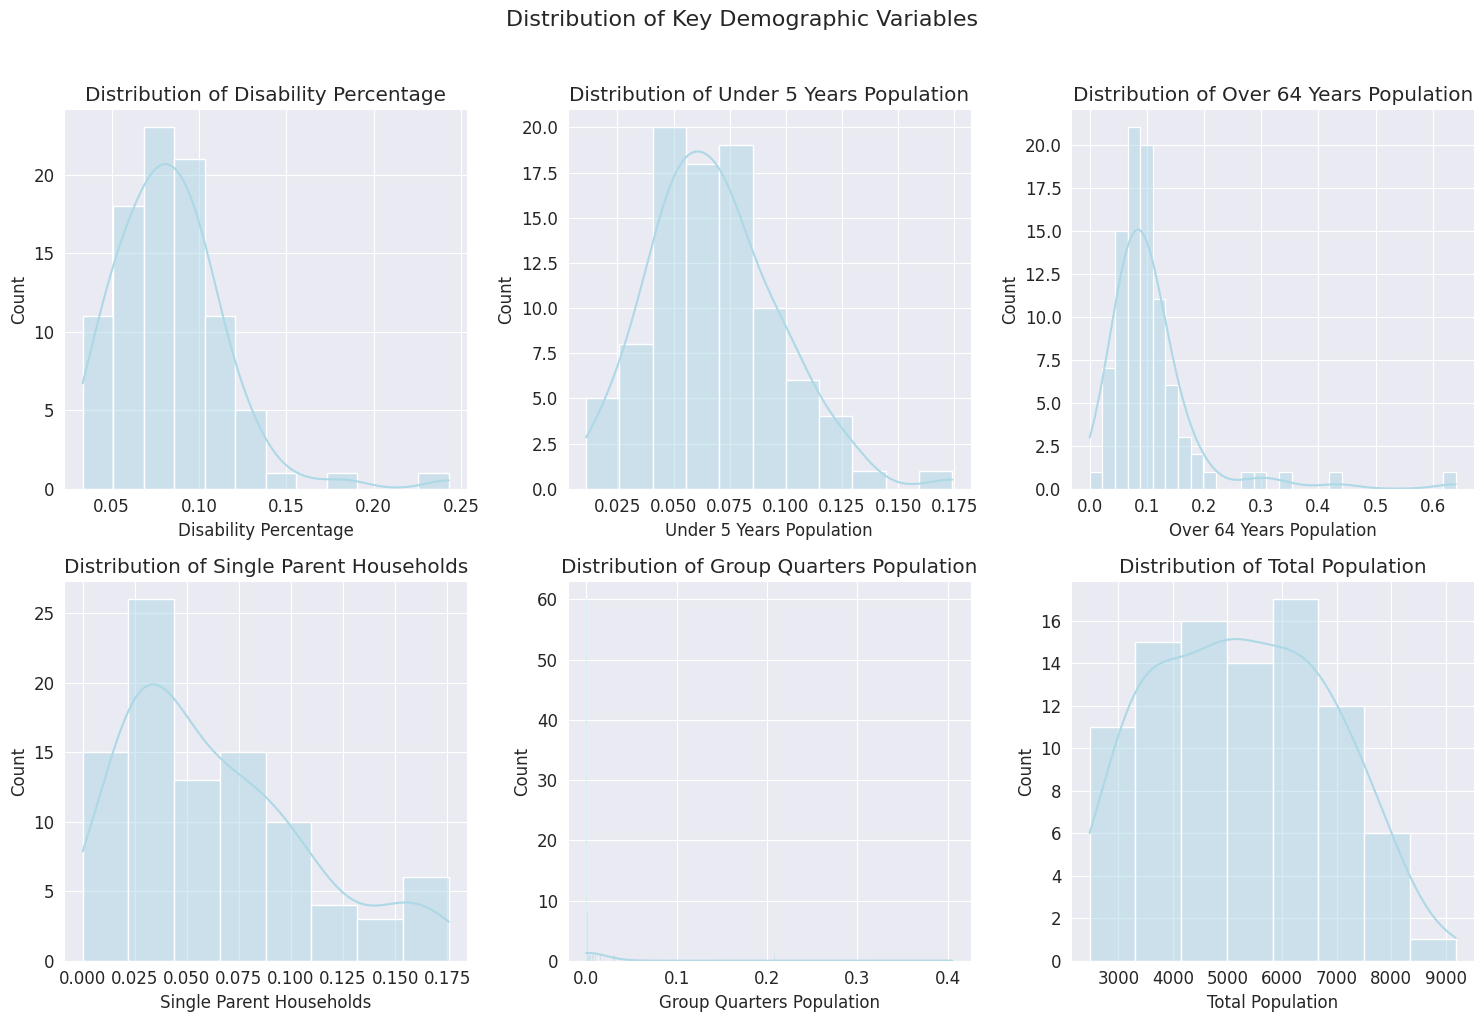



--- PART 2: CORRELATION ANALYSIS OF DEMOGRAPHICS ---


Correlation of Demographics with Service Opportunity Score:
                             Variable  Correlation
0      Hispanic Population Proportion     0.617484
1            Single Parent Households     0.401655
2         Black Population Proportion     0.330588
3               Disability Percentage     0.299610
4                    Total Population     0.225362
5            Under 5 Years Population     0.169816
6            Old-age Dependency Ratio     0.076012
7                Age Dependency Ratio     0.051053
8            Over 64 Years Population     0.045593
9              Child Dependency Ratio    -0.065490
10                         Median Age    -0.138102
11  Sex Ratio (males per 100 females)    -0.175051
12          Group Quarters Population    -0.234536
13        White Population Proportion    -0.657791


/tmp/ipython-input-125-1358483992.py:188: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Correlation', y='Variable', data=demo_corr_df, palette=colors, orient='h')


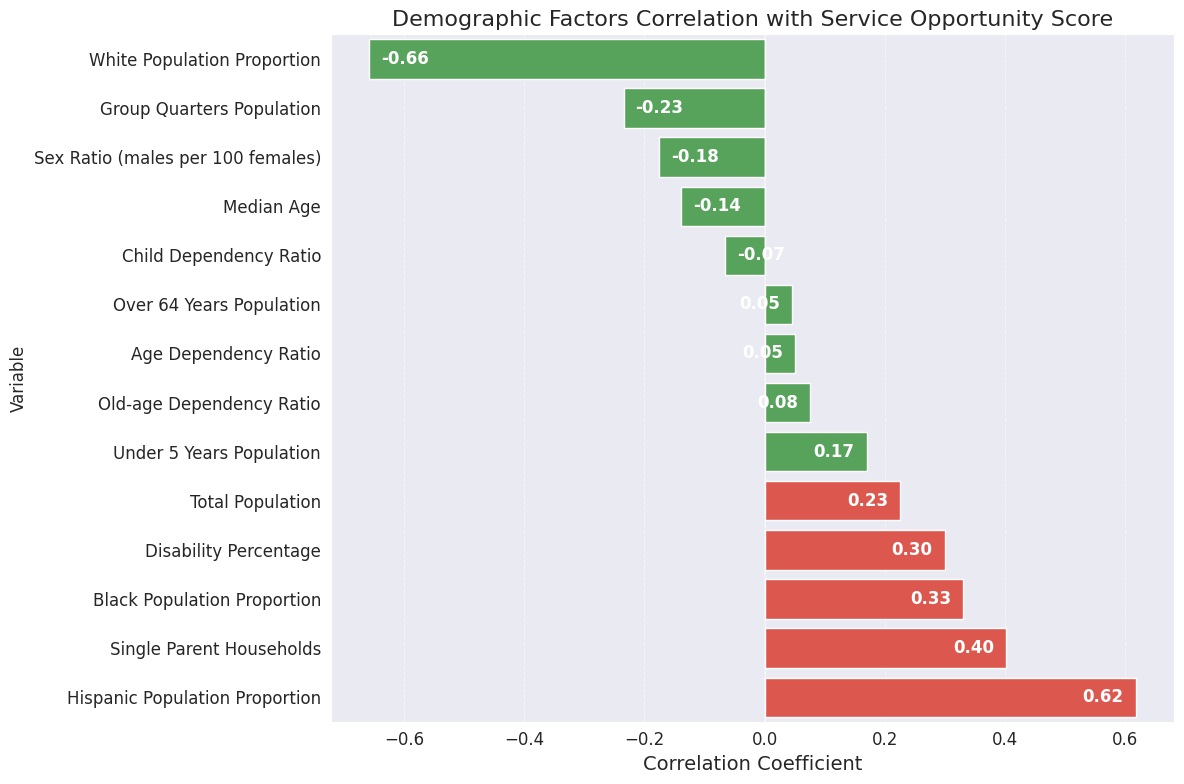


Calculating correlation matrix between domains and demographics...


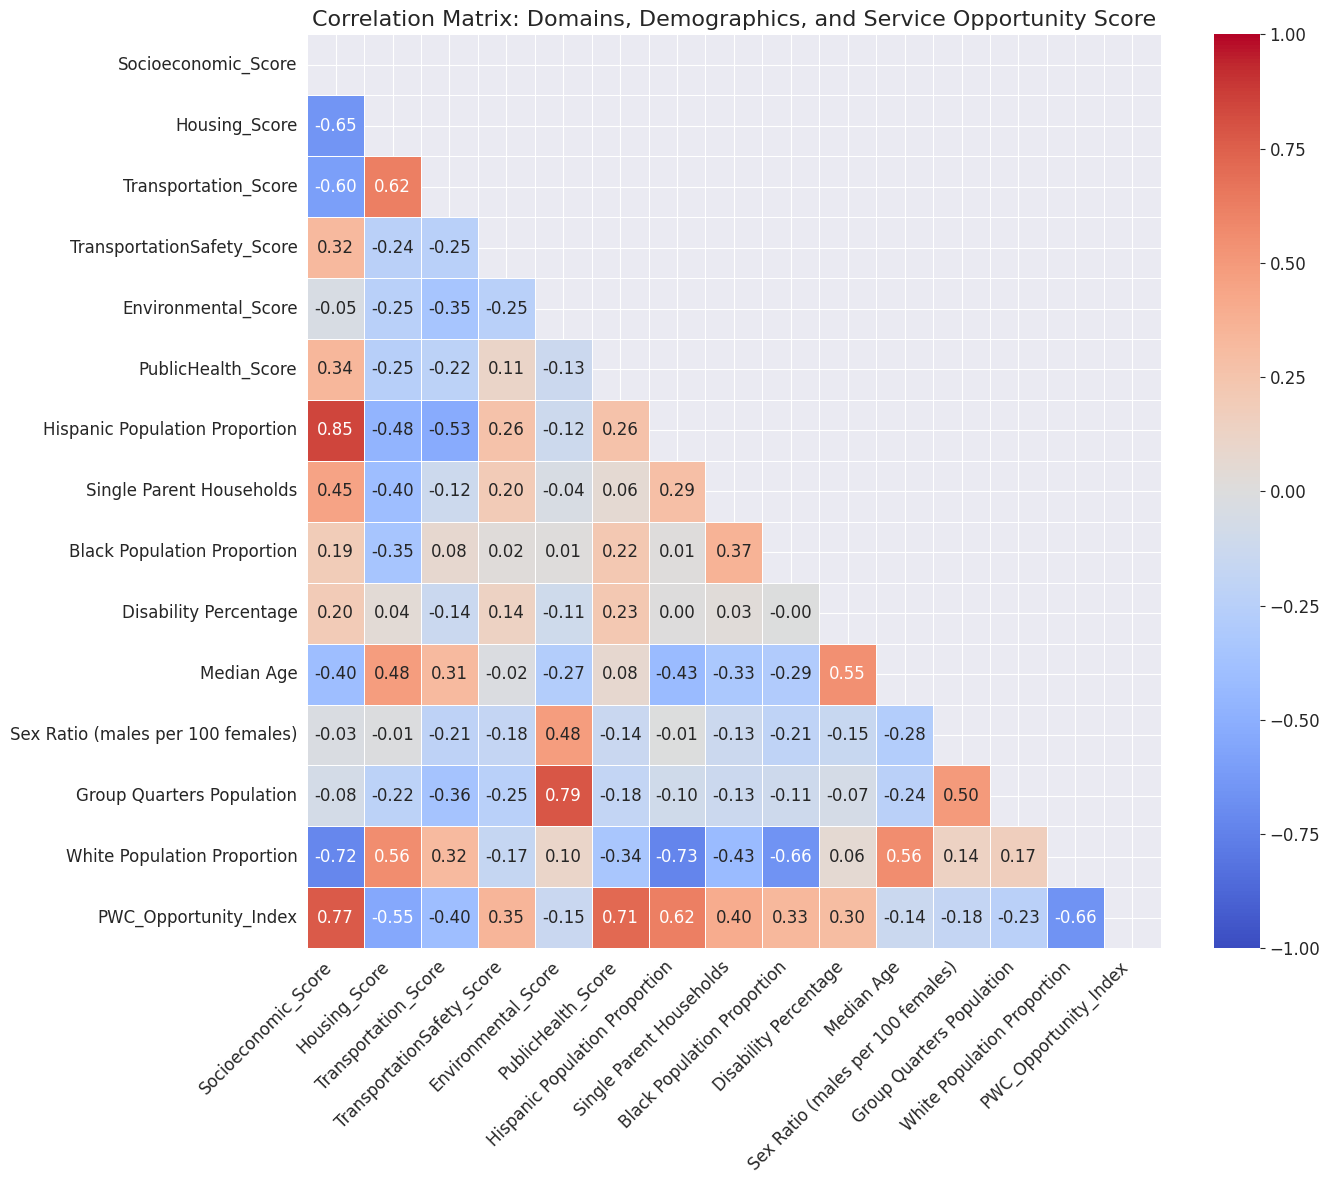



--- PART 3: EXTENDED REGRESSION MODEL WITH DEMOGRAPHICS ---


Variance Inflation Factors (Extended Model):
                            Variable           VIF
13              Age_Dependency_Ratio  2.162716e+06
15            Child_Dependency_Ratio  8.951048e+05
14          Old-age_Dependency_Ratio  4.865049e+05
12                        Median_Age  2.867526e+02
16                        Prop_White  1.203677e+02
17  Sex_Ratio(males per 100 females)  5.693044e+01
8                          OVER64PCT  4.627834e+01
19                         Prop_Hisp  4.475196e+01
18                        Prop_Black  3.254072e+01
6                      DISABILITYPCT  2.384438e+01


/tmp/ipython-input-125-1358483992.py:259: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_vif_vars['Variable_Name'] = [demographic_mapping.get(var, var) for var in high_vif_vars['Variable']]
/tmp/ipython-input-125-1358483992.py:262: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='VIF', y='Variable_Name', data=high_vif_vars, palette=colors)


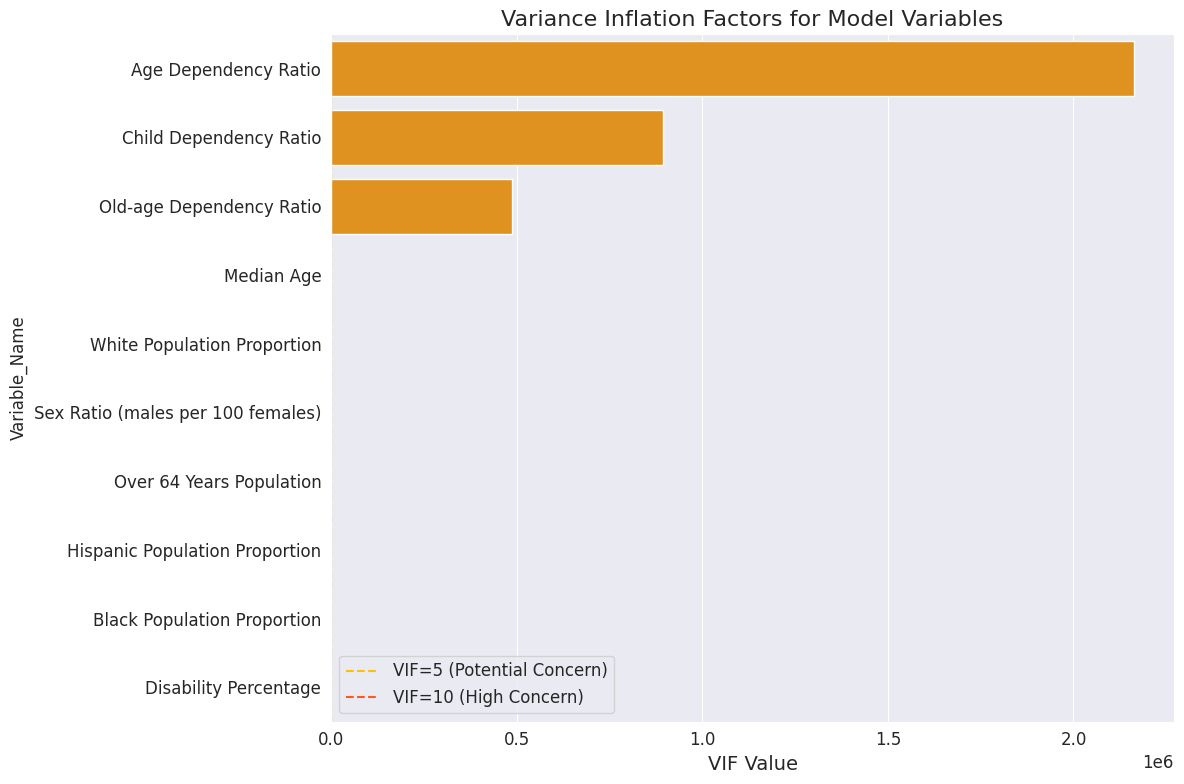


Consider removing these variables for a more stable model.

Limiting to top 8 demographics (from 14) based on correlation strength

Selected demographics for modeling: ['Hispanic Population Proportion', 'Single Parent Households', 'Black Population Proportion', 'Disability Percentage', 'Median Age', 'Sex Ratio (males per 100 females)', 'Group Quarters Population', 'White Population Proportion']

Extended Model with Demographics Results:
                              OLS Regression Results                             
Dep. Variable:     PWC_Opportunity_Index   R-squared:                       0.877
Model:                               OLS   Adj. R-squared:                  0.854
Method:                    Least Squares   F-statistic:                     39.09
Date:                   Thu, 03 Jul 2025   Prob (F-statistic):           3.59e-29
Time:                           18:27:08   Log-Likelihood:                -111.31
No. Observations:                     92   AIC:                   

/tmp/ipython-input-125-1358483992.py:341: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Coefficient', y='Variable', data=demo_results, palette=colors)


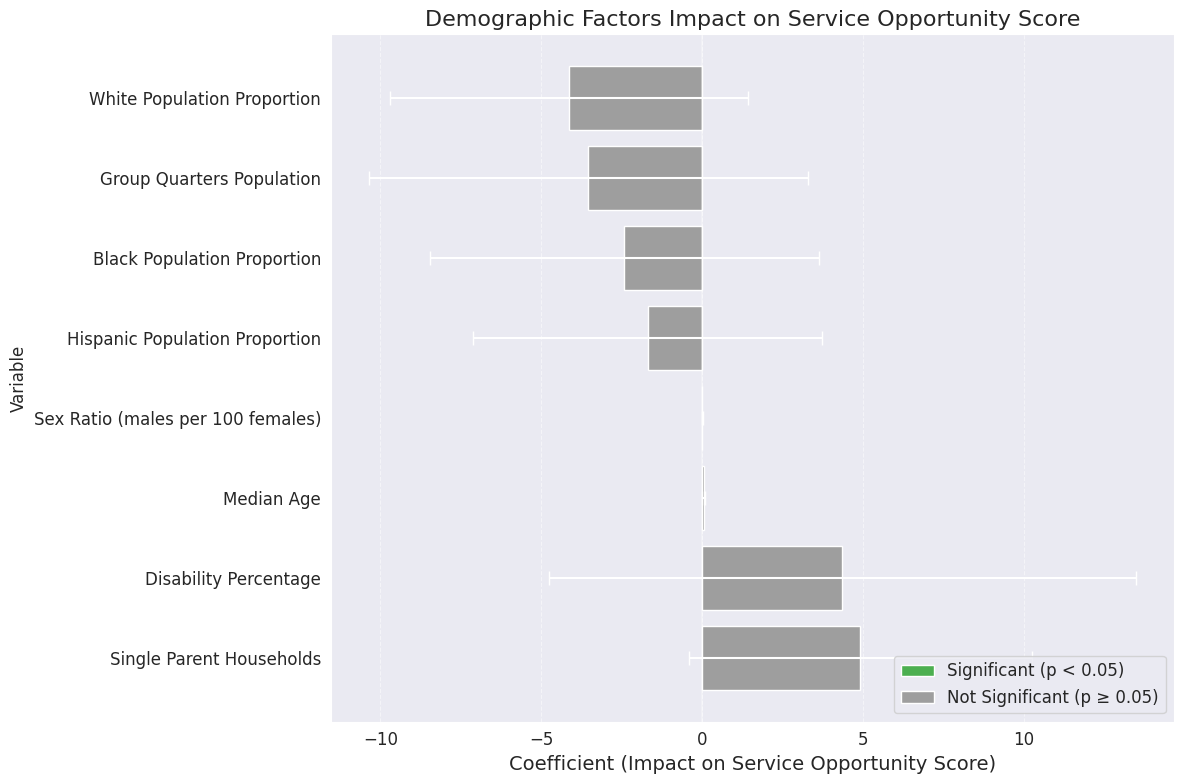


Skipping extended models since no demographic variables are available.


In [ ]:
# =============================================
# OPPORTUNITY INDEX DEMOGRAPHIC ANALYSIS
# =============================================

print("\n\n--- OPPORTUNITY INDEX DEMOGRAPHIC ANALYSIS ---\n")

# Import required libraries
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch

# Set styling for better visualizations
plt.style.use('dark_background')
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Define demographic variables with more descriptive labels for display
demographic_mapping = {
    "DISABILITYPCT": "Disability Percentage",
    "UNDER5PCT": "Under 5 Years Population",
    "OVER64PCT": "Over 64 Years Population",
    "E_SNGPNT_P": "Single Parent Households",
    "E_GROUPQ_P": "Group Quarters Population",
    "Total_Population": "Total Population",
    "Median_Age": "Median Age",
    "Age_Dependency_Ratio": "Age Dependency Ratio",
    "Old-age_Dependency_Ratio": "Old-age Dependency Ratio",
    "Child_Dependency_Ratio": "Child Dependency Ratio",
    "Prop_White": "White Population Proportion",
    "Sex_Ratio(males per 100 females)": "Sex Ratio (males per 100 females)",
    "Prop_Black": "Black Population Proportion",
    "Prop_Hisp": "Hispanic Population Proportion",
    "White_P": "White Population Percentage",
    "Black_P": "Black Population Percentage",
    "Hispanic_P": "Hispanic Population Percentage",
    "Asian_P": "Asian Population Percentage",
    "AmIndian_P": "American Indian Population Percentage",
    "Other_P": "Other Races Population Percentage",
    "MultiRace_P": "Multiple Races Population Percentage",
    "PacIslander_P": "Pacific Islander Population Percentage",
    "Median_Household_Income": "Median Household Income",
    "Per_Capita_Income": "Per Capita Income",
    "Commute_Less30min_P": "Commute Less Than 30 Minutes",
    "Commute_30to60min_P": "Commute 30-60 Minutes",
    "Commute_60plus_P": "Commute Over 60 Minutes"
}

# Define comprehensive list of demographic variables to check
demographic_vars = list(demographic_mapping.keys())

# Check which demographic variables are actually available in our dataset
available_demographics = []
for var in demographic_vars:
    # Check main dataset
    if var in df.columns:
        available_demographics.append(var)
    # Also check df_final and df_final_copy
    elif var in df_final.columns:
        available_demographics.append(var)
    elif var in df_final_copy.columns:
        available_demographics.append(var)

print(f"Available demographic variables: {len(available_demographics)}")
print([demographic_mapping.get(var, var) for var in available_demographics])

# Create a dataset with domains, demographics, and opportunity index
# First, ensure we have our regression dataset with opportunity index
if 'regression_df' not in locals():
    regression_df = df_final[['ID'] + core_domains].merge(
        df_final_copy[['ID', 'PWC_Opportunity_Index']],  # Updated target variable
        on='ID',
        how='inner'
    )

# First try to get demographics from df
if available_demographics:
    if 'ID' in df.columns:
        print("\nAttempting to merge demographics from main dataset...")
        demographics_df = df[['ID'] + [var for var in available_demographics if var in df.columns]]
        extended_df = regression_df.merge(
            demographics_df,
            on='ID',
            how='inner'
        )
        print(f"Extended dataframe shape after merge with main dataset: {extended_df.shape}")
    else:
        print("\nNo ID column found in main dataset. Checking other datasets...")

        # Try df_final
        demographics_from_final = [var for var in available_demographics if var in df_final.columns]
        if demographics_from_final:
            print(f"Found {len(demographics_from_final)} demographics in df_final")
            demographics_df = df_final[['ID'] + demographics_from_final]
            extended_df = regression_df.merge(
                demographics_df,
                on='ID',
                how='inner'
            )
            print(f"Extended dataframe shape after merge with df_final: {extended_df.shape}")

        # Try df_final_copy for additional variables
        demographics_from_final_copy = [var for var in available_demographics if var in df_final_copy.columns and var not in extended_df.columns]
        if demographics_from_final_copy:
            print(f"Found {len(demographics_from_final_copy)} additional demographics in df_final_copy")
            demographics_df = df_final_copy[['ID'] + demographics_from_final_copy]
            extended_df = extended_df.merge(
                demographics_df,
                on='ID',
                how='inner'
            )
            print(f"Extended dataframe shape after merge with df_final_copy: {extended_df.shape}")

    # Update available_demographics to only include columns that actually exist in extended_df
    available_demographics = [var for var in available_demographics if var in extended_df.columns]
    print(f"\nFinal available demographic variables: {len(available_demographics)}")
    print([demographic_mapping.get(var, var) for var in available_demographics])
else:
    print("No demographic variables found. Using base model only.")
    extended_df = regression_df
    available_demographics = []

# ========== 1. EXPLORATORY ANALYSIS OF DEMOGRAPHICS ==========

if available_demographics:
    print("\n\n--- PART 1: EXPLORATORY ANALYSIS OF DEMOGRAPHICS ---\n")

    # Check for missing values in demographics
    missing_values = extended_df[available_demographics].isnull().sum()
    if missing_values.sum() > 0:
        print("\nMissing Values in Demographics:")
        print(missing_values[missing_values > 0])

        # Fill missing values with median for numeric columns
        for col in missing_values[missing_values > 0].index:
            if pd.api.types.is_numeric_dtype(extended_df[col]):
                print(f"Filling missing values in {col} with median")
                extended_df[col] = extended_df[col].fillna(extended_df[col].median())
    else:
        print("\nNo missing values found in demographic variables.")

    # Basic statistics on demographics
    print("\nDescriptive Statistics for Demographics:")
    print(extended_df[available_demographics].describe().T)

    # Distribution of key demographics
    top_demos = min(6, len(available_demographics))
    plt.figure(figsize=(15, 10))
    for i, var in enumerate(available_demographics[:top_demos]):
        plt.subplot(2, 3, i+1)
        sns.histplot(extended_df[var], kde=True, color='lightblue')
        plt.title(f'Distribution of {demographic_mapping.get(var, var)}')
        plt.xlabel(demographic_mapping.get(var, var))
        plt.tight_layout()
    plt.suptitle('Distribution of Key Demographic Variables', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    # ========== 2. CORRELATION ANALYSIS OF DEMOGRAPHICS ==========

    print("\n\n--- PART 2: CORRELATION ANALYSIS OF DEMOGRAPHICS ---\n")

    # Correlation of demographics with opportunity index
    print("\nCorrelation of Demographics with Service Opportunity Score:")
    demo_corr = extended_df[available_demographics].corrwith(extended_df['PWC_Opportunity_Index'])  # Updated target variable
    demo_corr_sorted = demo_corr.sort_values(ascending=False)

    # Create a dataframe with readable names for plotting
    demo_corr_df = pd.DataFrame({
        'Variable': [demographic_mapping.get(var, var) for var in demo_corr_sorted.index],
        'Correlation': demo_corr_sorted.values
    })

    print(demo_corr_df)

    # Plot correlations with Opportunity Index
    plt.figure(figsize=(12, 8))
    colors = ['#4CAF50' if x > 0 else '#F44336' for x in demo_corr_df['Correlation']]

    # Sort for better visualization - strongest correlations at top
    demo_corr_df = demo_corr_df.sort_values('Correlation')

    ax = sns.barplot(x='Correlation', y='Variable', data=demo_corr_df, palette=colors, orient='h')

    plt.axvline(x=0, color='white', linestyle='-', alpha=0.3)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.title('Demographic Factors Correlation with Service Opportunity Score', fontsize=16)  # Updated title
    plt.xlabel('Correlation Coefficient', fontsize=14)

    # Add correlation values as text
    for i, v in enumerate(demo_corr_df['Correlation']):
        ax.text(v + (0.02 if v < 0 else -0.02),
                i,
                f"{v:.2f}",
                color='white',
                va='center',
                ha='left' if v < 0 else 'right',
                fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Correlation matrix among demographics and domain variables
    print("\nCalculating correlation matrix between domains and demographics...")

    # Select top demographics based on correlation with opportunity
    top_n = min(8, len(available_demographics))
    top_demo_vars = demo_corr_sorted.index[:top_n//2].tolist() + demo_corr_sorted.index[-top_n//2:].tolist()

    # Create correlation matrix
    correlation_matrix = extended_df[core_domains + top_demo_vars + ['PWC_Opportunity_Index']].corr()  # Updated target variable

    # Rename columns and index for better readability
    readable_cols = [demographic_mapping.get(col, col) for col in correlation_matrix.columns]
    correlation_matrix.columns = readable_cols
    correlation_matrix.index = readable_cols

    # Plot correlation matrix
    plt.figure(figsize=(14, 12))
    mask = np.triu(correlation_matrix)
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f',
                mask=mask, vmin=-1, vmax=1, center=0, linewidths=.5)
    plt.title('Correlation Matrix: Domains, Demographics, and Service Opportunity Score', fontsize=16)  # Updated title
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # ========== 3. EXTENDED REGRESSION MODEL WITH DEMOGRAPHICS ==========

    print("\n\n--- PART 3: EXTENDED REGRESSION MODEL WITH DEMOGRAPHICS ---\n")

    # Check for multicollinearity in extended model
    X_extended = extended_df[core_domains + available_demographics]

    # Calculate VIF only for numeric columns
    numeric_cols = X_extended.select_dtypes(include=[np.number]).columns.tolist()

    if len(numeric_cols) > 0:
        vif_data = pd.DataFrame()
        vif_data["Variable"] = numeric_cols
        vif_data["VIF"] = [variance_inflation_factor(X_extended[numeric_cols].values, i)
                         for i in range(len(numeric_cols))]

        vif_data = vif_data.sort_values('VIF', ascending=False)

        print("\nVariance Inflation Factors (Extended Model):")
        print(vif_data.head(10))  # Show top 10 highest VIF

        # Visualize VIF values
        plt.figure(figsize=(12, 8))
        high_vif_vars = vif_data.head(10)

        # Use readable names for variables
        high_vif_vars['Variable_Name'] = [demographic_mapping.get(var, var) for var in high_vif_vars['Variable']]

        colors = ['#FF9800' if x > 10 else '#4CAF50' if x < 5 else '#FFC107' for x in high_vif_vars['VIF']]
        sns.barplot(x='VIF', y='Variable_Name', data=high_vif_vars, palette=colors)

        plt.axvline(x=5, color='#FFC107', linestyle='--', label='VIF=5 (Potential Concern)')
        plt.axvline(x=10, color='#FF5722', linestyle='--', label='VIF=10 (High Concern)')
        plt.title('Variance Inflation Factors for Model Variables', fontsize=16)
        plt.xlabel('VIF Value', fontsize=14)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Flag high multicollinearity variables
        high_vif_vars = vif_data[vif_data['VIF'] > 10]['Variable'].tolist()
        if high_vif_vars:
            print(f"\nWarning: High multicollinearity detected in variables: {high_vif_vars}")
            print("Consider removing these variables for a more stable model.")

    # Select most significant demographics (top correlations)
    # This prevents overfitting with too many predictors
    if len(available_demographics) > 8:
        print(f"\nLimiting to top 8 demographics (from {len(available_demographics)}) based on correlation strength")
        top_pos_corr = demo_corr_sorted.head(4).index.tolist()
        top_neg_corr = demo_corr_sorted.tail(4).index.tolist()
        selected_demographics = top_pos_corr + top_neg_corr
    else:
        selected_demographics = available_demographics

    print(f"\nSelected demographics for modeling: {[demographic_mapping.get(var, var) for var in selected_demographics]}")

    # Run baseline model for comparison
    X_base = sm.add_constant(extended_df[core_domains])
    y = extended_df['PWC_Opportunity_Index']  # Updated target variable
    base_model = sm.OLS(y, X_base).fit()

    # Run extended model with selected demographics
    X_extended = sm.add_constant(extended_df[core_domains + selected_demographics])
    extended_model = sm.OLS(y, X_extended).fit()

    # Print extended model results
    print("\nExtended Model with Demographics Results:")
    print(extended_model.summary())

    # Compare models
    print("\nModel Comparison:")
    print(f"Base Model R-squared: {base_model.rsquared:.4f}")
    print(f"Extended Model R-squared: {extended_model.rsquared:.4f}")
    print(f"Improvement: {extended_model.rsquared - base_model.rsquared:.4f}")
    print(f"Adjusted R-squared (Base): {base_model.rsquared_adj:.4f}")
    print(f"Adjusted R-squared (Extended): {extended_model.rsquared_adj:.4f}")

    # Identify significant demographic variables
    print("\nSignificant Demographic Variables (p < 0.05):")
    demo_params = extended_model.params.loc[selected_demographics]
    demo_pvalues = extended_model.pvalues.loc[selected_demographics]
    demo_conf_int = extended_model.conf_int().loc[selected_demographics]

    significant_demos = []
    for var, coef, p_val, (ci_low, ci_high) in zip(selected_demographics, demo_params, demo_pvalues, demo_conf_int.values):
        if p_val < 0.05:
            significant_demos.append(var)
            readable_name = demographic_mapping.get(var, var)
            print(f"{readable_name}: coefficient = {coef:.4f}, p-value = {p_val:.4f}, 95% CI = [{ci_low:.4f}, {ci_high:.4f}]")

    # Plot demographic coefficients
    plt.figure(figsize=(12, 8))
    demo_results = pd.DataFrame({
        'Variable': [demographic_mapping.get(var, var) for var in selected_demographics],
        'Coefficient': demo_params.values,
        'P_Value': demo_pvalues.values,
        'CI_Low': demo_conf_int.iloc[:, 0].values,
        'CI_High': demo_conf_int.iloc[:, 1].values
    })

    # Sort by coefficient size
    demo_results = demo_results.sort_values('Coefficient')

    # Assign colors based on significance
    colors = ['#4CAF50' if p < 0.05 else '#9E9E9E' for p in demo_results['P_Value']]

    # Plot coefficients
    ax = sns.barplot(x='Coefficient', y='Variable', data=demo_results, palette=colors)

    # Add error bars
    for i, row in enumerate(demo_results.itertuples()):
        plt.errorbar(x=row.Coefficient, y=i, xerr=[[row.Coefficient-row.CI_Low], [row.CI_High-row.Coefficient]],
                    fmt='none', ecolor='white', elinewidth=1.5, capsize=5)

    plt.axvline(x=0, color='white', linestyle='-', alpha=0.3)
    plt.title('Demographic Factors Impact on Service Opportunity Score', fontsize=16)  # Updated title
    plt.xlabel('Coefficient (Impact on Service Opportunity Score)', fontsize=14)  # Updated label

    # Add legend for significance
    legend_elements = [
        Patch(facecolor='#4CAF50', label='Significant (p < 0.05)'),
        Patch(facecolor='#9E9E9E', label='Not Significant (p ≥ 0.05)')
    ]
    plt.legend(handles=legend_elements, loc='lower right')

    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # ========== 4. DOMAIN-DEMOGRAPHIC INTERACTIONS ==========

    if significant_demos:
        print("\n\n--- PART 4: DOMAIN-DEMOGRAPHIC INTERACTIONS ---\n")

        # Select top domains and demographics for interactions
        top_domains = core_domains[:3]  # Use top 3 domains based on coefficients
        top_demographics = significant_demos[:3] if len(significant_demos) > 3 else significant_demos

        print(f"Testing interactions between {len(top_domains)} domains and {len(top_demographics)} demographics")
        print(f"Domains: {top_domains}")
        print(f"Demographics: {[demographic_mapping.get(d, d) for d in top_demographics]}")

        # Create interaction terms
        for domain in top_domains:
            for demo in top_demographics:
                interaction_name = f"{domain}:{demo}"
                extended_df[interaction_name] = extended_df[domain] * extended_df[demo]

        # Define interaction vars
        interaction_vars = [f"{domain}:{demo}" for domain in top_domains for demo in top_demographics]

        # Run interaction model
        X_interaction = sm.add_constant(extended_df[core_domains + selected_demographics + interaction_vars])
        interaction_model = sm.OLS(y, X_interaction).fit()

        # Print model results
        print("\nInteraction Model Results:")
        print(interaction_model.summary())

        # Compare models
        print("\nModel Comparison:")
        print(f"Base Model R-squared: {base_model.rsquared:.4f}")
        print(f"Extended Model R-squared: {extended_model.rsquared:.4f}")
        print(f"Interaction Model R-squared: {interaction_model.rsquared:.4f}")
        print(f"Adjusted R-squared (Interaction): {interaction_model.rsquared_adj:.4f}")

        # Identify significant interactions
        print("\nSignificant Interactions (p < 0.05):")
        interaction_params = interaction_model.params.loc[interaction_vars]
        interaction_pvalues = interaction_model.pvalues.loc[interaction_vars]
        interaction_conf_int = interaction_model.conf_int().loc[interaction_vars]

        significant_interactions = []
        for var, coef, p_val, (ci_low, ci_high) in zip(interaction_vars,
                                               interaction_params,
                                               interaction_pvalues,
                                               interaction_conf_int.values):
            if p_val < 0.05:
                significant_interactions.append(var)
                domain, demo = var.split(':')
                readable_demo = demographic_mapping.get(demo, demo)
                print(f"{domain} × {readable_demo}: coefficient = {coef:.4f}, p-value = {p_val:.4f}, 95% CI = [{ci_low:.4f}, {ci_high:.4f}]")

        # Visualize significant interactions
        if significant_interactions:
            print("\nVisualizing significant interactions:")
            for interaction in significant_interactions[:3]:  # Visualize top 3
                domain, demo = interaction.split(':')
                readable_demo = demographic_mapping.get(demo, demo)

                # Create quartile groups for visualization
                extended_df['demo_group'] = pd.qcut(extended_df[demo], 4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

                # Create custom color palette
                interaction_palette = sns.color_palette("viridis", 4)

                # Plot
                plt.figure(figsize=(12, 8))
                ax = sns.scatterplot(data=extended_df, x=domain, y='PWC_Opportunity_Index',  # Updated target variable
                                   hue='demo_group', palette=interaction_palette, alpha=0.7, s=100)

                # Add regression lines for each group
                for i, group in enumerate(['Low', 'High']):  # Just show extremes for clarity
                    subset = extended_df[extended_df['demo_group'] == group]
                    if len(subset) > 1:  # Need at least 2 points for regression
                        sns.regplot(x=domain, y='PWC_Opportunity_Index', data=subset,  # Updated target variable
                                  scatter=False, ci=None, color=interaction_palette[i*3],
                                  line_kws={'linestyle': '-' if group=='Low' else '--', 'linewidth': 2.5})

                plt.title(f"Interaction between {domain} and {readable_demo}", fontsize=16)
                plt.xlabel(f"{domain}", fontsize=14)
                plt.ylabel("Service Opportunity Score (1-8)", fontsize=14)  # Updated label
                plt.legend(title=f"{readable_demo} Level")
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()

                # Create a more intuitive visualization of the interaction
                plt.figure(figsize=(12, 8))

                # Plot average opportunity index for each combination of domain and demographic quartiles
                pivot_data = extended_df.pivot_table(
                    values='PWC_Opportunity_Index',  # Updated target variable
                    index=pd.qcut(extended_df[domain], 4, labels=['Low', 'Medium-Low', 'Medium-High', 'High']),
                    columns=pd.qcut(extended_df[demo], 4, labels=['Low', 'Medium-Low', 'Medium-High', 'High']),
                    aggfunc='mean'
                )

                # Plot heatmap
                sns.heatmap(pivot_data, annot=True, cmap='viridis', fmt='.1f', linewidths=0.5)
                plt.title(f"Interaction Effect: {domain} × {readable_demo}", fontsize=16)
                plt.xlabel(f"{readable_demo} Level", fontsize=14)
                plt.ylabel(f"{domain} Level", fontsize=14)
                plt.tight_layout()
                plt.show()

        # ========== 5. PRACTICAL INTERPRETATION ==========

        print("\n\n--- PART 5: PRACTICAL INTERPRETATION ---\n")

        print("Key Findings:")
        print(f"1. Demographics explain an additional {(extended_model.rsquared - base_model.rsquared)*100:.1f}% of variance in Service Opportunity Score")

        if significant_demos:
            print(f"2. Most impactful demographic factors for opportunity identification:")
            for var in significant_demos[:3]:
                coef = extended_model.params.loc[var]
                readable_var = demographic_mapping.get(var, var)
                direction = "increases" if coef > 0 else "decreases"
                print(f"   - {readable_var}: {abs(coef):.3f} points {direction} in opportunity score per unit change")

        if significant_interactions:
            print(f"3. Significant interactions suggest that:")
            for interaction in significant_interactions[:2]:
                domain, demo = interaction.split(':')
                coef = interaction_model.params.loc[interaction]
                readable_demo = demographic_mapping.get(demo, demo)

                if coef > 0:
                    print(f"   - The opportunity-identifying effect of {domain} is enhanced in areas with higher {readable_demo}")
                else:
                    print(f"   - The opportunity-identifying effect of {domain} is reduced in areas with higher {readable_demo}")

        print("\nRecommendations for Service Planning and Investment:")
        print("1. Prioritize services in areas where demographic vulnerabilities amplify domain-based opportunity scores")
        print("2. Design targeted interventions that address both demographic characteristics and domain-specific needs")
        print("3. Use demographic composition to customize service delivery approaches for maximum impact")
        print("4. Focus resources where the combination of demographic and domain factors creates the highest opportunity scores")
        print("5. Service Opportunity Score is on a 1-8 scale (higher = more opportunity for service impact)")

    else:
        print("\nSkipping extended models since no demographic variables are available.")